# Soccer Player Archetype Discovery via β-VAE

**Final Project — Consolidated Notebook**

This notebook combines the multi-file pipeline into a single executable notebook.

## Setup before running
Place your raw CSVs in `./data/`:
- `data/raw_2022.csv` — Vivovinco 2022-23 (semicolon-separated)
- `data/raw_2023.csv` — Cleaned 2023-24 (verbose lowercase headers)
- `data/raw_2024.csv` — Hubert 2024-25 (267 columns including GK stats)

Outputs land in `./outputs/`. Run cells top to bottom.

## Pipeline overview
1. Imports and configuration
2. Position definitions, feature sets, canonical players
3. Data utilities — within-season z-scoring
4. β-VAE model (PyTorch)
5. Training loop
6. Clustering — GMM with BIC + silhouette
7. Visualization helpers
8. Inference utilities
9. Preprocessing pipeline
10. **Run preprocessing**
11. Training orchestrator
12. **Run training** (~5-15 minutes on CPU)
13. Anomaly analysis
14. **Run anomaly analysis**
15. Interpretable-axis quadrant plots
16. **Run quadrant plots**


## 1. Imports and configuration

In [1]:
import os, json, pickle, warnings
from pathlib import Path
from dataclasses import dataclass, field, asdict
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

DATA_DIR = Path('data')
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
print('Setup complete. Torch:', torch.__version__)


Setup complete. Torch: 2.12.0+cpu


## 2. Position definitions, feature sets, canonical players

In [4]:
"""
Position bucket configuration.

Defines the 7 position buckets and, for each:
  - The feature set (FBref per-90 columns relevant to that position)
  - The archetypes (used for synthetic data gen + IDP lookups)
  - Canonical real players for sanity checking

When swapping in real FBref data, only `bucket_position()` and
`FBREF_COLUMN_MAP` need to change. Everything else keeps working.
"""
import re

POSITIONS = ["GK", "CB", "FB", "DM", "CM", "W", "ST"]

POSITION_NAMES = {
    "GK": "Goalkeeper",
    "CB": "Center Back",
    "FB": "Full Back / Wing Back",
    "DM": "Defensive Midfielder",
    "CM": "Central / Attacking Midfielder",
    "W":  "Winger",
    "ST": "Striker",
}

# ---------------------------------------------------------------------------
# Feature lists per position (per-90 unless noted)
# ---------------------------------------------------------------------------
POSITION_FEATURES = {
    "GK": [
        "save_pct", "psxg_minus_ga_p90", "save_pct_pen",
        "crosses_stopped_pct", "def_actions_outside_box_p90",
        "passes_completed_p90", "long_pass_completion_pct",
        "avg_launch_distance", "goals_against_p90",
        "clean_sheet_pct",
    ],
    "CB": [
        "tackles_p90", "interceptions_p90", "blocks_p90",
        "clearances_p90", "aerials_won_p90", "aerial_win_pct",
        "pass_completion_pct",
        "progressive_passes_p90", "ball_recoveries_p90",
        "fouls_p90", "carries_p90",
        # NOTE: long_pass_completion_pct removed — FBref's outfield
        # passing table doesn't expose short/medium/long splits in
        # this CSV. Only the GK-specific keeper_adv table has it.
    ],
    "FB": [
        "tackles_p90", "interceptions_p90", "blocks_p90",
        "aerials_won_p90", "crosses_p90", "key_passes_p90",
        "progressive_carries_p90", "progressive_passes_p90",
        "dribbles_completed_p90", "xa_p90",
        "pass_completion_pct", "touches_p90",
    ],
    "DM": [
        "tackles_p90", "interceptions_p90", "blocks_p90",
        "ball_recoveries_p90", "aerials_won_p90",
        "passes_completed_p90", "pass_completion_pct",
        "progressive_passes_p90", "passes_into_final_third_p90",
        "fouls_p90", "touches_p90", "carries_p90",
    ],
    "CM": [
        "passes_completed_p90", "pass_completion_pct",
        "progressive_passes_p90", "passes_into_final_third_p90",
        "key_passes_p90", "passes_into_pen_area_p90",
        "progressive_carries_p90", "dribbles_completed_p90",
        "tackles_p90", "interceptions_p90",
        "shots_p90", "xg_p90", "xa_p90",
        "shot_creating_actions_p90",
    ],
    "W": [
        "shots_p90", "xg_p90", "goals_p90",
        "key_passes_p90", "xa_p90", "assists_p90",
        "dribbles_completed_p90", "dribble_success_pct",
        "progressive_carries_p90", "crosses_p90",
        "tackles_p90", "touches_in_pen_area_p90",
    ],
    "ST": [
        "shots_p90", "shots_on_target_p90", "xg_p90", "npxg_p90",
        "goals_p90", "conversion_rate", "touches_in_pen_area_p90",
        "aerials_won_p90", "aerial_win_pct",
        "key_passes_p90", "xa_p90",
        "progressive_carries_p90",
        # NOTE: pressures_attacking_third_p90 was deprecated by FBref
        # around 2022-23 and is not in modern CSVs. Removed.
    ],
}

# ---------------------------------------------------------------------------
# Archetype mean-vectors per position. Used for synthetic data generation.
# Numbers are calibrated to roughly match real FBref distributions.
# ---------------------------------------------------------------------------
POSITION_ARCHETYPES = {
    "GK": {
        "shot_stopper": {
            "passes_completed_p90": 22, "long_pass_completion_pct": 38,
            "save_pct": 75, "psxg_minus_ga_p90": 0.18, "save_pct_pen": 30,
            "crosses_stopped_pct": 7.5, "def_actions_outside_box_p90": 0.6,
            "avg_launch_distance": 45, "goals_against_p90": 1.0,
            "clean_sheet_pct": 35,
        },
        "sweeper_keeper": {
            "passes_completed_p90": 32, "long_pass_completion_pct": 50,
            "save_pct": 71, "psxg_minus_ga_p90": -0.02, "save_pct_pen": 22,
            "crosses_stopped_pct": 9.0, "def_actions_outside_box_p90": 1.6,
            "avg_launch_distance": 32, "goals_against_p90": 1.1,
            "clean_sheet_pct": 32,
        },
        "traditional": {
            "passes_completed_p90": 25, "long_pass_completion_pct": 42,
            "save_pct": 72, "psxg_minus_ga_p90": 0.05, "save_pct_pen": 25,
            "crosses_stopped_pct": 9.5, "def_actions_outside_box_p90": 1.0,
            "avg_launch_distance": 40, "goals_against_p90": 1.2,
            "clean_sheet_pct": 30,
        },
    },
    "CB": {
        "ball_player": {
            "tackles_p90": 1.6, "interceptions_p90": 1.3, "blocks_p90": 1.1,
            "clearances_p90": 3.2, "aerials_won_p90": 1.8, "aerial_win_pct": 65,
            "progressive_passes_p90": 5.5, "ball_recoveries_p90": 6.2,
            "fouls_p90": 0.7, "carries_p90": 55,
        },
        "aerial_dominator": {
            "tackles_p90": 1.4, "interceptions_p90": 1.5, "blocks_p90": 1.4,
            "clearances_p90": 5.5, "aerials_won_p90": 4.2, "aerial_win_pct": 78,
            "progressive_passes_p90": 3.2, "ball_recoveries_p90": 6.8,
            "fouls_p90": 0.9, "carries_p90": 38,
        },
        "aggressive_stopper": {
            "tackles_p90": 2.4, "interceptions_p90": 1.9, "blocks_p90": 1.6,
            "clearances_p90": 4.0, "aerials_won_p90": 2.4, "aerial_win_pct": 68,
            "progressive_passes_p90": 3.5, "ball_recoveries_p90": 7.5,
            "fouls_p90": 1.4, "carries_p90": 42,
        },
    },
    "FB": {
        "attacking_fb": {
            "tackles_p90": 1.8, "interceptions_p90": 0.9, "blocks_p90": 0.8,
            "aerials_won_p90": 0.9, "crosses_p90": 4.5, "key_passes_p90": 1.6,
            "progressive_carries_p90": 4.0, "progressive_passes_p90": 5.5,
            "dribbles_completed_p90": 1.3, "xa_p90": 0.18,
            "pass_completion_pct": 80, "touches_p90": 70,
        },
        "inverted_fb": {
            "tackles_p90": 1.6, "interceptions_p90": 1.1, "blocks_p90": 0.7,
            "aerials_won_p90": 0.7, "crosses_p90": 1.5, "key_passes_p90": 1.0,
            "progressive_carries_p90": 2.4, "progressive_passes_p90": 6.2,
            "dribbles_completed_p90": 0.8, "xa_p90": 0.10,
            "pass_completion_pct": 89, "touches_p90": 75,
        },
        "defensive_fb": {
            "tackles_p90": 2.6, "interceptions_p90": 1.6, "blocks_p90": 1.2,
            "aerials_won_p90": 1.4, "crosses_p90": 1.8, "key_passes_p90": 0.6,
            "progressive_carries_p90": 1.2, "progressive_passes_p90": 3.2,
            "dribbles_completed_p90": 0.5, "xa_p90": 0.06,
            "pass_completion_pct": 82, "touches_p90": 55,
        },
    },
    "DM": {
        "destroyer": {
            "tackles_p90": 3.4, "interceptions_p90": 2.2, "blocks_p90": 1.8,
            "ball_recoveries_p90": 9.5, "aerials_won_p90": 2.0,
            "passes_completed_p90": 48, "pass_completion_pct": 86,
            "progressive_passes_p90": 4.0, "passes_into_final_third_p90": 3.5,
            "fouls_p90": 1.8, "touches_p90": 65, "carries_p90": 32,
        },
        "deep_playmaker": {
            "tackles_p90": 2.0, "interceptions_p90": 1.4, "blocks_p90": 1.2,
            "ball_recoveries_p90": 7.0, "aerials_won_p90": 1.0,
            "passes_completed_p90": 78, "pass_completion_pct": 92,
            "progressive_passes_p90": 9.5, "passes_into_final_third_p90": 9.0,
            "fouls_p90": 0.9, "touches_p90": 96, "carries_p90": 55,
        },
        "anchor": {
            "tackles_p90": 2.4, "interceptions_p90": 1.7, "blocks_p90": 1.3,
            "ball_recoveries_p90": 7.8, "aerials_won_p90": 1.5,
            "passes_completed_p90": 60, "pass_completion_pct": 88,
            "progressive_passes_p90": 5.5, "passes_into_final_third_p90": 5.5,
            "fouls_p90": 1.2, "touches_p90": 78, "carries_p90": 42,
        },
    },
    "CM": {
        "advanced_playmaker": {
            "passes_completed_p90": 55, "pass_completion_pct": 84,
            "progressive_passes_p90": 7.5, "passes_into_final_third_p90": 6.0,
            "key_passes_p90": 3.0, "passes_into_pen_area_p90": 2.6,
            "progressive_carries_p90": 3.5, "dribbles_completed_p90": 1.4,
            "tackles_p90": 1.3, "interceptions_p90": 0.8,
            "shots_p90": 2.4, "xg_p90": 0.18, "xa_p90": 0.32,
            "shot_creating_actions_p90": 6.5,
        },
        "box_to_box": {
            "passes_completed_p90": 50, "pass_completion_pct": 86,
            "progressive_passes_p90": 5.5, "passes_into_final_third_p90": 4.8,
            "key_passes_p90": 1.6, "passes_into_pen_area_p90": 1.3,
            "progressive_carries_p90": 2.5, "dribbles_completed_p90": 1.2,
            "tackles_p90": 2.4, "interceptions_p90": 1.4,
            "shots_p90": 1.8, "xg_p90": 0.16, "xa_p90": 0.16,
            "shot_creating_actions_p90": 3.8,
        },
        "wide_creator": {
            "passes_completed_p90": 48, "pass_completion_pct": 87,
            "progressive_passes_p90": 5.0, "passes_into_final_third_p90": 4.2,
            "key_passes_p90": 2.2, "passes_into_pen_area_p90": 2.0,
            "progressive_carries_p90": 4.2, "dribbles_completed_p90": 2.4,
            "tackles_p90": 1.6, "interceptions_p90": 0.7,
            "shots_p90": 2.0, "xg_p90": 0.15, "xa_p90": 0.22,
            "shot_creating_actions_p90": 5.2,
        },
        "scoring_mid": {
            "passes_completed_p90": 42, "pass_completion_pct": 83,
            "progressive_passes_p90": 4.2, "passes_into_final_third_p90": 3.5,
            "key_passes_p90": 1.8, "passes_into_pen_area_p90": 1.6,
            "progressive_carries_p90": 2.8, "dribbles_completed_p90": 1.3,
            "tackles_p90": 1.0, "interceptions_p90": 0.6,
            "shots_p90": 3.2, "xg_p90": 0.32, "xa_p90": 0.15,
            "shot_creating_actions_p90": 4.4,
        },
    },
    "W": {
        "speed_dribbler": {
            "shots_p90": 2.8, "xg_p90": 0.32, "goals_p90": 0.35,
            "key_passes_p90": 1.8, "xa_p90": 0.20, "assists_p90": 0.18,
            "dribbles_completed_p90": 4.2, "dribble_success_pct": 55,
            "progressive_carries_p90": 6.5, "crosses_p90": 1.8,
            "tackles_p90": 0.8, "touches_in_pen_area_p90": 5.5,
        },
        "inverted_creator": {
            "shots_p90": 2.4, "xg_p90": 0.28, "goals_p90": 0.30,
            "key_passes_p90": 2.6, "xa_p90": 0.30, "assists_p90": 0.25,
            "dribbles_completed_p90": 2.5, "dribble_success_pct": 62,
            "progressive_carries_p90": 4.0, "crosses_p90": 1.4,
            "tackles_p90": 0.7, "touches_in_pen_area_p90": 5.0,
        },
        "direct_winger": {
            "shots_p90": 1.6, "xg_p90": 0.14, "goals_p90": 0.13,
            "key_passes_p90": 1.6, "xa_p90": 0.18, "assists_p90": 0.16,
            "dribbles_completed_p90": 1.6, "dribble_success_pct": 50,
            "progressive_carries_p90": 3.5, "crosses_p90": 5.5,
            "tackles_p90": 1.6, "touches_in_pen_area_p90": 3.2,
        },
    },
    "ST": {
        "pace_runner": {
            "shots_p90": 2.6, "shots_on_target_p90": 1.0, "xg_p90": 0.40,
            "npxg_p90": 0.36, "goals_p90": 0.45, "conversion_rate": 17,
            "touches_in_pen_area_p90": 5.5,
            "aerials_won_p90": 1.2, "aerial_win_pct": 38,
            "key_passes_p90": 1.0, "xa_p90": 0.10,
        },
        "target_man": {
            "shots_p90": 2.4, "shots_on_target_p90": 1.1, "xg_p90": 0.42,
            "npxg_p90": 0.38, "goals_p90": 0.45, "conversion_rate": 19,
            "touches_in_pen_area_p90": 6.5,
            "aerials_won_p90": 4.5, "aerial_win_pct": 60,
            "key_passes_p90": 1.4, "xa_p90": 0.14,
        },
        "poacher": {
            "shots_p90": 3.4, "shots_on_target_p90": 1.5, "xg_p90": 0.55,
            "npxg_p90": 0.50, "goals_p90": 0.62, "conversion_rate": 18,
            "touches_in_pen_area_p90": 7.5,
            "aerials_won_p90": 1.5, "aerial_win_pct": 42,
            "key_passes_p90": 0.8, "xa_p90": 0.07,
        },
        "false_9": {
            "shots_p90": 2.0, "shots_on_target_p90": 0.8, "xg_p90": 0.28,
            "npxg_p90": 0.24, "goals_p90": 0.28, "conversion_rate": 14,
            "touches_in_pen_area_p90": 4.0,
            "aerials_won_p90": 1.4, "aerial_win_pct": 42,
            "key_passes_p90": 2.2, "xa_p90": 0.22,
        },
    },
}

# Per-feature noise (std as fraction of mean magnitude)
# Tighter for percentages, looser for low-volume per-90 stats
DEFAULT_NOISE = 0.20
TIGHT_PCT_FEATURES = {"pass_completion_pct", "save_pct", "save_pct_pen",
                       "long_pass_completion_pct", "crosses_stopped_pct",
                       "tackle_win_pct", "dribble_success_pct",
                       "aerial_win_pct", "conversion_rate", "clean_sheet_pct"}
NOISY_FEATURES = {"goals_p90", "assists_p90", "psxg_minus_ga_p90"}


def get_noise(feature: str) -> float:
    """Per-feature noise scale (fraction of mean)."""
    if feature in TIGHT_PCT_FEATURES:
        return 0.06
    if feature in NOISY_FEATURES:
        return 0.40
    return DEFAULT_NOISE


# ---------------------------------------------------------------------------
# Canonical players for sanity check (name, archetype, scale_multiplier)
# ---------------------------------------------------------------------------
CANONICAL_PLAYERS = {
    "GK": [
        # Cluster: shot_stopper (lower distribution, higher save%)
        ("Gianluigi Donnarumma", "shot_stopper",   1.00),
        ("André Onana",          "shot_stopper",   1.00),
        ("Bart Verbruggen",      "shot_stopper",   1.00),
        ("Bernd Leno",           "shot_stopper",   1.00),
        # Cluster: sweeper_keeper (high distribution, OPA, includes Oblak in modern data)
        ("Alisson",              "sweeper_keeper", 1.00),
        ("Ederson",              "sweeper_keeper", 1.00),
        ("David Raya",           "sweeper_keeper", 1.00),
        ("Mike Maignan",         "sweeper_keeper", 1.00),
        ("Jan Oblak",            "sweeper_keeper", 1.00),  # was traditional; stats fit sweeper now
        ("Jordan Pickford",      "sweeper_keeper", 1.00),
        # Cluster: traditional (positional, fewer sweeper actions)
        ("Dean Henderson",       "traditional",    1.00),
        ("Matz Sels",            "traditional",    1.00),
        ("Giorgi Mamardashvili", "traditional",    1.00),
    ],
    "CB": [
        # Cluster: elite top-flight CB (high pass volume + progressive)
        ("Virgil van Dijk",      "elite_cb",       1.00),
        ("William Saliba",       "elite_cb",       1.00),
        ("Jonathan Tah",         "elite_cb",       1.00),
        ("Cristian Romero",      "elite_cb",       1.00),
        ("Antonio Rüdiger",      "elite_cb",       1.00),
        # Cluster: traditional aerial-dominant CB (high clearances + aerials)
        ("Dan Burn",             "traditional_cb", 1.00),
        ("Max Kilman",           "traditional_cb", 1.00),
        ("Murillo",              "traditional_cb", 1.00),
        ("Nathan Collins",       "traditional_cb", 1.00),
        ("Levi Colwill",         "traditional_cb", 1.00),
        # Cluster: ball-playing / FB-like CB (lower aerial, higher progression)
        ("Marc Cucurella",       "ball_player_cb", 1.00),
        ("Piero Hincapié",       "ball_player_cb", 1.00),
    ],
    "FB": [
        # Cluster: attacking FB (modern; includes inverted-style players)
        ("Achraf Hakimi",        "attacking_fb",   1.00),
        ("Alphonso Davies",      "attacking_fb",   1.00),
        ("Joško Gvardiol",       "attacking_fb",   1.00),  # was inverted; clusters w/ attacking
        ("Jules Koundé",         "attacking_fb",   1.00),  # was inverted; clusters w/ attacking
        ("Trent Alexander-Arnold","attacking_fb",  1.00),
        # Cluster: defensive FB
        ("Aaron Wan-Bissaka",    "defensive_fb",   1.00),
        ("Tyrick Mitchell",      "defensive_fb",   1.00),
        ("Antonee Robinson",     "defensive_fb",   1.00),
        ("Daley Blind",          "defensive_fb",   1.00),
        ("Diogo Dalot",          "defensive_fb",   1.00),
    ],
    "DM": [
        # Cluster: traditional destroyer (Ndidi/Palhinha cluster — highest tackles+blocks)
        ("Wilfred Ndidi",        "destroyer",      1.00),
        ("João Palhinha",        "destroyer",      1.00),
        ("Renato Tapia",         "destroyer",      1.00),
        # Cluster: modern anchor (Caicedo cluster — destroyer-progressive hybrid)
        ("Moisés Caicedo",       "anchor",         1.00),
        ("Ryan Gravenberch",     "anchor",         1.00),
        ("Marten de Roon",       "anchor",         1.00),
        ("Idrissa Gana Gueye",   "anchor",         1.00),
        ("Martín Zubimendi",     "anchor",         1.00),
        ("Casemiro",             "anchor",         1.00),  # stats fit anchor cluster now
        # Cluster: deep playmaker (highest progressive passing + Valverde type)
        ("Vitinha",              "deep_playmaker", 1.00),  # PSG, override
        ("Federico Valverde",    "deep_playmaker", 1.00),
        ("Thomas Partey",        "deep_playmaker", 1.00),
        ("Pascal Groß",          "deep_playmaker", 1.00),
    ],
    "CM": [
        # Cluster: creator / advanced playmaker
        ("Kevin De Bruyne",      "advanced_playmaker", 1.00),
        ("Bruno Fernandes",      "advanced_playmaker", 1.00),
        ("Cole Palmer",          "advanced_playmaker", 1.00),
        ("Martin Ødegaard",      "advanced_playmaker", 1.00),
        ("Eberechi Eze",         "advanced_playmaker", 1.00),
        ("Jude Bellingham",      "advanced_playmaker", 1.00),  # creates more than box-to-box
        ("İlkay Gündoğan",       "advanced_playmaker", 1.00),
        # Cluster: physical box-to-box (volume runner with goals)
        ("Scott McTominay",      "box_to_box",         1.00),
        ("Tomáš Souček",         "box_to_box",         1.00),
        ("John McGinn",          "box_to_box",         1.00),
        # Cluster: deep-lying regista (Italian-style organizer)
        ("Stanislav Lobotka",    "deep_regista",       1.00),
        ("Manuel Locatelli",     "deep_regista",       1.00),
        ("Bryan Cristante",      "deep_regista",       1.00),
        ("Mattéo Guendouzi",     "deep_regista",       1.00),
        # Cluster: progressive all-action (modern central midfielder)
        ("Declan Rice",          "all_action_mid",     1.00),
        ("Bruno Guimarães",      "all_action_mid",     1.00),
        ("Bernardo Silva",       "all_action_mid",     1.00),  # stats fit here, not wide_creator
        ("Youri Tielemans",      "all_action_mid",     1.00),
        ("Conor Gallagher",      "all_action_mid",     1.00),
    ],
    "W": [
        # Cluster: carrier-winger (dribbler-creator hybrid, Mitoma/Bowen type)
        ("Kaoru Mitoma",         "carrier_winger",   1.00),
        ("Jarrod Bowen",         "carrier_winger",   1.00),
        ("Ritsu Doan",           "carrier_winger",   1.00),
        # Cluster: inverted creator (high key passes, cuts in)
        ("Bukayo Saka",          "inverted_creator", 1.00),
        ("Michael Olise",        "inverted_creator", 1.00),
        ("Raphinha",             "inverted_creator", 1.00),
        ("Christian Pulisic",    "inverted_creator", 1.00),
        ("Antoine Griezmann",    "inverted_creator", 1.00),
        ("Khvicha Kvaratskhelia","inverted_creator", 1.00),  # was speed_dribbler; fits inverted
        # Cluster: direct winger (wide, crosses, runs at defenders)
        ("Mohammed Kudus",       "direct_winger",    1.00),
        ("Jeremy Doku",          "direct_winger",    1.00),  # was speed_dribbler
        ("Anthony Gordon",       "direct_winger",    1.00),
        ("Junya Ito",            "direct_winger",    1.00),
    ],
    "ST": [
        # Cluster: poacher (clinical finisher + aerial threat — Kane/Lewy/Haaland)
        ("Harry Kane",           "poacher",            1.00),
        ("Robert Lewandowski",   "poacher",            1.00),
        ("Erling Haaland",       "poacher",            1.00),  # stats fit poacher, not target_man
        ("Serhou Guirassy",      "poacher",            1.00),
        ("Niclas Füllkrug",      "poacher",            1.00),
        # Cluster: all-around mid-tier striker (Vardy/Watkins/Mbeumo)
        ("Ollie Watkins",        "all_around_striker", 1.00),
        ("Jamie Vardy",          "all_around_striker", 1.00),
        ("Bryan Mbeumo",         "all_around_striker", 1.00),
        ("Andrea Pinamonti",     "all_around_striker", 1.00),
        # Cluster: mobile forward / false-9 (wide-scorers who link play)
        ("Mohamed Salah",        "mobile_forward",     1.00),
        ("Vinicius Júnior",      "mobile_forward",     1.00),
        ("Leandro Trossard",     "mobile_forward",     1.00),
        ("Iñaki Williams",       "mobile_forward",     1.00),
        # Cluster: complete center-forward (Isak/Lautaro — finish + link)
        ("Alexander Isak",       "complete_striker",   1.00),
        ("Lautaro Martínez",     "complete_striker",   1.00),
        ("Romelu Lukaku",        "complete_striker",   1.00),  # was target_man
        ("Julián Álvarez",       "complete_striker",   1.00),
        ("Marcus Thuram",        "complete_striker",   1.00),  # was pace_runner
        # Cluster: pacey wide forward (Mbappé/Yamal/Leão type)
        ("Kylian Mbappé",        "pace_winger",        1.00),
        ("Lamine Yamal",         "pace_winger",        1.00),
        ("Rafael Leão",          "pace_winger",        1.00),
        ("Bradley Barcola",      "pace_winger",        1.00),
        ("Ousmane Dembélé",      "pace_winger",        1.00),
    ],
}


# Manual position overrides — applied AFTER bucket_position() and the
# stats-based heuristic. Squad column disambiguates name collisions
# (e.g. multiple "Vitinha"s in the CSV).
MANUAL_BUCKET_OVERRIDES = [
    ("Vitinha",     "Paris S-G", "DM"),
    ("Kai Havertz", "Arsenal",   "ST"),
]


# ---------------------------------------------------------------------------
# FBref column mapping (their CSV column name -> our internal feature name)
# Only fill in once you have the actual CSV in hand. The keys below are
# common FBref column names; verify against your downloaded CSV before use.
# ---------------------------------------------------------------------------
FBREF_COLUMN_MAP = {
    # Passing (per 90)
    "Cmp_Total": "passes_completed_p90",
    "Cmp%_Total": "pass_completion_pct",
    "PrgP": "progressive_passes_p90",
    "1/3": "passes_into_final_third_p90",
    "PPA": "passes_into_pen_area_p90",
    "KP": "key_passes_p90",
    "Cmp%_Long": "long_pass_completion_pct",
    # Possession
    "Touches": "touches_p90",
    "PrgC": "progressive_carries_p90",
    "Carries": "carries_p90",
    "Succ_Take": "dribbles_completed_p90",
    "Succ%_Take": "dribble_success_pct",
    "Touches_Att Pen": "touches_in_pen_area_p90",
    # Defense
    "Tkl": "tackles_p90",
    "Int": "interceptions_p90",
    "Blocks_Blocks": "blocks_p90",
    "Clr": "clearances_p90",
    "Recov": "ball_recoveries_p90",
    "Won_Aerial": "aerials_won_p90",
    "Won%_Aerial": "aerial_win_pct",
    "Fls": "fouls_p90",
    # Attacking
    "Sh_Standard": "shots_p90",
    "SoT_Standard": "shots_on_target_p90",
    "G/Sh": "conversion_rate",
    "xG_Expected": "xg_p90",
    "npxG_Expected": "npxg_p90",
    "Gls_Standard": "goals_p90",
    "xAG_Expected": "xa_p90",
    "Ast": "assists_p90",
    "SCA_SCA": "shot_creating_actions_p90",
    "GCA_SCA": "goal_creating_actions_p90",
    "CrsPA": "crosses_p90",
    # GK
    "Save%_Performance": "save_pct",
    "PSxG+/-_Expected": "psxg_minus_ga_p90",
    "Save%_Penalty Kicks": "save_pct_pen",
    "Stp%_Crosses": "crosses_stopped_pct",
    "#OPA/90": "def_actions_outside_box_p90",
    "AvgLen_Goal Kicks": "avg_launch_distance",
    "GA90_Performance": "goals_against_p90",
    "CS%_Performance": "clean_sheet_pct",
    # Pressure (newer FBref -- not always present)
    "Att 3rd_Press": "pressures_attacking_third_p90",
}


def bucket_position(pos_str: str) -> str | None:
    """
    Map an FBref position string to one of our 7 buckets.

    Handles two scraper formats:
      - Hubert (2024-25): comma/space separated like 'GK', 'DF', 'DF,MF', 'MF,FW'
      - vivovinco (2022-23): concatenated like 'GK', 'DF', 'DFMF', 'MFFW'

    Uses primary position (first listed) as the main bucket, with
    subdivisions inferred from typical naming or the secondary position.
    """
    if not pos_str or not isinstance(pos_str, str):
        return None

    s = pos_str.strip().upper()
    if not s:
        return None

    # First try comma/slash/whitespace splitting (Hubert-style)
    parts = [p for p in re.split(r"[,/\s]+", s) if p]

    # If that gave us a single token but it looks like vivovinco-style
    # concatenation (e.g. 'FWMF' = FW + MF), split into 2-letter chunks
    if len(parts) == 1 and len(parts[0]) >= 4:
        token = parts[0]
        # Only split if it's a clean concat of 2 known position codes
        if len(token) % 2 == 0:
            chunks = [token[i:i+2] for i in range(0, len(token), 2)]
            if all(c in {"GK", "DF", "MF", "FW"} for c in chunks):
                parts = chunks

    if not parts:
        return None

    primary = parts[0]
    secondary = parts[1] if len(parts) > 1 else None

    if primary == "GK":
        return "GK"
    if primary == "DF":
        # FBref doesn't distinguish CB vs FB in the position field
        return "FB" if secondary == "MF" else "CB"
    if primary == "MF":
        if secondary == "FW":
            return "CM"  # attacking mid -> CM bucket
        if secondary == "DF":
            return "DM"  # deeper-lying mid
        return "CM"
    if primary == "FW":
        # Wide forwards usually labeled FW,MF; pure FW is striker
        if secondary == "MF":
            return "W"
        return "ST"
    return None


## 3. Data utilities — within-season z-scoring

In [7]:
"""
Data loading & within-season z-score normalization.

When you have real FBref data, use load_fbref_csv() with column mappings.
Within-season normalization is computed per (season, position) and the
fitted statistics are saved so amateur uploads can be projected into the
same space later.
"""
import json
from dataclasses import dataclass, asdict
from pathlib import Path
import numpy as np
import pandas as pd


@dataclass
class NormalizationStats:
    """Per-season, per-feature mean and std. Saved so amateur uploads
    can be normalized into the same space as the training data."""
    means: dict   # {season: {feature: mean}}
    stds: dict    # {season: {feature: std}}
    features: list

    def to_dict(self) -> dict:
        return asdict(self)

    @classmethod
    def from_dict(cls, d: dict) -> "NormalizationStats":
        return cls(**d)

    def save(self, path: Path) -> None:
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        # JSON keys must be strings; convert season ints
        means = {str(k): v for k, v in self.means.items()}
        stds = {str(k): v for k, v in self.stds.items()}
        with open(path, "w") as f:
            json.dump({"means": means, "stds": stds, "features": self.features}, f, indent=2)

    @classmethod
    def load(cls, path: Path) -> "NormalizationStats":
        with open(path) as f:
            data = json.load(f)
        # Convert season keys back to int if numeric
        means = {int(k) if k.isdigit() else k: v for k, v in data["means"].items()}
        stds = {int(k) if k.isdigit() else k: v for k, v in data["stds"].items()}
        return cls(means=means, stds=stds, features=data["features"])


def load_synthetic(csv_path: Path) -> pd.DataFrame:
    """Load synthetic midfielder data."""
    return pd.read_csv(csv_path)


def filter_minutes(df: pd.DataFrame, min_minutes: int = 900) -> pd.DataFrame:
    """Drop players with too few minutes - their per-90 stats are too noisy."""
    return df[df["minutes"] >= min_minutes].reset_index(drop=True)


def fit_within_season_zscore(
    df: pd.DataFrame,
    features: list,
    season_col: str = "season",
    eps: float = 1e-3,
) -> NormalizationStats:
    """
    Compute per-season mean and std for each feature.

    Pass-through stats (already era-comparable, e.g. percentages) can be
    passed but you may prefer to normalize them once globally instead.
    See README for guidance.
    """
    means, stds = {}, {}
    for season, group in df.groupby(season_col):
        means[season] = {}
        stds[season] = {}
        for feat in features:
            mu = float(group[feat].mean())
            sigma = float(group[feat].std(ddof=0))
            means[season][feat] = mu
            stds[season][feat] = max(sigma, eps)  # floor to avoid blowup
    return NormalizationStats(means=means, stds=stds, features=features)


def apply_zscore(
    df: pd.DataFrame,
    stats: NormalizationStats,
    season_col: str = "season",
) -> pd.DataFrame:
    """Apply previously-fit z-score normalization to a dataframe."""
    df = df.copy()
    for season, group_idx in df.groupby(season_col).groups.items():
        if season not in stats.means:
            raise ValueError(f"Season {season} not in fitted stats: {list(stats.means.keys())}")
        for feat in stats.features:
            mu = stats.means[season][feat]
            sigma = stats.stds[season][feat]
            df.loc[group_idx, feat] = (df.loc[group_idx, feat] - mu) / sigma
    return df


def project_amateur_stats(
    amateur_features: dict,
    stats: NormalizationStats,
    target_season: int,
) -> np.ndarray:
    """
    Project a single amateur player's raw stats into the normalized space.
    Used downstream for the player-comparison feature.

    Returns a (n_features,) array in the same order as stats.features.
    """
    season_means = stats.means[target_season]
    season_stds = stats.stds[target_season]
    out = np.array([
        (amateur_features[f] - season_means[f]) / season_stds[f]
        for f in stats.features
    ])
    return out


## 4. β-VAE model (PyTorch)

In [10]:
"""
β-VAE for player archetype embedding.

Why β-VAE rather than vanilla AE:
- Vanilla AE latent spaces can be irregular - clusters bleed together.
- VAE's KL regularization gives a smooth, well-structured latent.
- β > 1 (β-VAE) pushes toward disentangled latent dimensions, which
  serves the interpretability goal: ideally one dim ≈ "defensive volume",
  another ≈ "creative output", etc.

Loss = MSE_reconstruction + β * KL_divergence

For ~25 input features and ~500-700 player-seasons per position, latent
dim 4-8 is the right ballpark. Below 4 you lose resolution; above 8
the regularization weakens and clustering quality drops.
"""
import torch
from torch import nn


class BetaVAE(nn.Module):
    def __init__(
        self,
        input_dim: int,
        latent_dim: int = 6,
        hidden_dims: tuple = (64, 32),
        dropout: float = 0.1,
    ):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim

        # Encoder
        enc_layers = []
        prev = input_dim
        for h in hidden_dims:
            enc_layers += [nn.Linear(prev, h), nn.LayerNorm(h), nn.GELU(), nn.Dropout(dropout)]
            prev = h
        self.encoder = nn.Sequential(*enc_layers)
        self.fc_mu = nn.Linear(prev, latent_dim)
        self.fc_logvar = nn.Linear(prev, latent_dim)

        # Decoder (mirror)
        dec_layers = []
        prev = latent_dim
        for h in reversed(hidden_dims):
            dec_layers += [nn.Linear(prev, h), nn.LayerNorm(h), nn.GELU(), nn.Dropout(dropout)]
            prev = h
        dec_layers.append(nn.Linear(prev, input_dim))
        self.decoder = nn.Sequential(*dec_layers)

    def encode(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        return self.decoder(z)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar


def vae_loss(
    x: torch.Tensor,
    x_hat: torch.Tensor,
    mu: torch.Tensor,
    logvar: torch.Tensor,
    beta: float = 1.0,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Standard β-VAE loss.

    Reconstruction is mean-squared error per feature, summed (so it scales
    with input_dim). KL is the closed-form Gaussian KL to N(0, I), summed
    over latent dims.
    """
    recon = nn.functional.mse_loss(x_hat, x, reduction="mean") * x.size(1)
    # KL per sample, then mean over batch
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1).mean()
    total = recon + beta * kl
    return total, recon, kl


## 5. Training loop

In [13]:
"""
Training loop for the β-VAE.

KL annealing: start with low β and warm up to target. This avoids the
"posterior collapse" problem where the model ignores the latent and
just learns to output the mean.
"""
from dataclasses import dataclass
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset


@dataclass
class TrainConfig:
    epochs: int = 300
    batch_size: int = 64
    lr: float = 1e-3
    weight_decay: float = 1e-5
    beta_target: float = 4.0       # β-VAE disentanglement strength
    beta_warmup_epochs: int = 100  # linearly anneal β from 0 to target
    early_stop_patience: int = 50
    verbose: bool = True


def train_vae(
    X: np.ndarray,
    input_dim: int,
    latent_dim: int = 6,
    config: TrainConfig | None = None,
    seed: int = 42,
) -> tuple[BetaVAE, dict]:
    """
    Train a β-VAE on (n_samples, n_features) array.
    Returns the trained model and a history dict.
    """
    config = config or TrainConfig()
    torch.manual_seed(seed)
    np.random.seed(seed)

    device = "cuda" if torch.cuda.is_available() else "cpu"
    X_tensor = torch.tensor(X, dtype=torch.float32)
    dataset = TensorDataset(X_tensor)
    loader = DataLoader(dataset, batch_size=config.batch_size, shuffle=True, drop_last=False)

    model = BetaVAE(input_dim=input_dim, latent_dim=latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)

    history = {"loss": [], "recon": [], "kl": [], "beta": []}
    best_loss = float("inf")
    patience = 0

    for epoch in range(config.epochs):
        # β annealing
        beta = config.beta_target * min(1.0, (epoch + 1) / max(1, config.beta_warmup_epochs))

        model.train()
        epoch_loss, epoch_recon, epoch_kl, n = 0.0, 0.0, 0.0, 0
        for (batch_x,) in loader:
            batch_x = batch_x.to(device)
            optimizer.zero_grad()
            x_hat, mu, logvar = model(batch_x)
            loss, recon, kl = vae_loss(batch_x, x_hat, mu, logvar, beta=beta)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            bs = batch_x.size(0)
            epoch_loss += loss.item() * bs
            epoch_recon += recon.item() * bs
            epoch_kl += kl.item() * bs
            n += bs

        epoch_loss /= n
        epoch_recon /= n
        epoch_kl /= n
        history["loss"].append(epoch_loss)
        history["recon"].append(epoch_recon)
        history["kl"].append(epoch_kl)
        history["beta"].append(beta)

        # Early stop on full loss (only after warmup so β is stable)
        if epoch >= config.beta_warmup_epochs:
            if epoch_loss < best_loss - 1e-4:
                best_loss = epoch_loss
                patience = 0
            else:
                patience += 1
                if patience >= config.early_stop_patience:
                    if config.verbose:
                        print(f"Early stopping at epoch {epoch+1}")
                    break

        if config.verbose and (epoch + 1) % 25 == 0:
            print(
                f"Epoch {epoch+1:3d}/{config.epochs} | "
                f"loss={epoch_loss:.3f}  recon={epoch_recon:.3f}  "
                f"kl={epoch_kl:.3f}  β={beta:.2f}"
            )

    model.eval()
    return model, history


@torch.no_grad()
def encode(model: BetaVAE, X: np.ndarray, use_mean: bool = True) -> np.ndarray:
    """
    Project samples to latent space.
    use_mean=True returns the mean of q(z|x), which is what you cluster on.
    """
    model.eval()
    device = next(model.parameters()).device
    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
    mu, logvar = model.encode(X_tensor)
    if use_mean:
        return mu.cpu().numpy()
    z = model.reparameterize(mu, logvar)
    return z.cpu().numpy()


## 6. Clustering — GMM with BIC + silhouette

In [16]:
"""
Clustering on the VAE latent space.

GMM is the right default here:
- Soft assignments (probability per cluster) are honest about how
  players are mixtures of archetypes.
- Doesn't assume spherical clusters like K-Means.
- BIC-based k-selection is principled.

For amateur comparison downstream you'll want responsibilities (soft
probs), not hard labels.
"""
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score


def select_k_via_bic(
    Z: np.ndarray,
    k_min: int = 2,
    k_max: int = 10,
    covariance_type: str = "full",
    n_init: int = 5,
    seed: int = 42,
) -> dict:
    """
    Sweep k from k_min to k_max, fit GMM, return BIC and silhouette per k.

    BIC: lower is better. Penalizes complexity, so guards against
         splitting one true cluster into many.
    Silhouette: higher is better. Measures cluster compactness vs separation.

    Pick the k where BIC bottoms out OR has its biggest "elbow".
    Silhouette is a tiebreaker.
    """
    results = {"k": [], "bic": [], "aic": [], "silhouette": []}
    for k in range(k_min, k_max + 1):
        gmm = GaussianMixture(
            n_components=k,
            covariance_type=covariance_type,
            n_init=n_init,
            random_state=seed,
            max_iter=300,
        )
        gmm.fit(Z)
        labels = gmm.predict(Z)
        results["k"].append(k)
        results["bic"].append(gmm.bic(Z))
        results["aic"].append(gmm.aic(Z))
        # Silhouette only well-defined for k >= 2 and when all points get assigned
        sil = silhouette_score(Z, labels) if len(set(labels)) > 1 else float("nan")
        results["silhouette"].append(sil)
    return results


def fit_gmm(
    Z: np.ndarray,
    k: int,
    covariance_type: str = "full",
    n_init: int = 10,
    seed: int = 42,
) -> GaussianMixture:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type=covariance_type,
        n_init=n_init,
        random_state=seed,
        max_iter=500,
    )
    gmm.fit(Z)
    return gmm


def cluster_assignments(gmm: GaussianMixture, Z: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Returns (hard_labels, soft_responsibilities)."""
    labels = gmm.predict(Z)
    probs = gmm.predict_proba(Z)
    return labels, probs


## 7. Visualization helpers

In [19]:
"""
Visualization of the VAE latent space and clusters.

For latent_dim > 2 we project to 2D via PCA. PCA is preferred over
UMAP/t-SNE for the primary plot because:
- Deterministic (same plot every run)
- Preserves linear structure (so cluster geometry is honest)
- Fast

Save UMAP for exploratory views if needed.
"""
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


# Fixed cluster palette so reruns produce the same colors
PALETTE = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3",
           "#ff7f00", "#a65628", "#f781bf", "#999999"]


def plot_training_history(history: dict, out_path: Path) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(history["loss"], color="#1f77b4")
    axes[0].set_title("Total loss")
    axes[0].set_xlabel("Epoch")
    axes[0].grid(alpha=0.3)

    axes[1].plot(history["recon"], color="#2ca02c", label="reconstruction")
    axes[1].plot(history["kl"], color="#d62728", label="KL")
    axes[1].set_title("Reconstruction vs KL")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    axes[2].plot(history["beta"], color="#9467bd")
    axes[2].set_title("β annealing schedule")
    axes[2].set_xlabel("Epoch")
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.close()


def plot_k_selection(bic_results: dict, out_path: Path) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(bic_results["k"], bic_results["bic"], "o-", label="BIC", color="#1f77b4")
    axes[0].plot(bic_results["k"], bic_results["aic"], "s-", label="AIC", color="#ff7f0e", alpha=0.6)
    axes[0].set_xlabel("Number of clusters k")
    axes[0].set_ylabel("Information criterion (lower = better)")
    axes[0].set_title("BIC / AIC over k")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(bic_results["k"], bic_results["silhouette"], "o-", color="#2ca02c")
    axes[1].set_xlabel("Number of clusters k")
    axes[1].set_ylabel("Silhouette score (higher = better)")
    axes[1].set_title("Silhouette over k")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.close()


def plot_latent_2d(
    Z: np.ndarray,
    labels: np.ndarray,
    out_path: Path,
    canonical_df: pd.DataFrame | None = None,
    title: str = "Latent space (PCA → 2D)",
) -> tuple[PCA, np.ndarray]:
    """
    Project latent to 2D via PCA, color by cluster.
    Highlight canonical players if provided (must contain x_pca, y_pca, name, label cols).
    """
    pca = PCA(n_components=2, random_state=42)
    Z2 = pca.fit_transform(Z)

    fig, ax = plt.subplots(figsize=(11, 8))
    unique_labels = sorted(set(labels))
    for i, lbl in enumerate(unique_labels):
        mask = labels == lbl
        ax.scatter(
            Z2[mask, 0], Z2[mask, 1],
            s=18, alpha=0.5,
            color=PALETTE[i % len(PALETTE)],
            label=f"Cluster {lbl}",
            edgecolors="none",
        )

    if canonical_df is not None:
        for _, row in canonical_df.iterrows():
            ax.scatter(
                row["x_pca"], row["y_pca"],
                s=140, marker="*",
                color=PALETTE[int(row["cluster"]) % len(PALETTE)],
                edgecolors="black", linewidths=1.2, zorder=5,
            )
            ax.annotate(
                row["player"],
                (row["x_pca"], row["y_pca"]),
                xytext=(7, 7), textcoords="offset points",
                fontsize=9, fontweight="bold",
            )

    explained = pca.explained_variance_ratio_
    ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}% var)")
    ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}% var)")
    ax.set_title(title)
    ax.legend(loc="best", fontsize=9, framealpha=0.9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.close()
    return pca, Z2


def plot_archetype_validation(
    df_meta: pd.DataFrame,
    cluster_col: str,
    truth_col: str,
    out_path: Path,
) -> pd.DataFrame:
    """
    Cross-tab of true archetype vs assigned cluster.
    Each row should sum to 1 if the cluster captures the archetype well.
    """
    ct = pd.crosstab(df_meta[truth_col], df_meta[cluster_col], normalize="index")

    fig, ax = plt.subplots(figsize=(9, 5.5))
    im = ax.imshow(ct.values, cmap="Blues", aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(range(len(ct.columns)))
    ax.set_xticklabels([f"C{c}" for c in ct.columns])
    ax.set_yticks(range(len(ct.index)))
    ax.set_yticklabels(ct.index)
    ax.set_xlabel("Assigned cluster")
    ax.set_ylabel("True archetype (synthetic ground truth)")
    ax.set_title("Cluster purity: row = true archetype, value = fraction in each cluster")

    for i in range(len(ct.index)):
        for j in range(len(ct.columns)):
            v = ct.values[i, j]
            if v > 0.05:
                ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                        color="white" if v > 0.5 else "black", fontsize=9)

    plt.colorbar(im, ax=ax, label="Fraction")
    plt.tight_layout()
    plt.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.close()
    return ct


def plot_cluster_feature_profiles(
    df: pd.DataFrame,
    features: list,
    cluster_col: str,
    out_path: Path,
) -> None:
    """
    Heatmap of cluster centroids in original (z-scored) feature space.
    Tells you what each cluster represents in interpretable terms.
    """
    centroids = df.groupby(cluster_col)[features].mean()

    fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(features))))
    im = ax.imshow(centroids.T.values, cmap="RdBu_r", aspect="auto", vmin=-2, vmax=2)
    ax.set_xticks(range(len(centroids.index)))
    ax.set_xticklabels([f"Cluster {c}" for c in centroids.index])
    ax.set_yticks(range(len(features)))
    ax.set_yticklabels(features, fontsize=8)
    ax.set_title("Cluster feature profiles (z-scored: red=high, blue=low)")
    plt.colorbar(im, ax=ax, label="Z-score")
    plt.tight_layout()
    plt.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.close()


## 8. Inference utilities

In [22]:
"""
Inference: load a position's trained artifacts and score a new player.

Workflow:
  1. Load model, GMM, normalization, pro embeddings for the position
  2. Take a dict of raw stats for one player
  3. Z-score against the latest-season cohort baseline
  4. Encode through the β-VAE -> latent vector
  5. Find nearest pros via cosine similarity
  6. Get GMM soft probabilities -> archetype mix
"""
import json
import pickle
from dataclasses import dataclass
from pathlib import Path
import numpy as np
import pandas as pd
import torch



@dataclass
class PositionArtifacts:
    position: str
    model: BetaVAE
    gmm: object  # sklearn GaussianMixture
    normalization: NormalizationStats
    cluster_to_archetype: dict
    pro_embeddings: pd.DataFrame
    features: list
    latent_dim: int


def load_artifacts(position: str, outputs_root: Path) -> PositionArtifacts:
    """Load every artifact needed for inference for one position."""
    pos_dir = outputs_root / position
    if not pos_dir.exists():
        raise FileNotFoundError(
            f"No artifacts found for {position} at {pos_dir}. "
            f"Run train_all_positions.py first."
        )

    # Model
    ckpt = torch.load(pos_dir / "model.pt", map_location="cpu", weights_only=False)
    model = BetaVAE(input_dim=ckpt["input_dim"], latent_dim=ckpt["latent_dim"])
    model.load_state_dict(ckpt["state_dict"])
    model.eval()

    # GMM
    with open(pos_dir / "gmm.pkl", "rb") as f:
        gmm = pickle.load(f)

    # Normalization
    norm = NormalizationStats.load(pos_dir / "normalization.json")

    # Cluster -> archetype mapping
    with open(pos_dir / "cluster_to_archetype.json") as f:
        cluster_to_archetype = {int(k): v for k, v in json.load(f).items()}

    # Pro embeddings
    embeddings = pd.read_csv(pos_dir / "pro_embeddings.csv")

    return PositionArtifacts(
        position=position,
        model=model,
        gmm=gmm,
        normalization=norm,
        cluster_to_archetype=cluster_to_archetype,
        pro_embeddings=embeddings,
        features=ckpt["features"],
        latent_dim=ckpt["latent_dim"],
    )


def encode_new_player(
    raw_stats: dict[str, float],
    artifacts: PositionArtifacts,
    target_season: int | None = None,
) -> np.ndarray:
    """
    Z-score a player's raw stats against the latest pro cohort, then
    encode through the trained β-VAE. Returns latent vector.
    """
    if target_season is None:
        target_season = max(artifacts.normalization.means.keys())

    means = artifacts.normalization.means[target_season]
    stds = artifacts.normalization.stds[target_season]

    # Z-score in the canonical feature order
    x = np.array([
        (raw_stats.get(f, means[f]) - means[f]) / stds[f]
        for f in artifacts.features
    ], dtype=np.float32)

    # Encode
    with torch.no_grad():
        x_tensor = torch.tensor(x).unsqueeze(0)
        mu, _ = artifacts.model.encode(x_tensor)
        z = mu.squeeze(0).numpy()
    return z


def find_nearest_pros(
    z: np.ndarray,
    artifacts: PositionArtifacts,
    top_k: int = 5,
    named_only: bool = True,
) -> pd.DataFrame:
    """
    Cosine similarity between query latent and pro player-mean embeddings.

    With synthetic data, named_only=True restricts to the canonical
    real-player list (otherwise you'd match to anonymous synthetic
    clones). With real FBref data every player is named, so the flag
    has no effect.
    """
    pro = artifacts.pro_embeddings
    if named_only and "is_named" in pro.columns:
        pro = pro[pro["is_named"]].reset_index(drop=True)

    z_cols = [f"z{i}" for i in range(artifacts.latent_dim)]
    pro_z = pro[z_cols].values

    # Cosine similarity (works well for high-dim style vectors)
    z_norm = z / (np.linalg.norm(z) + 1e-8)
    pro_norms = np.linalg.norm(pro_z, axis=1, keepdims=True) + 1e-8
    pro_z_normalized = pro_z / pro_norms
    sims = pro_z_normalized @ z_norm

    pro = pro.copy()
    pro["similarity"] = sims
    pro = pro.sort_values("similarity", ascending=False).reset_index(drop=True)

    # Map cluster id -> archetype name
    pro["archetype"] = pro["cluster"].map(artifacts.cluster_to_archetype)

    return pro.head(top_k)[["player", "similarity", "archetype", "cluster"]]


def get_archetype_mix(
    z: np.ndarray,
    artifacts: PositionArtifacts,
    top_n: int = 4,
) -> list[dict]:
    """
    Soft probabilities over archetypes via the fitted GMM.
    Returns list of {archetype, probability} sorted descending.
    """
    probs = artifacts.gmm.predict_proba(z.reshape(1, -1))[0]
    out = []
    for cluster_id, prob in enumerate(probs):
        out.append({
            "cluster": cluster_id,
            "archetype": artifacts.cluster_to_archetype.get(cluster_id, f"unknown_{cluster_id}"),
            "probability": float(prob),
        })
    out.sort(key=lambda r: r["probability"], reverse=True)
    return out[:top_n]


def compare_player(
    raw_stats: dict[str, float],
    position: str,
    outputs_root: Path,
    top_k: int = 5,
) -> dict:
    """
    Full inference: load artifacts, encode, find comps, get archetype mix.
    """
    artifacts = load_artifacts(position, outputs_root)
    z = encode_new_player(raw_stats, artifacts)
    nearest = find_nearest_pros(z, artifacts, top_k=top_k)
    mix = get_archetype_mix(z, artifacts)
    return {
        "position": position,
        "latent_vector": z.tolist(),
        "nearest_pros": nearest.to_dict(orient="records"),
        "archetype_mix": mix,
    }


## 9. Preprocessing

In [25]:
"""
Multi-source FBref preprocessor.

Handles two scraper schemas:
  - HUBERT (2024-25, 2025-26 Kaggle): comma-separated, mostly totals
    that need /90s conversion, ~267 cols, includes goalkeeper stats.
  - VIVOVINCO (2021-22, 2022-23 Kaggle): semicolon-separated, mostly
    PER-90 already, ~124 cols, NO goalkeeper-specific stats.

Detects which format each CSV is, applies the right recipe, then merges
into per-position multi-season CSVs ready for training.

Run: python preprocess_multisource.py

Looks for data/raw_*.csv files (e.g. raw_2022.csv, raw_2024.csv).
"""
import sys
import re
from pathlib import Path
import numpy as np
import pandas as pd



# ===========================================================================
# Format detection
# ===========================================================================
def detect_format(csv_path: Path) -> tuple[str, str]:
    """
    Returns (format_name, separator).
      - 'hubert': comma-separated, has columns like 'Cmp_Total', 'PSxG+/-'
      - 'vivovinco': semicolon-separated, lowercase 'AerWon%', 'PasTotCmp'
      - 'cleaned_2023': comma-separated, verbose lowercase headers like
        'Matches Played', 'Avg Mins per Match', '% Aerial Duels won'
    """
    # Try semicolon first (vivovinco) - peek at first line
    with open(csv_path, "r", encoding="latin-1") as f:
        first_line = f.readline()

    if first_line.count(";") > first_line.count(","):
        return "vivovinco", ";"

    # cleaned_2023 has the very distinctive 'Avg Mins per Match' column
    # (which actually contains TOTAL minutes despite the name)
    if "Avg Mins per Match" in first_line or "Matches Played" in first_line:
        return "cleaned_2023", ","

    # Hubert format - default
    return "hubert", ","


# ===========================================================================
# HUBERT recipe (2024-25 / 2025-26 / Kaggle Hubert datasets)
#
# Most stats are SEASON TOTALS. Need division by `90s` to get per-90.
# Column names are FBref's "raw" form like Sh/90, Cmp_Total, PSxG+/-.
# ===========================================================================
HUBERT_RECIPES = [
    # Already per-90 / rates
    ("shots_p90",                  "Sh/90",                  "as_is"),
    ("shots_on_target_p90",        "SoT/90",                 "as_is"),
    ("shot_creating_actions_p90",  "SCA90",                  "as_is"),
    ("goal_creating_actions_p90",  "GCA90",                  "as_is"),
    ("goals_against_p90",          "GA90",                   "as_is"),
    ("def_actions_outside_box_p90","#OPA/90",                "as_is"),

    # Percentages
    ("pass_completion_pct",        "Cmp%",                   "as_is"),
    ("tackle_win_pct",             "Tkl%",                   "as_is"),
    ("dribble_success_pct",        "Succ%",                  "as_is"),
    ("aerial_win_pct",             "Won%",                   "as_is"),
    ("save_pct",                   "Save%",                  "as_is"),
    ("clean_sheet_pct",            "CS%",                    "as_is"),
    ("crosses_stopped_pct",        "Stp%",                   "as_is"),
    ("long_pass_completion_pct",   "Cmp%_stats_keeper_adv",  "as_is"),
    ("avg_launch_distance",        "AvgLen",                 "as_is"),

    # Decimal -> percent scale
    ("conversion_rate",            "G/Sh",                   "decimal_pct"),

    # Computed
    ("save_pct_pen",               ("PKsv", "PKA"),          "pct_ratio"),

    # Counts -> per-90
    ("goals_p90",                  "Gls",                    "per_90"),
    ("assists_p90",                "Ast",                    "per_90"),
    ("xg_p90",                     "xG",                     "per_90"),
    ("npxg_p90",                   "npxG",                   "per_90"),
    ("xa_p90",                     "xAG",                    "per_90"),
    ("progressive_carries_p90",    "PrgC",                   "per_90"),
    ("progressive_passes_p90",     "PrgP",                   "per_90"),
    ("passes_completed_p90",       "Cmp",                    "per_90"),
    ("passes_into_final_third_p90","1/3",                    "per_90"),
    ("passes_into_pen_area_p90",   "PPA",                    "per_90"),
    ("key_passes_p90",             "KP",                     "per_90"),
    ("touches_p90",                "Touches",                "per_90"),
    ("carries_p90",                "Carries",                "per_90"),
    ("touches_in_pen_area_p90",    "Att Pen",                "per_90"),
    ("dribbles_completed_p90",     "Succ",                   "per_90"),
    ("tackles_p90",                "Tkl",                    "per_90"),
    ("interceptions_p90",          "Int",                    "per_90"),
    ("blocks_p90",                 "Blocks",                 "per_90"),
    ("clearances_p90",             "Clr",                    "per_90"),
    ("ball_recoveries_p90",        "Recov",                  "per_90"),
    ("aerials_won_p90",            "Won",                    "per_90"),
    ("fouls_p90",                  "Fls",                    "per_90"),
    ("crosses_p90",                "Crs",                    "per_90"),
    ("psxg_minus_ga_p90",          "PSxG+/-",                "per_90"),
]


# ===========================================================================
# VIVOVINCO recipe (2021-22 / 2022-23 Kaggle vivovinco datasets)
#
# Most stats are ALREADY per-90 (despite the column name not having /90).
# A few specific columns are still totals: Goals, Assists, MP, Starts, Min, 90s,
# CrdY, CrdR, ShoFK, ShoPK, PKatt, etc.
# Column names use scraper-specific naming like PasTotCmp, AerWon%.
# NO goalkeeper stats.
# ===========================================================================
VIVOVINCO_RECIPES = [
    # ---- ALREADY per-90 (vivovinco's quirk) — copy as-is ----
    ("shots_p90",                  "Shots",                  "as_is"),
    ("shots_on_target_p90",        "SoT",                    "as_is"),
    ("shot_creating_actions_p90",  "SCA",                    "as_is"),
    ("goal_creating_actions_p90",  "GCA",                    "as_is"),

    # xG/xA NOT available in vivovinco 2022-23.
    # Use goals/assists as noisy proxies. Goals=total, but Assists=already-per-90.
    ("xg_p90",                     "Goals",                  "per_90_proxy_for_xg"),
    ("npxg_p90",                   "Goals",                  "per_90_proxy_for_xg"),
    ("xa_p90",                     "Assists",                "asis_proxy_for_xa"),

    ("progressive_carries_p90",    "CarProg",                "as_is"),
    ("progressive_passes_p90",     "PasProg",                "as_is"),
    ("passes_completed_p90",       "PasTotCmp",              "as_is"),
    ("passes_into_final_third_p90","Pas3rd",                 "as_is"),
    ("passes_into_pen_area_p90",   "PPA",                    "as_is"),
    ("key_passes_p90",             "PasAss",                 "as_is"),
    ("touches_p90",                "Touches",                "as_is"),
    ("carries_p90",                "Carries",                "as_is"),
    ("touches_in_pen_area_p90",    "TouAttPen",              "as_is"),
    ("dribbles_completed_p90",     "ToSuc",                  "as_is"),
    ("tackles_p90",                "Tkl",                    "as_is"),
    ("interceptions_p90",          "Int",                    "as_is"),
    ("blocks_p90",                 "Blocks",                 "as_is"),
    ("clearances_p90",             "Clr",                    "as_is"),
    ("ball_recoveries_p90",        "Recov",                  "as_is"),
    ("aerials_won_p90",            "AerWon",                 "as_is"),
    ("fouls_p90",                  "Fls",                    "as_is"),
    ("crosses_p90",                "Crs",                    "as_is"),

    # ---- Percentages ----
    ("pass_completion_pct",        "PasTotCmp%",             "as_is"),
    ("tackle_win_pct",             "TklDri%",                "as_is"),
    ("dribble_success_pct",        "ToSuc%",                 "as_is"),
    ("aerial_win_pct",             "AerWon%",                "as_is"),

    # ---- Decimal G/Sh -> conversion_rate as percent ----
    ("conversion_rate",            "G/Sh",                   "decimal_pct"),

    # ---- These are totals; need /90s ----
    ("goals_p90",                  "Goals",                  "per_90"),
    # NOTE: Assists in vivovinco is already per-90 (despite the column name).
    # Confirmed by checking Haaland (25 goals / 18.2 90s = 1.37 g/90 ✓)
    # vs Assists=0.16 (per-90, not total).
    ("assists_p90",                "Assists",                "as_is"),

    # ---- GK fields not present in vivovinco — leave as NaN ----
    ("save_pct",                   None,                     "missing"),
    ("save_pct_pen",               None,                     "missing"),
    ("psxg_minus_ga_p90",          None,                     "missing"),
    ("crosses_stopped_pct",        None,                     "missing"),
    ("def_actions_outside_box_p90",None,                     "missing"),
    ("long_pass_completion_pct",   None,                     "missing"),
    ("avg_launch_distance",        None,                     "missing"),
    ("goals_against_p90",          None,                     "missing"),
    ("clean_sheet_pct",            None,                     "missing"),
]


# ===========================================================================
# CLEANED_2023 recipe (cleaned_2023-24 CSV from Kaggle)
#
# Mostly totals (despite some misleading column names like 'Avg Mins per Match'
# which actually holds TOTAL minutes). Needs /90s conversion for most.
# Has decent coverage but is MISSING: ball_recoveries, fouls, total carries,
# touches, aerials_won (count), crosses, xAG, PSxG, defensive actions outside
# box, launch distance, crosses-stopped %.
# ===========================================================================
CLEANED_2023_RECIPES = [
    # ---- Already per-90 / rates ----
    ("shots_p90",                  "Shots p 90",                   "as_is"),
    ("shot_creating_actions_p90",  "Shot creating actions p 90",   "as_is"),
    ("goal_creating_actions_p90",  "Goal creating actions p 90",   "as_is"),
    ("goals_against_p90",          "Goals against p 90",           "as_is"),
    ("goals_p90",                  "Goals p 90",                   "as_is"),
    ("assists_p90",                "Assists p 90",                 "as_is"),

    # ---- Percentages ----
    ("pass_completion_pct",        "Pass completion %",            "as_is"),
    ("dribble_success_pct",        "% Successful take-ons",        "as_is"),
    ("aerial_win_pct",             "% Aerial Duels won",           "as_is"),
    ("save_pct",                   "Saves %",                      "as_is"),
    ("save_pct_pen",               "% Penalty saves",              "as_is"),
    ("clean_sheet_pct",            "% Clean sheets",               "as_is"),
    ("long_pass_completion_pct",   "% Long passes completed",      "as_is"),
    ("tackle_win_pct",             "% Dribbles tackled",           "as_is"),

    # ---- Decimal G/Sh -> conversion_rate as percent ----
    ("conversion_rate",            "Goals per shot",               "decimal_pct"),

    # ---- Counts -> per-90 ----
    ("xg_p90",                     "Expected Goals",               "per_90"),
    ("npxg_p90",                   "Exp NPG",                      "per_90"),
    ("progressive_carries_p90",    "Progressive Carries",          "per_90"),
    ("progressive_passes_p90",     "Progressive Passes",           "per_90"),
    ("passes_completed_p90",       "Passes Completed",             "per_90"),
    ("passes_into_final_third_p90","1/3",                          "per_90"),
    ("passes_into_pen_area_p90",   "Passes into penalty area",     "per_90"),
    ("key_passes_p90",             "Key passes",                   "per_90"),
    ("tackles_p90",                "Tackles attempted",            "per_90"),
    ("interceptions_p90",          "Interceptions",                "per_90"),
    ("clearances_p90",             "Clearances",                   "per_90"),

    # ---- Computed sources ----
    ("dribbles_completed_p90",     ("Take ons attempted", "% Successful take-ons"), "compute_dribbles_per_90"),
    ("blocks_p90",                 ("Shots blocked", "Passes blocked"), "sum_per_90"),
    ("shots_on_target_p90",        ("Total Shots", "% Shots on target"), "compute_sot_per_90"),

    # ---- xA proxy from assists/90 ----
    ("xa_p90",                     "Assists p 90",                 "asis_proxy_for_xa"),

    # ---- Genuinely missing - leave NaN; source filter excludes positions
    # that need these (GK, CB, DM) ----
    ("aerials_won_p90",            None,                           "missing"),
    ("ball_recoveries_p90",        None,                           "missing"),
    ("fouls_p90",                  None,                           "missing"),
    ("carries_p90",                None,                           "missing"),
    ("touches_p90",                None,                           "missing"),
    ("touches_in_pen_area_p90",    None,                           "missing"),
    ("crosses_p90",                None,                           "missing"),
    ("psxg_minus_ga_p90",          None,                           "missing"),
    ("crosses_stopped_pct",        None,                           "missing"),
    ("def_actions_outside_box_p90",None,                           "missing"),
    ("avg_launch_distance",        None,                           "missing"),
]


# ===========================================================================
# Recipe application
# ===========================================================================
def apply_recipes(df_raw: pd.DataFrame, recipes: list, source_label: str) -> pd.DataFrame:
    """Apply a recipe list to a raw dataframe, returning a clean DataFrame."""
    out = pd.DataFrame()

    # Identity columns: align all schemas to the same internal names.
    # The cleaned_2023 source uses lowercase headers and stores TOTAL minutes
    # in a column misleadingly named 'Avg Mins per Match'.
    if source_label == "cleaned_2023":
        out["player"] = df_raw["player"]
        out["position_raw"] = df_raw["pos"]
        out["squad"] = df_raw["squad"]
        out["league"] = df_raw["comp"]
        out["age"] = pd.to_numeric(df_raw["age"], errors="coerce")
        # 'Avg Mins per Match' is misnamed — actually total minutes
        out["minutes"] = pd.to_numeric(df_raw["Avg Mins per Match"], errors="coerce")
        out["nineties"] = out["minutes"] / 90.0
    else:
        out["player"] = df_raw["Player"] if "Player" in df_raw.columns else None
        out["position_raw"] = df_raw["Pos"]
        out["squad"] = df_raw["Squad"]
        out["league"] = df_raw["Comp"]
        out["age"] = pd.to_numeric(df_raw["Age"], errors="coerce")
        out["minutes"] = pd.to_numeric(df_raw["Min"], errors="coerce")
        out["nineties"] = pd.to_numeric(df_raw["90s"], errors="coerce")

    out["source"] = source_label

    for target, source, kind in recipes:
        if kind == "missing":
            out[target] = np.nan
            continue

        if kind == "as_is_or_skip":
            kind = "as_is" if (source in df_raw.columns) else "missing"
            if kind == "missing":
                out[target] = np.nan
                continue

        if kind == "as_is":
            if source not in df_raw.columns:
                out[target] = np.nan
                continue
            out[target] = pd.to_numeric(df_raw[source], errors="coerce")

        elif kind == "decimal_pct":
            if source not in df_raw.columns:
                out[target] = np.nan
                continue
            out[target] = pd.to_numeric(df_raw[source], errors="coerce") * 100.0

        elif kind == "per_90":
            if source not in df_raw.columns:
                out[target] = np.nan
                continue
            count = pd.to_numeric(df_raw[source], errors="coerce")
            denom = out["nineties"].replace(0, np.nan)
            out[target] = count / denom

        elif kind == "per_90_proxy_for_xg":
            if source not in df_raw.columns:
                out[target] = np.nan
                continue
            count = pd.to_numeric(df_raw[source], errors="coerce")
            denom = out["nineties"].replace(0, np.nan)
            out[target] = (count / denom) * 0.85

        elif kind == "asis_proxy_for_xa":
            if source not in df_raw.columns:
                out[target] = np.nan
                continue
            out[target] = pd.to_numeric(df_raw[source], errors="coerce") * 0.85

        elif kind == "pct_ratio":
            num_col, den_col = source
            if num_col not in df_raw.columns or den_col not in df_raw.columns:
                out[target] = np.nan
                continue
            num = pd.to_numeric(df_raw[num_col], errors="coerce")
            den = pd.to_numeric(df_raw[den_col], errors="coerce").replace(0, np.nan)
            out[target] = (num / den) * 100.0

        elif kind == "sum_per_90":
            # Sum two count columns, then divide by 90s.
            # Used for blocks_p90 = (Shots blocked + Passes blocked) / 90s.
            a_col, b_col = source
            if a_col not in df_raw.columns or b_col not in df_raw.columns:
                out[target] = np.nan
                continue
            a = pd.to_numeric(df_raw[a_col], errors="coerce").fillna(0)
            b = pd.to_numeric(df_raw[b_col], errors="coerce").fillna(0)
            denom = out["nineties"].replace(0, np.nan)
            out[target] = (a + b) / denom

        elif kind == "compute_dribbles_per_90":
            # Successful dribbles = (Take ons attempted × % Successful take-ons / 100)
            # then convert to per-90.
            attempts_col, pct_col = source
            if attempts_col not in df_raw.columns or pct_col not in df_raw.columns:
                out[target] = np.nan
                continue
            attempts = pd.to_numeric(df_raw[attempts_col], errors="coerce")
            success_pct = pd.to_numeric(df_raw[pct_col], errors="coerce")
            successful = attempts * (success_pct / 100.0)
            denom = out["nineties"].replace(0, np.nan)
            out[target] = successful / denom

        elif kind == "compute_sot_per_90":
            # SoT = Total Shots × (% Shots on target / 100), then per-90.
            shots_col, sot_pct_col = source
            if shots_col not in df_raw.columns or sot_pct_col not in df_raw.columns:
                out[target] = np.nan
                continue
            shots = pd.to_numeric(df_raw[shots_col], errors="coerce")
            sot_pct = pd.to_numeric(df_raw[sot_pct_col], errors="coerce")
            sot = shots * (sot_pct / 100.0)
            denom = out["nineties"].replace(0, np.nan)
            out[target] = sot / denom

    return out


# ===========================================================================
# Loading per-format
# ===========================================================================
def load_one_csv(csv_path: Path, season: int) -> pd.DataFrame:
    """Detect format, load, and apply the right recipe."""
    fmt, sep = detect_format(csv_path)
    print(f"  [{csv_path.name}] format={fmt}, season={season}")

    # Try UTF-8 first (cleaner — preserves diacritics like ö, é, í),
    # fall back to latin-1 if the file isn't valid UTF-8.
    try:
        df_raw = pd.read_csv(csv_path, sep=sep, encoding="utf-8")
    except UnicodeDecodeError:
        df_raw = pd.read_csv(csv_path, sep=sep, encoding="latin-1")
    print(f"    {len(df_raw)} raw rows, {len(df_raw.columns)} cols")

    if fmt == "hubert":
        clean = apply_recipes(df_raw, HUBERT_RECIPES, "hubert")
    elif fmt == "vivovinco":
        clean = apply_recipes(df_raw, VIVOVINCO_RECIPES, "vivovinco")
    elif fmt == "cleaned_2023":
        clean = apply_recipes(df_raw, CLEANED_2023_RECIPES, "cleaned_2023")
    else:
        raise ValueError(f"Unknown format: {fmt}")

    clean["season"] = season
    return clean


# ===========================================================================
# Position bucketing & refinement (same logic as before, just called once
# on the merged frame so refinement uses the full pool's distribution)
# ===========================================================================
def assign_position_buckets(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["position"] = df["position_raw"].apply(bucket_position)
    n_before = len(df)
    df = df.dropna(subset=["position"]).reset_index(drop=True)
    if n_before != len(df):
        print(f"  Dropped {n_before - len(df)} rows with unbucketable positions")
    return df


def refine_buckets_by_stats(df: pd.DataFrame) -> pd.DataFrame:
    """
    Same heuristic as preprocess_fbref.py — but applied to combined data,
    so quantile thresholds use the full multi-season pool.
    """
    df = df.copy()

    # Run refinement per season so the thresholds are within-season
    # (a 2022-23 fullback shouldn't be compared to a 2024-25 centre-back's tactical role)
    moves_to_fb = 0
    moves_to_dm = 0
    for season in sorted(df["season"].unique()):
        season_mask = df["season"] == season

        # CB -> FB
        cb_idx = df.index[season_mask & (df["position"] == "CB")]
        if len(cb_idx) > 30:
            sub = df.loc[cb_idx]
            def z(s): return (s - s.mean()) / (s.std() + 1e-6)
            score = (
                z(sub["crosses_p90"].fillna(0))
                + z(sub["progressive_carries_p90"].fillna(0))
                + z(sub["dribbles_completed_p90"].fillna(0))
                - z(sub["clearances_p90"].fillna(0))
                - z(sub["aerials_won_p90"].fillna(0))
            )
            thr = score.quantile(0.60)
            is_fb = score > thr
            df.loc[cb_idx[is_fb], "position"] = "FB"
            moves_to_fb += int(is_fb.sum())

        # CM -> DM
        cm_idx = df.index[season_mask & (df["position"] == "CM")]
        if len(cm_idx) > 30:
            sub = df.loc[cm_idx]
            def z(s): return (s - s.mean()) / (s.std() + 1e-6)
            score = (
                z(sub["tackles_p90"].fillna(0))
                + z(sub["interceptions_p90"].fillna(0))
                + z(sub["ball_recoveries_p90"].fillna(0))
                - z(sub["key_passes_p90"].fillna(0))
                - z(sub["shots_p90"].fillna(0))
                - z(sub["shot_creating_actions_p90"].fillna(0))
            )
            thr = score.quantile(0.75)
            is_dm = score > thr
            df.loc[cm_idx[is_dm], "position"] = "DM"
            moves_to_dm += int(is_dm.sum())

    print(f"  Refined: {moves_to_fb} CB->FB, {moves_to_dm} CM->DM (across all seasons)")
    return df


def apply_manual_overrides(df: pd.DataFrame) -> pd.DataFrame:
    """Apply MANUAL_BUCKET_OVERRIDES to ALL season rows of matching players."""
    df = df.copy()
    moves = 0
    for player, squad, new_pos in MANUAL_BUCKET_OVERRIDES:
        mask = (df["player"] == player) & (df["squad"] == squad)
        n_changed = int((mask & (df["position"] != new_pos)).sum())
        df.loc[mask, "position"] = new_pos
        moves += n_changed
    print(f"  Applied {len(MANUAL_BUCKET_OVERRIDES)} manual overrides "
          f"({moves} row(s) updated)")
    return df


# ===========================================================================
# Output: per-position, multi-season
# ===========================================================================
def filter_minutes(df: pd.DataFrame, min_minutes: int = 900) -> pd.DataFrame:
    n_before = len(df)
    df = df[df["minutes"] >= min_minutes].reset_index(drop=True)
    print(f"  Minutes filter (>={min_minutes}): {n_before} -> {len(df)} "
          f"({n_before - len(df)} dropped)")
    return df


def sanity_check_per_position(df: pd.DataFrame) -> None:
    """Print per-(position, season) counts and feature presence."""
    print("\n  Players per (position, season):")
    print(f"  {'Pos':<5} ", end="")
    for s in sorted(df["season"].unique()):
        print(f"{s:>7}", end="")
    print(f"  {'Total':>7}")
    for pos in POSITIONS:
        sub = df[df["position"] == pos]
        print(f"  {pos:<5} ", end="")
        for s in sorted(df["season"].unique()):
            n = ((df["position"] == pos) & (df["season"] == s)).sum()
            print(f"{n:>7}", end="")
        print(f"  {len(sub):>7}")

    print("\n  Feature availability per position (% of players non-NaN):")
    print(f"  {'Pos':<5} {'Required':<10} {'>50% non-NaN':<14}")
    for pos in POSITIONS:
        sub = df[df["position"] == pos]
        if len(sub) == 0:
            continue
        feats = POSITION_FEATURES[pos]
        usable = sum(1 for f in feats if f in sub.columns and sub[f].notna().mean() > 0.5)
        print(f"  {pos:<5} {len(feats):<10} {usable:<14}"
              + ("  ✓" if usable == len(feats) else "  ✗ (some all-NaN)"))


def save_per_position(df: pd.DataFrame, out_dir: Path) -> None:
    """Save one combined CSV per position, with all seasons.

    Skip rows whose source CSV doesn't have the position's required
    features — e.g. vivovinco has no goalkeeper stats, so vivovinco GKs
    are dropped from fbref_GK.csv (otherwise they'd all be median-filled
    to the same values and pollute the GK model).
    """
    # Sources that genuinely have stats per position.
    # cleaned_2023 is only included for CM where coverage is 14/14 (100%).
    # For other positions, cleaned_2023 is missing core differentiation
    # features (aerials_won count for CB/ST/target-man, ball_recoveries for
    # DM/destroyer, crosses for FB/W direct-style, PSxG/OPA for GK).
    # Including it for those positions would median-fill those features,
    # collapsing rows to artificial clones — exactly the bug we hit when
    # we tried to include vivovinco GKs.
    SOURCE_COVERAGE = {
        "GK":  {"hubert"},
        "CB":  {"hubert", "vivovinco"},
        "FB":  {"hubert", "vivovinco"},
        "DM":  {"hubert", "vivovinco"},
        "CM":  {"hubert", "vivovinco", "cleaned_2023"},   # ← only CM benefits
        "W":   {"hubert", "vivovinco"},
        "ST":  {"hubert", "vivovinco"},
    }

    out_dir.mkdir(parents=True, exist_ok=True)
    print("\n  Saving per-position CSVs:")
    for pos in POSITIONS:
        sub = df[df["position"] == pos].copy()
        if len(sub) == 0:
            print(f"    {pos}: skipped (no players)")
            continue

        # Filter to sources that actually have this position's stats
        valid_sources = SOURCE_COVERAGE.get(pos, set(sub["source"].unique()))
        n_before_source = len(sub)
        sub = sub[sub["source"].isin(valid_sources)].reset_index(drop=True)
        n_source_dropped = n_before_source - len(sub)

        if len(sub) == 0:
            print(f"    {pos}: skipped (no players from valid sources)")
            continue

        feats = POSITION_FEATURES[pos]
        sub["true_archetype"] = None  # discovered by clustering

        # Drop rows with all features missing
        feat_cols = [f for f in feats if f in sub.columns]
        before = len(sub)
        sub = sub.dropna(subset=feat_cols, how="all").reset_index(drop=True)
        all_nan_dropped = before - len(sub)

        # For partial-NaN rows, fill remaining with PER-SEASON column median
        for f in feat_cols:
            if sub[f].isna().any():
                sub[f] = sub.groupby("season")[f].transform(
                    lambda s: s.fillna(s.median())
                )
                sub[f] = sub[f].fillna(sub[f].median())

        # Reorder columns for readability
        meta = ["player", "season", "position", "minutes", "true_archetype",
                "squad", "league", "age", "source"]
        keep = meta + [f for f in feats if f in sub.columns]
        sub = sub[keep]

        path = out_dir / f"fbref_{pos}.csv"
        sub.to_csv(path, index=False)
        flags = []
        if n_source_dropped:
            flags.append(f"{n_source_dropped} dropped: source mismatch")
        if all_nan_dropped:
            flags.append(f"{all_nan_dropped} dropped: all-NaN")
        flag_str = " (" + ", ".join(flags) + ")" if flags else ""
        seasons_present = sorted(sub["season"].unique().tolist())
        print(f"    {pos}: {len(sub)} players across seasons {seasons_present} "
              f"-> {path.name}{flag_str}")


# ===========================================================================
# Main
# ===========================================================================
SEASON_FROM_FILENAME = re.compile(r"raw_(\d{4})\.csv$")


def main_preprocess():
    data_dir = Path("data")
    raw_files = sorted(data_dir.glob("raw_*.csv"))
    if not raw_files:
        print("No raw CSVs found. Expected: data/raw_2022.csv, data/raw_2024.csv, etc.")
        sys.exit(1)

    print(f"Found {len(raw_files)} raw CSV(s):")
    for p in raw_files:
        print(f"  {p}")

    # ---- Load each file ----
    print("\nLoading raw files...")
    frames = []
    for path in raw_files:
        match = SEASON_FROM_FILENAME.search(path.name)
        if not match:
            print(f"  [skip] {path.name}: filename doesn't match raw_YYYY.csv pattern")
            continue
        season = int(match.group(1))
        clean = load_one_csv(path, season)
        frames.append(clean)

    df = pd.concat(frames, ignore_index=True)
    print(f"\n  Combined: {len(df)} player-seasons across {df['season'].nunique()} seasons")
    print(f"  Source breakdown:\n{df.groupby(['source', 'season']).size().to_string()}")

    # ---- Bucket -> refine -> override ----
    print("\nBucketing positions...")
    df = assign_position_buckets(df)
    df = refine_buckets_by_stats(df)
    df = apply_manual_overrides(df)

    # ---- Filter ----
    print("\nFiltering...")
    df = filter_minutes(df, min_minutes=900)

    # ---- Sanity ----
    sanity_check_per_position(df)

    # ---- Save ----
    save_per_position(df, data_dir)
    print("\n  Done. Now run: python train_all_positions.py")


### Run preprocessing

In [30]:
main_preprocess()

Found 3 raw CSV(s):
  data\raw_2022.csv
  data\raw_2023.csv
  data\raw_2024.csv

Loading raw files...
  [raw_2022.csv] format=vivovinco, season=2022
    2689 raw rows, 124 cols
  [raw_2023.csv] format=cleaned_2023, season=2023
    2623 raw rows, 65 cols
  [raw_2024.csv] format=hubert, season=2024
    2854 raw rows, 267 cols

  Combined: 8166 player-seasons across 3 seasons
  Source breakdown:
source        season
cleaned_2023  2023      2623
hubert        2024      2854
vivovinco     2022      2689

Bucketing positions...
  Refined: 1069 CB->FB, 614 CM->DM (across all seasons)
  Applied 2 manual overrides (5 row(s) updated)

Filtering...
  Minutes filter (>=900): 8166 -> 4275 (3891 dropped)

  Players per (position, season):
  Pos      2022   2023   2024    Total
  GK        101    117    120      338
  CB        257    391    349      997
  FB        190    261    268      719
  DM         97    109    147      353
  CM        232    375    343      950
  W          78      0    163  

## 10. Train all 7 position models

In [33]:
"""
Train one β-VAE + GMM per position bucket and save all artifacts
needed for inference.

Per-position artifacts saved in outputs/{position}/:
  - model.pt              (β-VAE weights)
  - gmm.pkl               (fitted GaussianMixture)
  - normalization.json    (per-season μ, σ for each feature)
  - pro_embeddings.parquet (player, season, latent_*, cluster, true_archetype)
  - cluster_to_archetype.json  (mapping cluster_id -> archetype name)
  - feature_list.json     (ordered list of features used)
  - 01..06_*.png          (training history, latent space, clusters, profiles)

Run from project root:
    python train_all_positions.py
"""
import json
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
import torch



ROOT = Path('.')
DATA_DIR = ROOT / "data"
OUT_DIR = ROOT / "outputs"


def choose_k(bic_results: dict, default_k: int = 4) -> int:
    """
    Pick k via the silhouette local-maximum heuristic, falling back to
    BIC-elbow if silhouette is monotonic.
    """
    ks = bic_results["k"]
    sils = bic_results["silhouette"]

    # Find first local maximum in silhouette (k where it dips after rising)
    for i in range(1, len(sils) - 1):
        if sils[i] > sils[i - 1] and sils[i] >= sils[i + 1]:
            return ks[i]

    # Fall back to BIC elbow (where improvement < 2% of previous)
    bics = np.array(bic_results["bic"])
    for i in range(len(bics) - 1):
        delta = abs(bics[i + 1] - bics[i])
        if delta < 0.02 * abs(bics[i]):
            return ks[i]

    return default_k


def assign_archetype_labels(
    df: pd.DataFrame, position: str
) -> dict[int, str]:
    """
    Map each cluster id to a human archetype name based on the dominant
    canonical player in that cluster, or 'unknown' if no canonicals fall
    in it.
    """
    mapping = {}
    canonical_names = {name for name, _, _ in CANONICAL_PLAYERS[position]}
    canonical_archetype = {name: arch for name, arch, _ in CANONICAL_PLAYERS[position]}

    for cluster_id in sorted(df["cluster"].unique()):
        members = df[df["cluster"] == cluster_id]
        # Find canonical players in this cluster
        canonicals_here = members[members["player"].isin(canonical_names)]
        if len(canonicals_here) > 0:
            # Use the most common archetype among canonicals
            archetypes = [canonical_archetype[p] for p in canonicals_here["player"]]
            mapping[int(cluster_id)] = max(set(archetypes), key=archetypes.count)
        else:
            mapping[int(cluster_id)] = f"unknown_{cluster_id}"
    return mapping


def train_one_position(position: str) -> dict:
    """Run the full pipeline for one position. Returns a summary dict."""
    print(f"\n{'=' * 70}")
    print(f"  Training position: {position}")
    print(f"{'=' * 70}")

    pos_dir = OUT_DIR / position
    pos_dir.mkdir(parents=True, exist_ok=True)

    # ---- Load (FBref preprocessed; falls back to synthetic) ----
    csv_path = DATA_DIR / f"fbref_{position}.csv"
    if not csv_path.exists():
        csv_path = DATA_DIR / f"synthetic_{position}.csv"
    if not csv_path.exists():
        print(f"  No data at {csv_path}; skipping")
        return {"position": position, "status": "no_data"}

    df = pd.read_csv(csv_path)
    df = filter_minutes(df, min_minutes=900)
    features = POSITION_FEATURES[position]
    print(f"  Loaded {len(df)} player-seasons, {len(features)} features")

    # ---- Within-season z-score ----
    norm = fit_within_season_zscore(df, features=features)
    norm.save(pos_dir / "normalization.json")
    df_norm = apply_zscore(df, norm)
    X = df_norm[features].values.astype(np.float32)

    # ---- Train β-VAE ----
    config = TrainConfig(
        epochs=250, batch_size=64, lr=1e-3,
        beta_target=2.0, beta_warmup_epochs=80,
        early_stop_patience=50, verbose=False,
    )
    latent_dim = min(6, max(3, len(features) // 4))
    model, history = train_vae(
        X, input_dim=X.shape[1], latent_dim=latent_dim, config=config
    )
    plot_training_history(history, pos_dir / "01_training.png")

    # Save model
    torch.save({
        "state_dict": model.state_dict(),
        "input_dim": X.shape[1],
        "latent_dim": latent_dim,
        "features": features,
    }, pos_dir / "model.pt")

    # ---- Encode + cluster ----
    Z = encode(model, X, use_mean=True)
    bic_results = select_k_via_bic(Z, k_min=2, k_max=8)
    plot_k_selection(bic_results, pos_dir / "02_k_selection.png")

    k_chosen = choose_k(bic_results)
    print(f"  Chose k={k_chosen} (silhouettes: "
          f"{[f'{s:.2f}' for s in bic_results['silhouette']]})")

    gmm = fit_gmm(Z, k=k_chosen)
    labels, probs = cluster_assignments(gmm, Z)
    df["cluster"] = labels
    for c in range(k_chosen):
        df[f"prob_c{c}"] = probs[:, c]

    # Save GMM
    with open(pos_dir / "gmm.pkl", "wb") as f:
        pickle.dump(gmm, f)

    # Map clusters to archetype names
    cluster_to_archetype = assign_archetype_labels(df, position)
    with open(pos_dir / "cluster_to_archetype.json", "w") as f:
        json.dump(cluster_to_archetype, f, indent=2)

    # ---- Plots ----
    canonical_names = [name for name, _, _ in CANONICAL_PLAYERS[position]]
    expected_archetype = {name: arch for name, arch, _ in CANONICAL_PLAYERS[position]}
    canonical_records = []
    for name in canonical_names:
        mask = df["player"] == name
        if mask.sum() == 0:
            continue
        z_mean = Z[mask].mean(axis=0)
        cluster_for_player = int(np.bincount(labels[mask]).argmax())
        canonical_records.append({
            "player": name, "z": z_mean, "cluster": cluster_for_player,
            "expected_archetype": expected_archetype[name],
        })

    pca, _ = plot_latent_2d(
        Z, labels, pos_dir / "03_latent_space.png",
        canonical_df=None,
        title=f"{position}: latent space (clusters)",
    )
    if canonical_records:
        cz = np.array([r["z"] for r in canonical_records])
        c2d = pca.transform(cz)
        canonical_df = pd.DataFrame({
            "player": [r["player"] for r in canonical_records],
            "x_pca": c2d[:, 0], "y_pca": c2d[:, 1],
            "cluster": [r["cluster"] for r in canonical_records],
        })
        plot_latent_2d(
            Z, labels, pos_dir / "04_latent_canonical.png",
            canonical_df=canonical_df,
            title=f"{position}: latent space with canonical players",
        )

    # ---- Cluster purity plot only meaningful when true_archetype is set
    # (i.e. synthetic data). Skip for real FBref data.
    if df["true_archetype"].notna().any():
        plot_archetype_validation(
            df, cluster_col="cluster", truth_col="true_archetype",
            out_path=pos_dir / "05_purity.png",
        )

    df_norm_for_profile = df.copy()
    df_norm_for_profile[features] = df_norm[features].values
    plot_cluster_feature_profiles(
        df_norm_for_profile, features=features, cluster_col="cluster",
        out_path=pos_dir / "06_profiles.png",
    )

    # ---- Save pro embeddings (player-mean across seasons) for inference ----
    embed_df = pd.DataFrame(Z, columns=[f"z{i}" for i in range(latent_dim)])
    embed_df["player"] = df["player"].values
    embed_df["season"] = df["season"].values
    embed_df["cluster"] = labels
    embed_df["true_archetype"] = df["true_archetype"].values

    # Mark which players are "named" (real) vs synthetic background.
    # When real FBref data replaces synthetic, every player will be named.
    canonical_set = {name for name, _, _ in CANONICAL_PLAYERS[position]}
    embed_df["is_named"] = embed_df["player"].isin(canonical_set)

    # Player-mean embeddings (one row per player, averaged across seasons)
    player_means = (
        embed_df.groupby("player")[[f"z{i}" for i in range(latent_dim)]]
        .mean()
        .reset_index()
    )
    # Get most common cluster + true archetype per player
    player_clusters = (
        embed_df.groupby("player")["cluster"]
        .agg(lambda s: int(s.mode().iloc[0]))
        .reset_index()
    )
    player_archetypes = (
        embed_df.groupby("player")["true_archetype"]
        .agg(lambda s: s.iloc[0])
        .reset_index()
    )
    player_named = (
        embed_df.groupby("player")["is_named"]
        .agg(lambda s: bool(s.iloc[0]))
        .reset_index()
    )
    player_embeddings = (player_means
                        .merge(player_clusters)
                        .merge(player_archetypes)
                        .merge(player_named))
    player_embeddings.to_csv(pos_dir / "pro_embeddings.csv", index=False)

    # ---- Sanity check: did each canonical land in a cluster whose
    # dominant archetype matches their expected archetype? ----
    print(f"\n  Canonical landings ({position}):")
    correct = 0
    for r in canonical_records:
        actual_cluster_arch = cluster_to_archetype.get(r["cluster"], "unknown")
        expected = r["expected_archetype"]
        match = "✓" if actual_cluster_arch == expected else "✗"
        print(f"    {match} {r['player']:<28} expected={expected:<22} "
              f"-> cluster {r['cluster']} ({actual_cluster_arch})")
        if actual_cluster_arch == expected:
            correct += 1
    sanity = (correct, len(canonical_records))
    print(f"  Sanity: {correct}/{len(canonical_records)} canonicals in expected-archetype cluster")

    return {
        "position": position,
        "status": "ok",
        "n_players": len(df),
        "n_clusters": k_chosen,
        "latent_dim": latent_dim,
        "canonical_correct": sanity,
        "cluster_to_archetype": cluster_to_archetype,
    }


def main_train():
    OUT_DIR.mkdir(exist_ok=True)
    summary = []
    for pos in POSITIONS:
        result = train_one_position(pos)
        summary.append(result)

    print(f"\n{'=' * 70}")
    print("  SUMMARY")
    print(f"{'=' * 70}")
    print(f"{'Pos':<5} {'Players':<10} {'Clusters':<10} {'Sanity':<12}")
    print("-" * 50)
    for r in summary:
        if r["status"] != "ok":
            print(f"{r['position']:<5} (skipped: {r['status']})")
            continue
        c, t = r["canonical_correct"]
        sanity = f"{c}/{t} ({100 * c // max(t, 1)}%)"
        print(f"{r['position']:<5} {r['n_players']:<10} "
              f"{r['n_clusters']:<10} {sanity:<12}")

    # Save aggregate summary
    with open(OUT_DIR / "training_summary.json", "w") as f:
        json.dump(summary, f, indent=2)


### Run training

In [36]:
main_train()


  Training position: GK
  Minutes filter (>=900): 120 -> 120 (0 dropped)
  Loaded 120 player-seasons, 10 features
  Chose k=4 (silhouettes: ['0.37', '0.14', '0.32', '0.32', '0.22', '0.27', '0.27'])

  Canonical landings (GK):
    ✓ Gianluigi Donnarumma         expected=shot_stopper           -> cluster 0 (shot_stopper)
    ✓ André Onana                  expected=shot_stopper           -> cluster 0 (shot_stopper)
    ✓ Bart Verbruggen              expected=shot_stopper           -> cluster 0 (shot_stopper)
    ✓ Bernd Leno                   expected=shot_stopper           -> cluster 0 (shot_stopper)
    ✓ Alisson                      expected=sweeper_keeper         -> cluster 1 (sweeper_keeper)
    ✓ Ederson                      expected=sweeper_keeper         -> cluster 1 (sweeper_keeper)
    ✓ David Raya                   expected=sweeper_keeper         -> cluster 1 (sweeper_keeper)
    ✓ Mike Maignan                 expected=sweeper_keeper         -> cluster 1 (sweeper_keeper)
    ✓

## 11. Anomaly analysis

In [43]:
"""
Anomaly analysis for trained per-position autoencoders.

For each player, compute three independent "doesn't fit cleanly" signals:

  1. dist_to_centroid: Euclidean distance in latent space from the player to
     their assigned GMM cluster centroid. Measures how non-prototypical the
     player is WITHIN their archetype. High score = "atypical example of their
     archetype" (e.g. a poacher who scores way more than the average poacher).

  2. archetype_entropy: Shannon entropy of the GMM soft-probability vector.
     Measures how mixed/ambiguous their archetype identity is across clusters.
     High score = "blended between multiple archetypes" (e.g. 40% poacher /
     40% mobile_forward / 20% complete_striker).

  3. reconstruction_error: per-sample MSE between the player's normalized
     input features and the autoencoder's reconstruction. Measures how
     poorly the latent space captures their full profile.
     High score = "off the manifold of typical pros entirely".

The three signals are complementary: a player can score high on any one
without the others. We also compute a combined `anomaly_score` (mean of
the within-position z-scored individual signals) for an overall ranking.

Usage:
    df = compute_anomaly_scores(position="ST", outputs_root=Path("outputs"))
"""
from pathlib import Path
import numpy as np
import pandas as pd
import torch



def _zscore(s: pd.Series) -> pd.Series:
    """Within-position z-score helper."""
    mu, sd = s.mean(), s.std()
    if sd < 1e-9:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - mu) / sd


def compute_anomaly_scores(
    position: str,
    outputs_root: Path = Path("outputs"),
    data_root: Path = Path("data"),
) -> pd.DataFrame:
    """
    Compute distance-to-centroid, archetype entropy, and reconstruction
    error for every player in a position. Returns a DataFrame sorted by
    combined anomaly_score descending.
    """
    art = load_artifacts(position, outputs_root)

    # Load the per-position CSV with raw features (one row per player-season)
    df_raw = pd.read_csv(data_root / f"fbref_{position}.csv")
    feats = art.features

    # Apply per-season normalization (training does within-season z-scoring,
    # so each row gets normalized against its own season's mean/std).
    # NormalizationStats stores {season: {feature: value}}.
    means_by_season = art.normalization.means
    stds_by_season = art.normalization.stds

    def normalize_row(row):
        season_key = str(int(row["season"]))
        # Fallback: if a row's season key is missing (shouldn't happen,
        # but defensive), use the latest available season
        if season_key not in means_by_season:
            season_key = max(means_by_season.keys())
        means = means_by_season[season_key]
        stds = stds_by_season[season_key]
        return np.array([
            (row[f] - means[f]) / (stds[f] + 1e-8)
            for f in feats
        ], dtype=np.float32)

    X_norm = np.stack([normalize_row(r) for _, r in df_raw.iterrows()])

    # ---- Encode -> latent -> reconstruct
    x_t = torch.from_numpy(X_norm.astype(np.float32))
    art.model.eval()
    with torch.no_grad():
        x_hat, mu, _ = art.model(x_t)
        Z = mu.numpy()
        recon_err = ((x_hat.numpy() - X_norm) ** 2).mean(axis=1)

    # ---- GMM cluster assignment + soft probs
    labels = art.gmm.predict(Z)
    probs = art.gmm.predict_proba(Z)
    centroids = art.gmm.means_

    # ---- Three anomaly signals
    dist = np.linalg.norm(Z - centroids[labels], axis=1)
    entropy = -np.sum(probs * np.log(probs + 1e-10), axis=1)
    # recon_err already computed above

    # ---- Per-player-season rows
    out = df_raw[["player", "season", "squad", "minutes"]].copy()
    out["cluster"] = labels
    out["assigned_archetype"] = [
        art.cluster_to_archetype.get(int(c), f"unknown_{c}") for c in labels
    ]
    out["dist_to_centroid"] = dist
    out["archetype_entropy"] = entropy
    out["reconstruction_error"] = recon_err

    # Combined anomaly score: mean of within-position z-scored signals.
    out["z_dist"] = _zscore(out["dist_to_centroid"])
    out["z_entropy"] = _zscore(out["archetype_entropy"])
    out["z_recon"] = _zscore(out["reconstruction_error"])
    out["anomaly_score"] = out[["z_dist", "z_entropy", "z_recon"]].mean(axis=1)

    # ---- Aggregate player-seasons -> one row per player
    # Use main-club season as the canonical representation; weighted-mean
    # the anomaly signals by minutes so short stints don't dominate.
    def weighted_mean(group, col):
        w = group["minutes"].values
        v = group[col].values
        return (v * w).sum() / w.sum() if w.sum() > 0 else v.mean()

    per_player = df_raw.groupby("player").apply(
        lambda g: pd.Series({
            "n_seasons": g["season"].nunique(),
            "main_squad": g.loc[g["minutes"].idxmax(), "squad"],
            "main_season": int(g.loc[g["minutes"].idxmax(), "season"]),
            "max_minutes": g["minutes"].max(),
        }), include_groups=False
    ).reset_index()

    out_agg = out.groupby("player").apply(
        lambda g: pd.Series({
            "dist_to_centroid": weighted_mean(g, "dist_to_centroid"),
            "archetype_entropy": weighted_mean(g, "archetype_entropy"),
            "reconstruction_error": weighted_mean(g, "reconstruction_error"),
            "anomaly_score": weighted_mean(g, "anomaly_score"),
            "primary_archetype": g.loc[g["minutes"].idxmax(), "assigned_archetype"],
        }), include_groups=False
    ).reset_index()

    final = per_player.merge(out_agg, on="player")
    final["position"] = position
    return final.sort_values("anomaly_score", ascending=False).reset_index(drop=True)


In [48]:
"""
Run anomaly analysis across all 7 position autoencoders and surface findings.

Outputs:
  - outputs/anomalies/{POS}_anomalies.csv  - full per-position rankings
  - outputs/anomalies/all_anomalies.csv    - cross-position combined view
  - prints top-15 anomalies per position to stdout

Usage:
    python analyze_anomalies.py
"""
import sys
from pathlib import Path
import pandas as pd



def main_anomaly():
    out_dir = Path("outputs/anomalies")
    out_dir.mkdir(parents=True, exist_ok=True)

    all_frames = []

    for pos in POSITIONS:
        try:
            df = compute_anomaly_scores(pos)
        except FileNotFoundError as e:
            print(f"\n[skip] {pos}: {e}")
            continue

        # Only consider players with meaningful minutes (>= 1500m in their
        # main season) so anomalies are about regulars, not low-sample noise
        regulars = df[df["max_minutes"] >= 1500].reset_index(drop=True)

        path = out_dir / f"{pos}_anomalies.csv"
        regulars.to_csv(path, index=False)
        all_frames.append(regulars.assign(position=pos))

        print(f"\n{'='*78}")
        print(f"  {pos}: Top-15 anomalies (players with >= 1500m main-season)")
        print(f"  out of {len(regulars)} regulars (full list saved to {path})")
        print(f"{'='*78}")
        print(f"  {'rank':<4} {'player':<26} {'archetype':<22} {'main_sq':<18} "
              f"{'z_dist':>7} {'z_ent':>7} {'z_rec':>7} {'score':>7}")
        for i, r in regulars.head(15).iterrows():
            print(f"  {i+1:<4} {r['player']:<26} {r['primary_archetype']:<22} "
                  f"{r['main_squad'][:17]:<18} "
                  f"{(r['dist_to_centroid']):>7.2f} "
                  f"{r['archetype_entropy']:>7.2f} "
                  f"{r['reconstruction_error']:>7.2f} "
                  f"{r['anomaly_score']:>7.2f}")

    # Cross-position view
    all_df = pd.concat(all_frames, ignore_index=True)
    all_df.to_csv(out_dir / "all_anomalies.csv", index=False)

    # Global ranking is meaningful because we z-scored anomaly signals
    # within each position before combining
    print(f"\n{'='*78}")
    print(f"  CROSS-POSITION TOP-25 — most anomalous players overall")
    print(f"{'='*78}")
    print(f"  {'rank':<4} {'player':<26} {'pos':<5} {'archetype':<22} "
          f"{'main_sq':<18} {'score':>7}")
    top = all_df.sort_values("anomaly_score", ascending=False).head(25).reset_index(drop=True)
    for i, r in top.iterrows():
        print(f"  {i+1:<4} {r['player']:<26} {r['position']:<5} "
              f"{r['primary_archetype']:<22} {r['main_squad'][:17]:<18} "
              f"{r['anomaly_score']:>7.2f}")

    print(f"\nFull anomaly tables in {out_dir}/")


### Run anomaly analysis

In [51]:
main_anomaly()



  GK: Top-15 anomalies (players with >= 1500m main-season)
  out of 93 regulars (full list saved to outputs\anomalies\GK_anomalies.csv)
  rank player                     archetype              main_sq             z_dist   z_ent   z_rec   score
  1    Guglielmo Vicario          traditional            Tottenham             1.32    0.56    0.85    1.36
  2    David Soria                traditional            Getafe                1.23    0.02    1.98    1.33
  3    Nikola Vasilj              sweeper_keeper         St. Pauli             0.40    0.01    3.22    1.16
  4    André Onana                shot_stopper           Manchester Utd        0.84    1.08    0.32    1.11
  5    Gerónimo Rulli             shot_stopper           Marseille             1.26    0.24    1.01    1.00
  6    Arijanet Muric             traditional            Ipswich Town          1.10    0.05    1.58    0.97
  7    Álex Remiro                shot_stopper           Real Sociedad         0.98    0.78    0.42    0.96

## 12. Interpretable-axis quadrant plots

In [54]:
"""
Quadrant plotting: latent space plots with interpretable axes.

The β-VAE produces 6D latent vectors that PCA projects to 2D for visualization.
PC1 and PC2 are themselves uninterpretable (nonlinear combinations of the
inputs that survive PCA), but we can compute Pearson correlations between
each PC and the original normalized features. The features with highest
|correlation| get used as axis labels.

For each principal component:
  - Pick the top feature with positive correlation (drives PC1 right / PC2 up)
  - Pick the top feature with negative correlation (drives PC1 left / PC2 down)
  - Format as "← {neg feature} | {pos feature} →"

Each quadrant then gets a label combining its dominant axis directions
(e.g. high PC1 + high PC2 = "{pos PC1} + {pos PC2}").
"""
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Friendly display names for internal feature codes
FEATURE_DISPLAY = {
    "goals_p90":                  "Goals/90",
    "assists_p90":                "Assists/90",
    "shots_p90":                  "Shots/90",
    "shots_on_target_p90":        "SoT/90",
    "xg_p90":                     "xG/90",
    "npxg_p90":                   "npxG/90",
    "xa_p90":                     "xA/90",
    "conversion_rate":            "Goal Conv.",
    "shot_creating_actions_p90":  "SCA/90",
    "goal_creating_actions_p90":  "GCA/90",
    "key_passes_p90":             "Key Passes/90",
    "passes_completed_p90":       "Passes/90",
    "pass_completion_pct":        "Pass Acc%",
    "progressive_passes_p90":     "Prog Passes/90",
    "progressive_carries_p90":    "Prog Carries/90",
    "carries_p90":                "Carries/90",
    "touches_p90":                "Touches/90",
    "touches_in_pen_area_p90":    "Box Touches/90",
    "passes_into_final_third_p90":"Passes Final3/90",
    "passes_into_pen_area_p90":   "Passes Box/90",
    "dribbles_completed_p90":     "Dribbles/90",
    "dribble_success_pct":        "Dribble Succ%",
    "crosses_p90":                "Crosses/90",
    "tackles_p90":                "Tackles/90",
    "tackle_win_pct":             "Tackle Win%",
    "interceptions_p90":          "Interceptions/90",
    "blocks_p90":                 "Blocks/90",
    "clearances_p90":             "Clearances/90",
    "aerials_won_p90":            "Aerial Wins/90",
    "aerial_win_pct":             "Aerial Win%",
    "ball_recoveries_p90":        "Recoveries/90",
    "fouls_p90":                  "Fouls/90",
    "save_pct":                   "Save%",
    "save_pct_pen":               "Pen Save%",
    "clean_sheet_pct":            "Clean Sheet%",
    "goals_against_p90":          "GA/90",
    "psxg_minus_ga_p90":          "PSxG +/-",
    "crosses_stopped_pct":        "Cross Stp%",
    "def_actions_outside_box_p90":"Def Acts Outside Box/90",
    "long_pass_completion_pct":   "Long Pass Acc%",
    "avg_launch_distance":        "Avg Launch Dist",
}


def short(feat: str) -> str:
    return FEATURE_DISPLAY.get(feat, feat)


def derive_axis_labels(
    pc_values: np.ndarray,
    features_per_player: pd.DataFrame,
    feature_cols: list,
    top_n: int = 1,
) -> tuple[str, str, float, float]:
    """
    Given PC values (one per player) and a DataFrame of per-player features,
    return (negative_label, positive_label, neg_corr, pos_corr) for one axis.

    Picks the top_n features with highest positive and most-negative correlation,
    formats them as short display names. Returns correlation magnitudes too
    so caller can flag weak signals.
    """
    corrs = {}
    for f in feature_cols:
        if f in features_per_player.columns:
            v = features_per_player[f].values
            mask = ~(np.isnan(v) | np.isnan(pc_values))
            if mask.sum() > 10 and np.std(v[mask]) > 1e-6:
                c = np.corrcoef(pc_values[mask], v[mask])[0, 1]
                corrs[f] = c

    sorted_pos = sorted(corrs.items(), key=lambda kv: kv[1], reverse=True)
    sorted_neg = sorted(corrs.items(), key=lambda kv: kv[1])

    # Always pick the top, regardless of magnitude (caller decides what to do
    # with weak correlations via the returned magnitudes).
    pos_feats = sorted_pos[:top_n]
    neg_feats = sorted_neg[:top_n]

    if not pos_feats:
        return "(n/a)", "(n/a)", 0.0, 0.0

    # If the "positive direction" correlations are actually still negative
    # (PC entirely correlates negatively with features), label the positive
    # direction as "LOW {strongest negative}" instead, which is more
    # informative than a fake-positive feature.
    pos_label = " + ".join(short(f) for f, _ in pos_feats)
    neg_label = " + ".join(short(f) for f, _ in neg_feats)
    pos_corr = pos_feats[0][1]
    neg_corr = neg_feats[0][1]

    if pos_corr < 0.1:
        # No strong positive — characterize positive direction as the absence
        # of the strongest negative feature
        pos_label = f"low {short(neg_feats[0][0])}"
    if neg_corr > -0.1:
        neg_label = f"low {short(pos_feats[0][0])}"

    return neg_label, pos_label, neg_corr, pos_corr


def aggregate_features_per_player(
    raw_df: pd.DataFrame,
    feature_cols: list,
) -> pd.DataFrame:
    """Aggregate per-player-season raw features to per-player, weighted by minutes."""
    def wmean(group, col):
        w = group["minutes"].values
        v = group[col].values
        return (v * w).sum() / w.sum() if w.sum() > 0 else np.nan
    
    rows = []
    for player, group in raw_df.groupby("player"):
        row = {"player": player}
        for f in feature_cols:
            if f in group.columns:
                row[f] = wmean(group, f)
        rows.append(row)
    return pd.DataFrame(rows)


def plot_quadrant_latent(
    emb: pd.DataFrame,                          # has player, z0, z1, cluster
    raw_df: pd.DataFrame,                       # per-player-season features
    feature_cols: list,
    out_path: Path,
    title: str,
    cluster_to_archetype: dict = None,
    canonical_set: set = None,                  # players to highlight + label
    color_col: str = None,                      # for colormap (e.g. anomaly_score)
    color_label: str = None,
    top_to_label: int = 15,
):
    """Plot 2D latent space with quadrant lines and interpretable axis labels."""
    # Per-player features for correlation analysis
    feats_per_player = aggregate_features_per_player(raw_df, feature_cols)
    merged = emb.merge(feats_per_player, on="player", how="left")

    # Derive axis labels from correlations
    pc1 = merged["z0"].values
    pc2 = merged["z1"].values
    x_neg, x_pos, _, _ = derive_axis_labels(pc1, merged, feature_cols)
    y_neg, y_pos, _, _ = derive_axis_labels(pc2, merged, feature_cols)

    fig, ax = plt.subplots(figsize=(13, 10))

    # Quadrant divider lines
    ax.axhline(y=0, color="gray", linestyle="--", linewidth=1, alpha=0.5, zorder=1)
    ax.axvline(x=0, color="gray", linestyle="--", linewidth=1, alpha=0.5, zorder=1)

    # Plot points
    if color_col is not None and color_col in merged.columns:
        # Anomaly-style coloring
        merged[color_col] = merged[color_col].fillna(0)
        sc = ax.scatter(
            merged["z0"], merged["z1"],
            c=merged[color_col], cmap="viridis",
            s=28, alpha=0.7, edgecolors="black", linewidths=0.3, zorder=3,
        )
        cb = plt.colorbar(sc, ax=ax, pad=0.02, shrink=0.7)
        cb.set_label(color_label or color_col, fontsize=10)
    else:
        # Cluster-colored
        if "cluster" in merged.columns:
            n_clusters = merged["cluster"].nunique()
            cmap = plt.get_cmap("Set1", max(n_clusters, 3))
            for ci, cluster in enumerate(sorted(merged["cluster"].unique())):
                sub = merged[merged["cluster"] == cluster]
                arch_name = cluster_to_archetype.get(int(cluster), f"cluster {cluster}") \
                    if cluster_to_archetype else f"cluster {cluster}"
                ax.scatter(
                    sub["z0"], sub["z1"],
                    color=cmap(ci), s=28, alpha=0.7,
                    edgecolors="black", linewidths=0.3,
                    label=f"{arch_name} (n={len(sub)})", zorder=3,
                )
            # Legend OUTSIDE the plot to avoid overlapping quadrant labels
            ax.legend(
                loc="center left", bbox_to_anchor=(1.02, 0.5),
                fontsize=9, framealpha=0.95, title="Cluster",
            )
        else:
            ax.scatter(merged["z0"], merged["z1"], s=28, alpha=0.6, zorder=3)

    # Highlight + label canonicals OR top-anomalies
    if canonical_set is not None:
        for _, r in merged[merged["player"].isin(canonical_set)].iterrows():
            ax.scatter(r["z0"], r["z1"], marker="*", s=240,
                       facecolor="gold", edgecolor="black", linewidths=1.0, zorder=5)
            ax.annotate(
                r["player"],
                xy=(r["z0"], r["z1"]),
                xytext=(8, 6), textcoords="offset points",
                fontsize=8, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black",
                          alpha=0.85, lw=0.4),
                zorder=6,
            )
    elif color_col is not None:
        # Label the top N by color value (assumed anomaly_score)
        top = merged.nlargest(top_to_label, color_col)
        for _, r in top.iterrows():
            ax.annotate(
                r["player"],
                xy=(r["z0"], r["z1"]),
                xytext=(8, 6), textcoords="offset points",
                fontsize=8, fontweight="bold", color="darkred",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="darkred",
                          alpha=0.85, lw=0.4),
                zorder=6,
            )

    # Quadrant corner labels
    xmin, xmax = merged["z0"].min(), merged["z0"].max()
    ymin, ymax = merged["z1"].min(), merged["z1"].max()
    pad_x = (xmax - xmin) * 0.02
    pad_y = (ymax - ymin) * 0.02

    quadrant_style = dict(
        fontsize=9, fontweight="bold", color="gray", alpha=0.7,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.6, lw=0.5),
    )
    # Top-right: high PC1 + high PC2
    ax.text(xmax - pad_x, ymax - pad_y,
            f"↗ HIGH {short_first(x_pos)} +\nHIGH {short_first(y_pos)}",
            ha="right", va="top", **quadrant_style, zorder=4)
    # Top-left: low PC1 + high PC2
    ax.text(xmin + pad_x, ymax - pad_y,
            f"↖ HIGH {short_first(x_neg)} +\nHIGH {short_first(y_pos)}",
            ha="left", va="top", **quadrant_style, zorder=4)
    # Bottom-right: high PC1 + low PC2
    ax.text(xmax - pad_x, ymin + pad_y,
            f"↘ HIGH {short_first(x_pos)} +\nHIGH {short_first(y_neg)}",
            ha="right", va="bottom", **quadrant_style, zorder=4)
    # Bottom-left: low PC1 + low PC2
    ax.text(xmin + pad_x, ymin + pad_y,
            f"↙ HIGH {short_first(x_neg)} +\nHIGH {short_first(y_neg)}",
            ha="left", va="bottom", **quadrant_style, zorder=4)

    # Axis labels with directional arrows showing what the axes represent
    ax.set_xlabel(
        f"← {x_neg}     |     {x_pos} →",
        fontsize=11, fontweight="bold",
    )
    ax.set_ylabel(
        f"← {y_neg}     |     {y_pos} →",
        fontsize=11, fontweight="bold",
    )
    ax.set_title(title, fontsize=12, fontweight="bold", pad=12)
    ax.grid(alpha=0.2, zorder=0)
    plt.tight_layout()
    plt.savefig(out_path, dpi=140, bbox_inches="tight")
    plt.close()


def short_first(label: str) -> str:
    """Return just the first feature in a possibly-joined label, for compact quadrant text."""
    return label.split(" + ")[0]


In [56]:
"""
Regenerate the latent space plots with interpretable quadrant labels.

Produces two plots per position:
  - outputs/{POS}/04_latent_canonical_quadrants.png  (canonicals highlighted)
  - outputs/anomalies/{POS}_latent_overlay_quadrants.png  (anomaly heatmap)

Uses src.quadrant_plot.plot_quadrant_latent to derive axis labels from
PC1/PC2 correlations with the original features.
"""
from pathlib import Path
import pandas as pd
import json



def main_quadrants():
    out_dir = Path("outputs/anomalies")
    out_dir.mkdir(parents=True, exist_ok=True)

    for pos in POSITIONS:
        emb_path = Path(f"outputs/{pos}/pro_embeddings.csv")
        raw_path = Path(f"data/fbref_{pos}.csv")
        if not emb_path.exists() or not raw_path.exists():
            print(f"  [skip] {pos}: artifacts missing")
            continue

        emb = pd.read_csv(emb_path)
        raw = pd.read_csv(raw_path)
        feats = POSITION_FEATURES[pos]

        with open(f"outputs/{pos}/cluster_to_archetype.json") as f:
            c2a = {int(k): v for k, v in json.load(f).items()}

        canonical_names = {name for name, _, _ in CANONICAL_PLAYERS[pos]}

        # ---- Plot 1: canonicals highlighted ----
        plot_quadrant_latent(
            emb=emb,
            raw_df=raw,
            feature_cols=feats,
            out_path=Path(f"outputs/{pos}/04_latent_canonical_quadrants.png"),
            title=f"{pos}: latent space with canonical players (interpretable axes)",
            cluster_to_archetype=c2a,
            canonical_set=canonical_names,
        )
        print(f"  -> outputs/{pos}/04_latent_canonical_quadrants.png")

        # ---- Plot 2: anomaly heatmap overlay ----
        anom_path = Path(f"outputs/anomalies/{pos}_anomalies.csv")
        if anom_path.exists():
            anom = pd.read_csv(anom_path)
            emb_with_anom = emb.merge(
                anom[["player", "anomaly_score"]], on="player", how="left"
            )
            plot_quadrant_latent(
                emb=emb_with_anom,
                raw_df=raw,
                feature_cols=feats,
                out_path=Path(f"outputs/anomalies/{pos}_anomaly_quadrants.png"),
                title=f"{pos}: anomaly score on interpretable latent axes",
                color_col="anomaly_score",
                color_label="anomaly score",
                top_to_label=15,
            )
            print(f"  -> outputs/anomalies/{pos}_anomaly_quadrants.png")


### Run quadrant plot generation

In [59]:
main_quadrants()


  -> outputs/GK/04_latent_canonical_quadrants.png
  -> outputs/anomalies/GK_anomaly_quadrants.png
  -> outputs/CB/04_latent_canonical_quadrants.png
  -> outputs/anomalies/CB_anomaly_quadrants.png
  -> outputs/FB/04_latent_canonical_quadrants.png
  -> outputs/anomalies/FB_anomaly_quadrants.png
  -> outputs/DM/04_latent_canonical_quadrants.png
  -> outputs/anomalies/DM_anomaly_quadrants.png
  -> outputs/CM/04_latent_canonical_quadrants.png
  -> outputs/anomalies/CM_anomaly_quadrants.png
  -> outputs/W/04_latent_canonical_quadrants.png
  -> outputs/anomalies/W_anomaly_quadrants.png
  -> outputs/ST/04_latent_canonical_quadrants.png
  -> outputs/anomalies/ST_anomaly_quadrants.png


## Latent Space Plots

### GK — latent space with canonicals (interpretable axes)

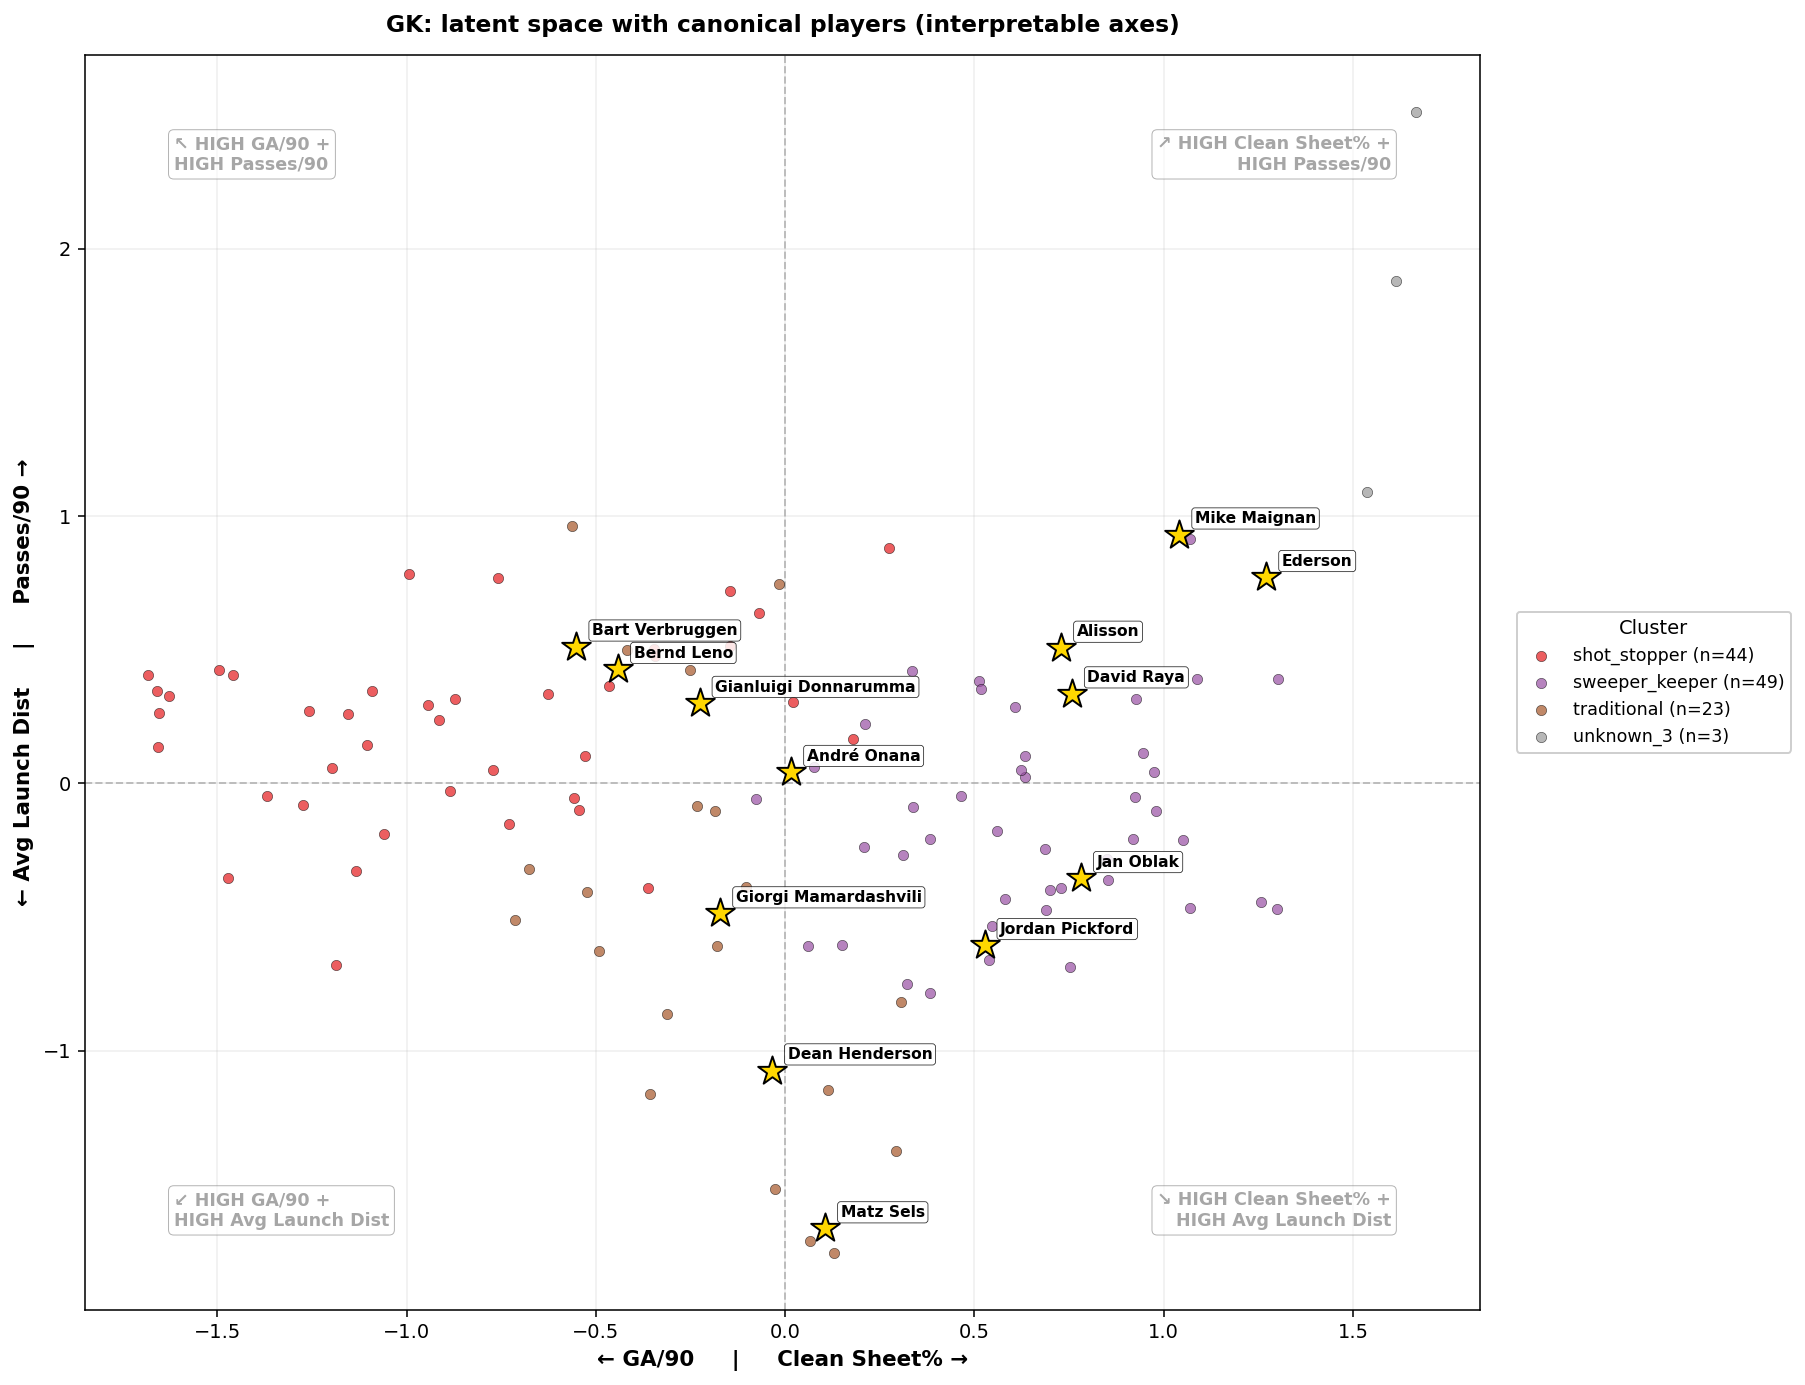

### CB — latent space with canonicals (interpretable axes)

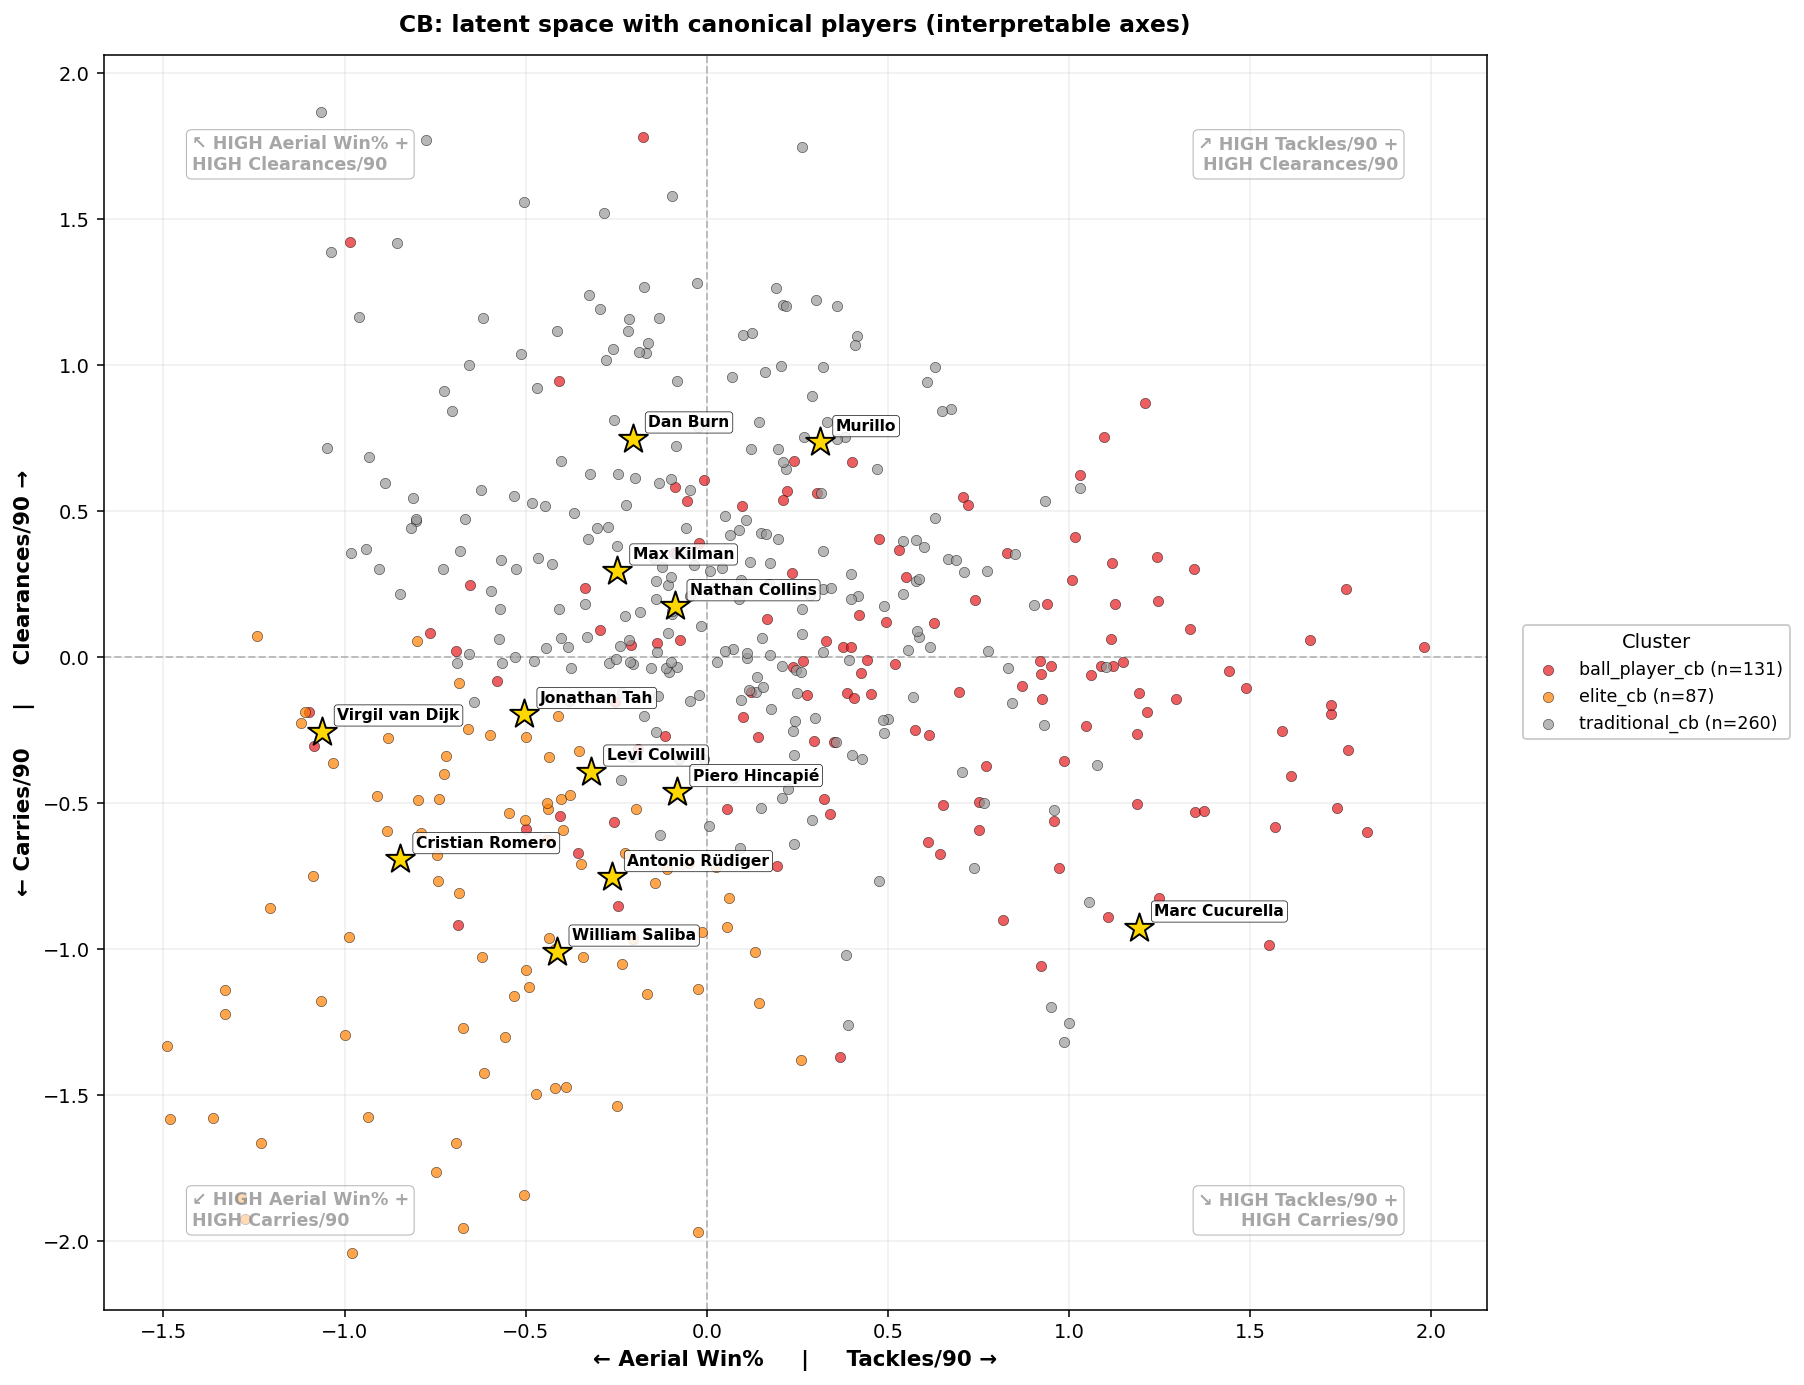

### FB — latent space with canonicals (interpretable axes)

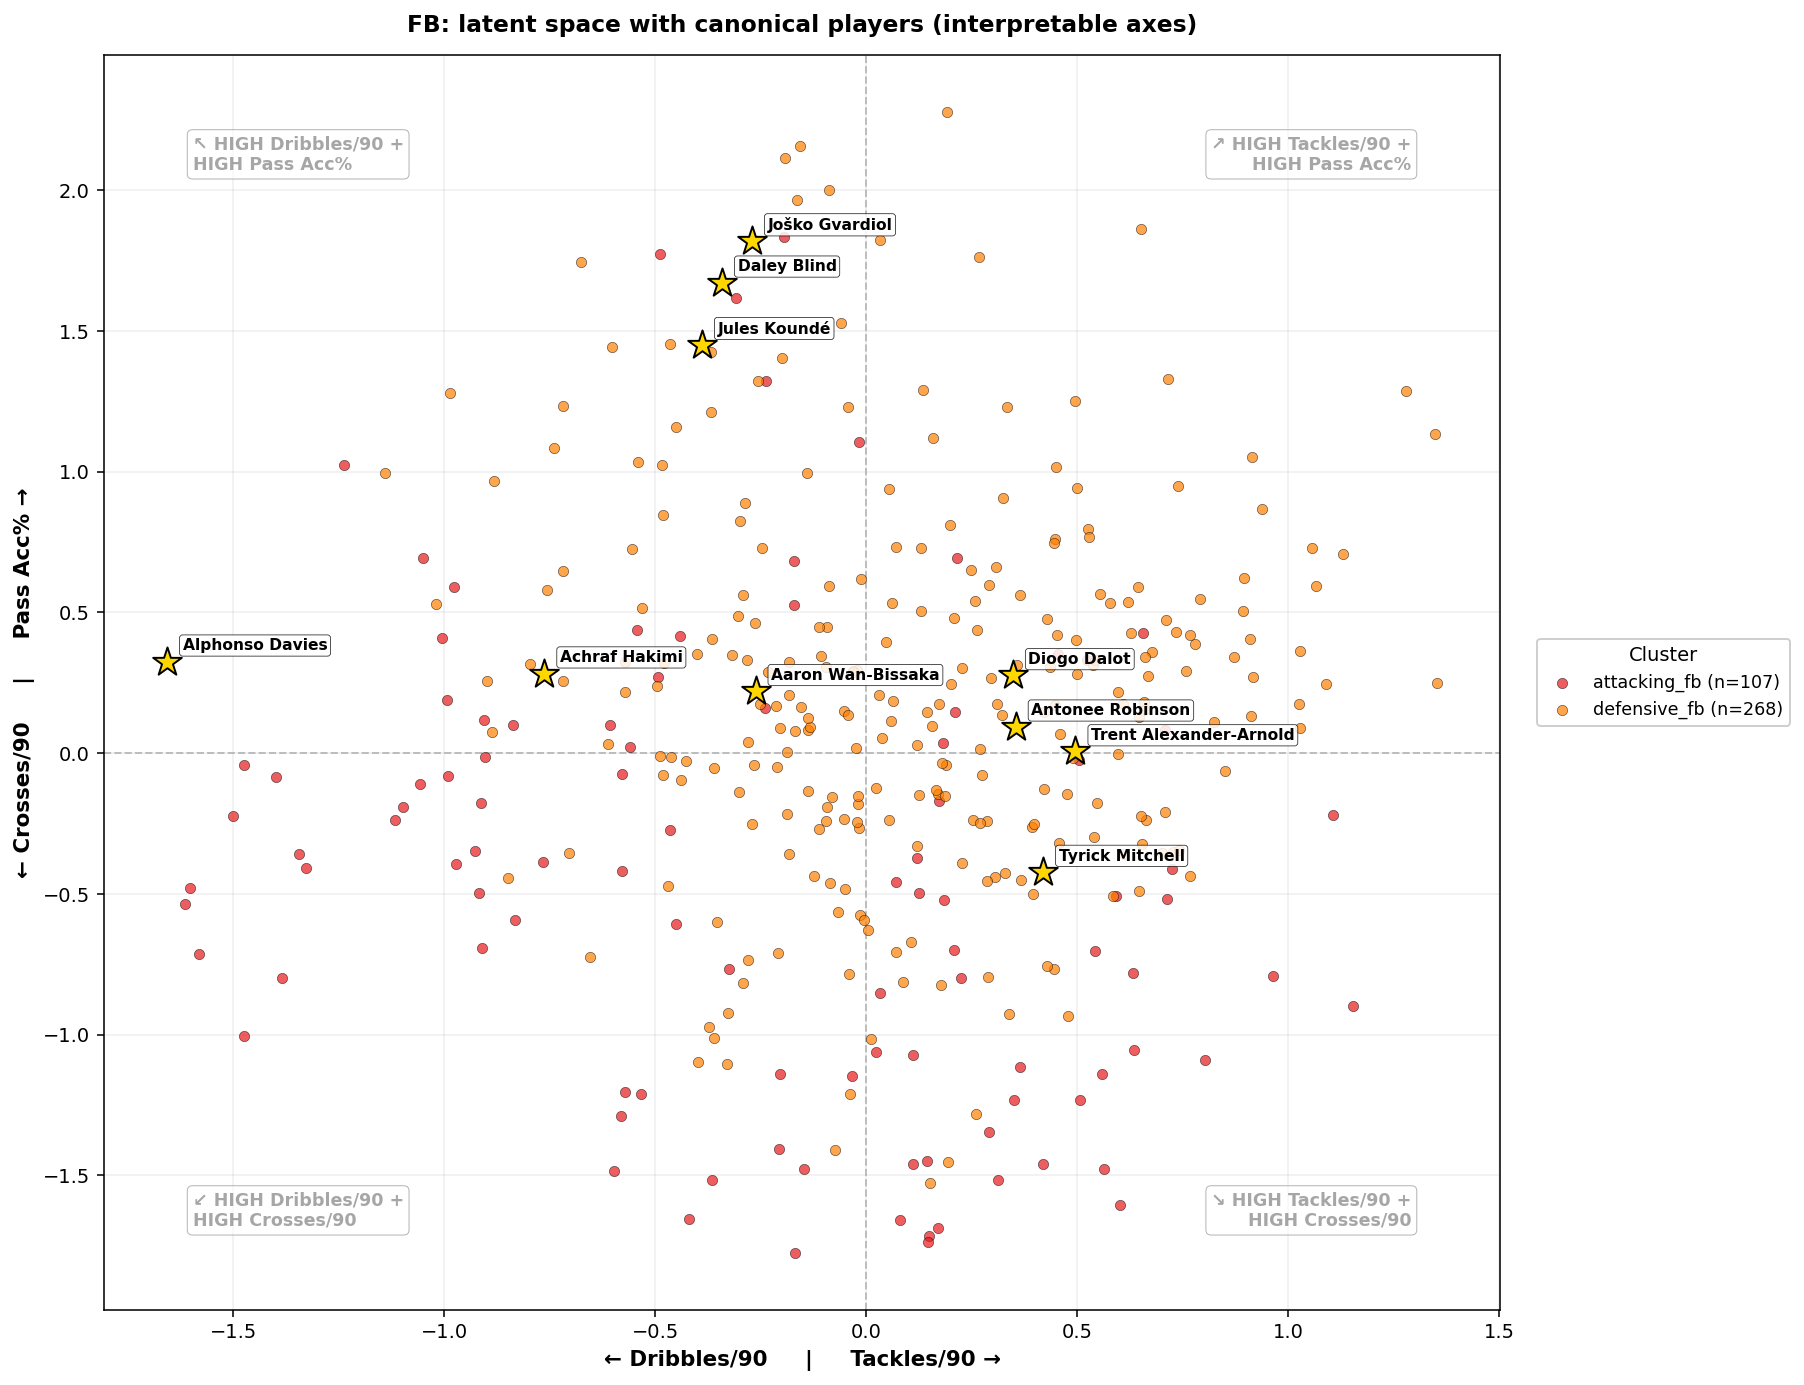

### DM — latent space with canonicals (interpretable axes)

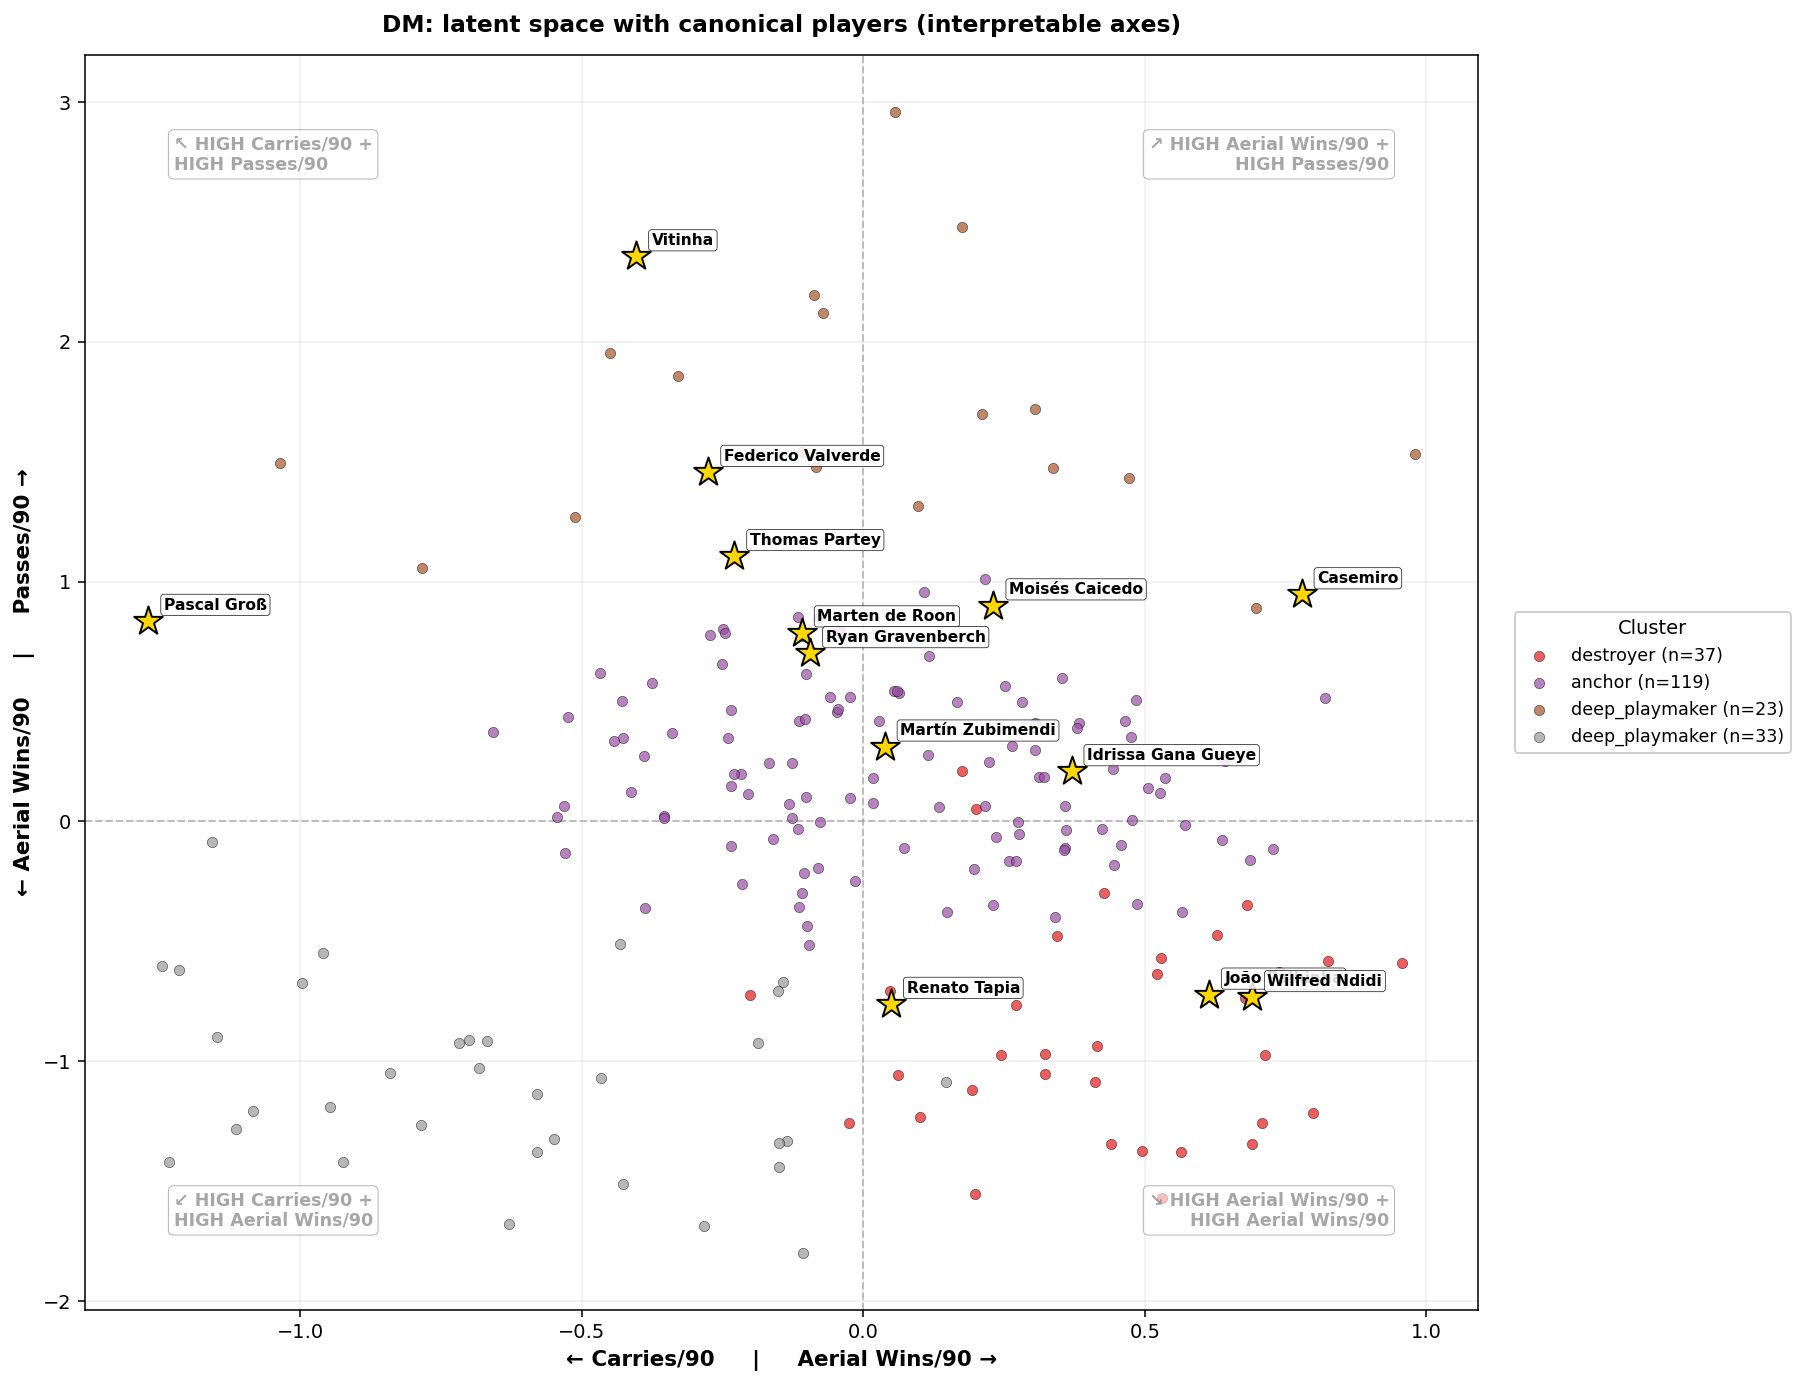

### CM — latent space with canonicals (interpretable axes)

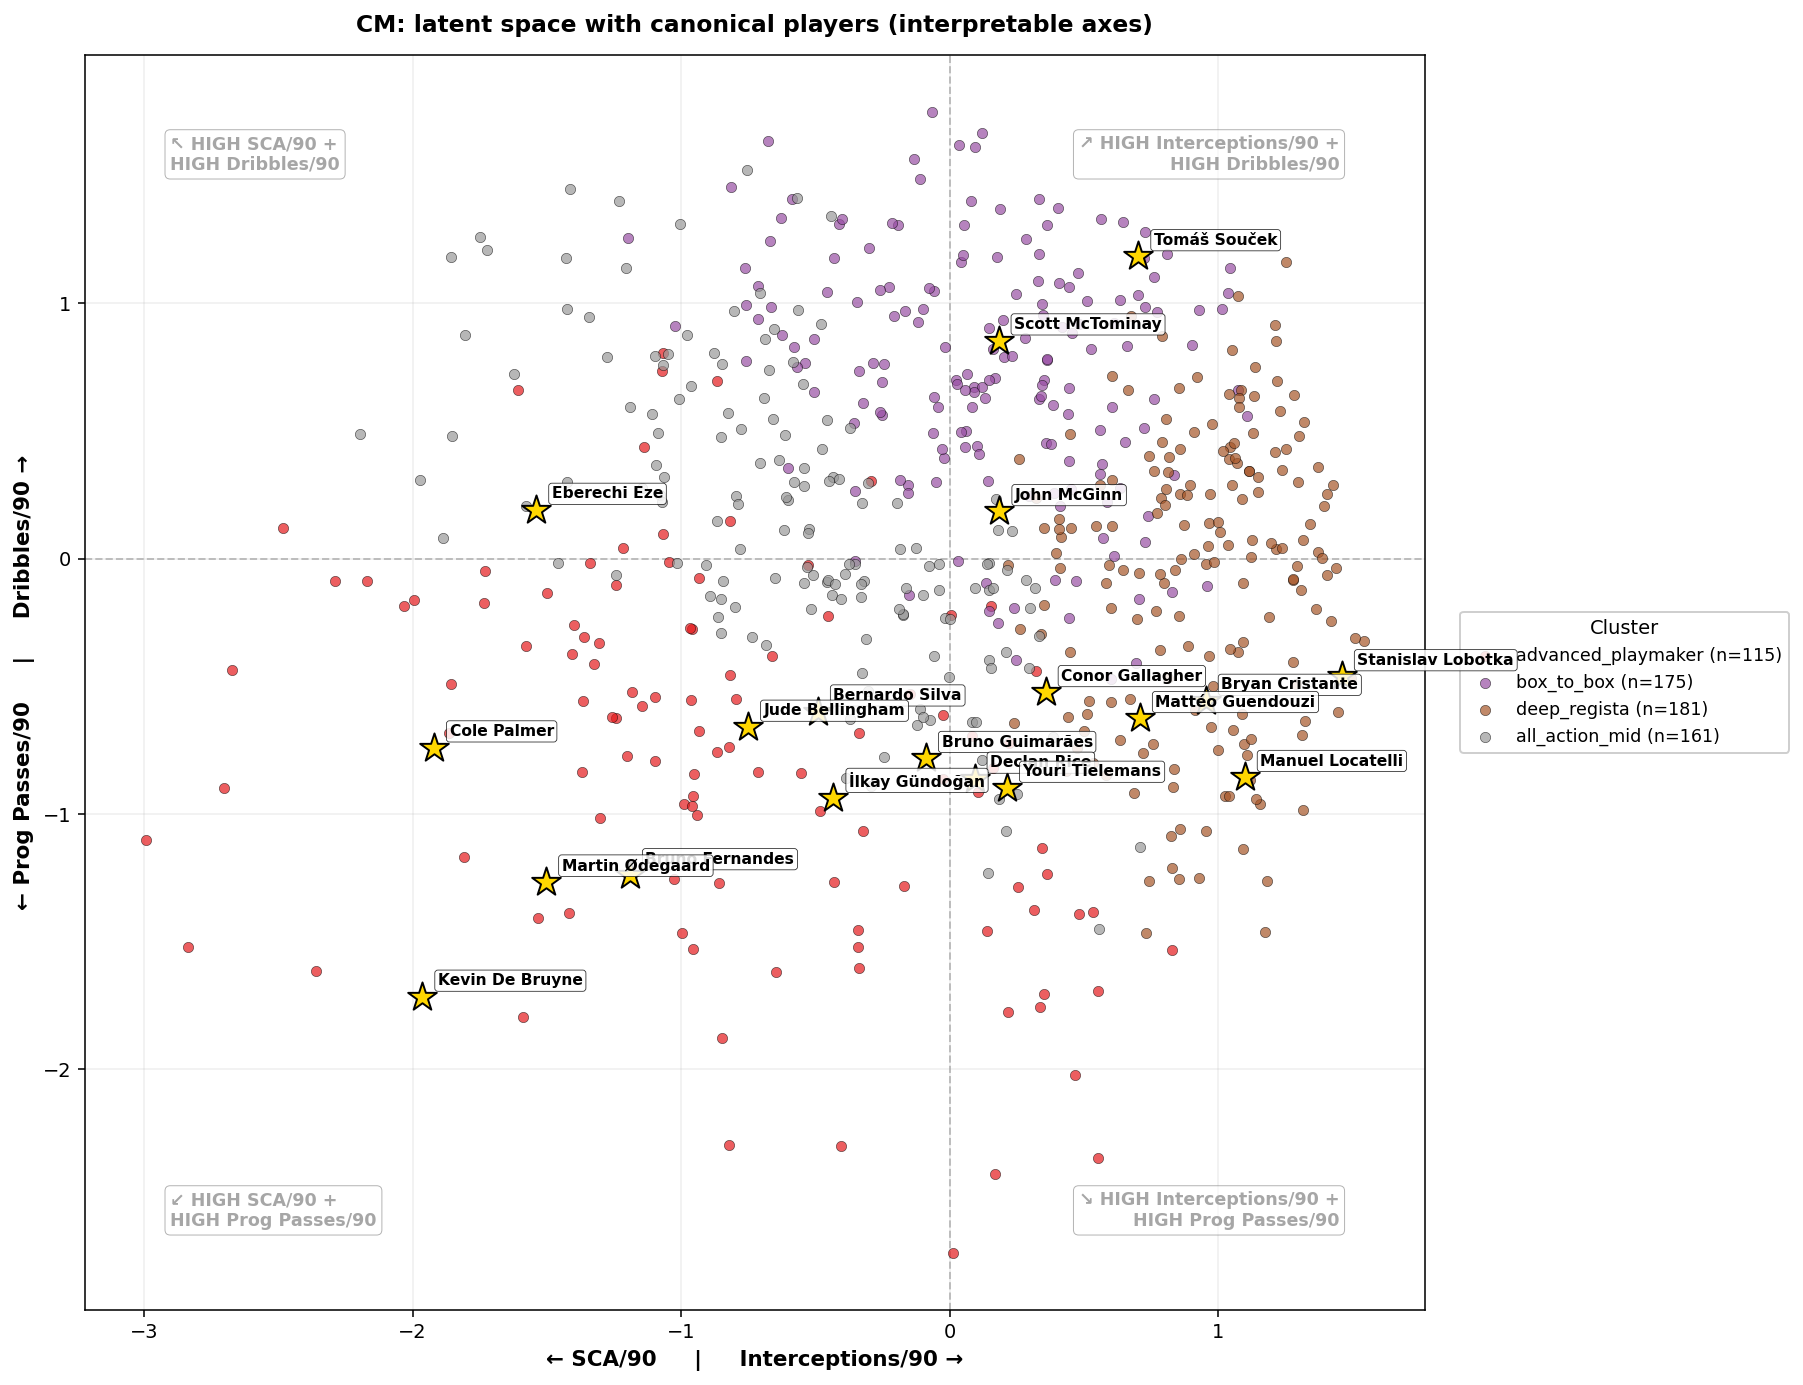

### W — latent space with canonicals (interpretable axes)

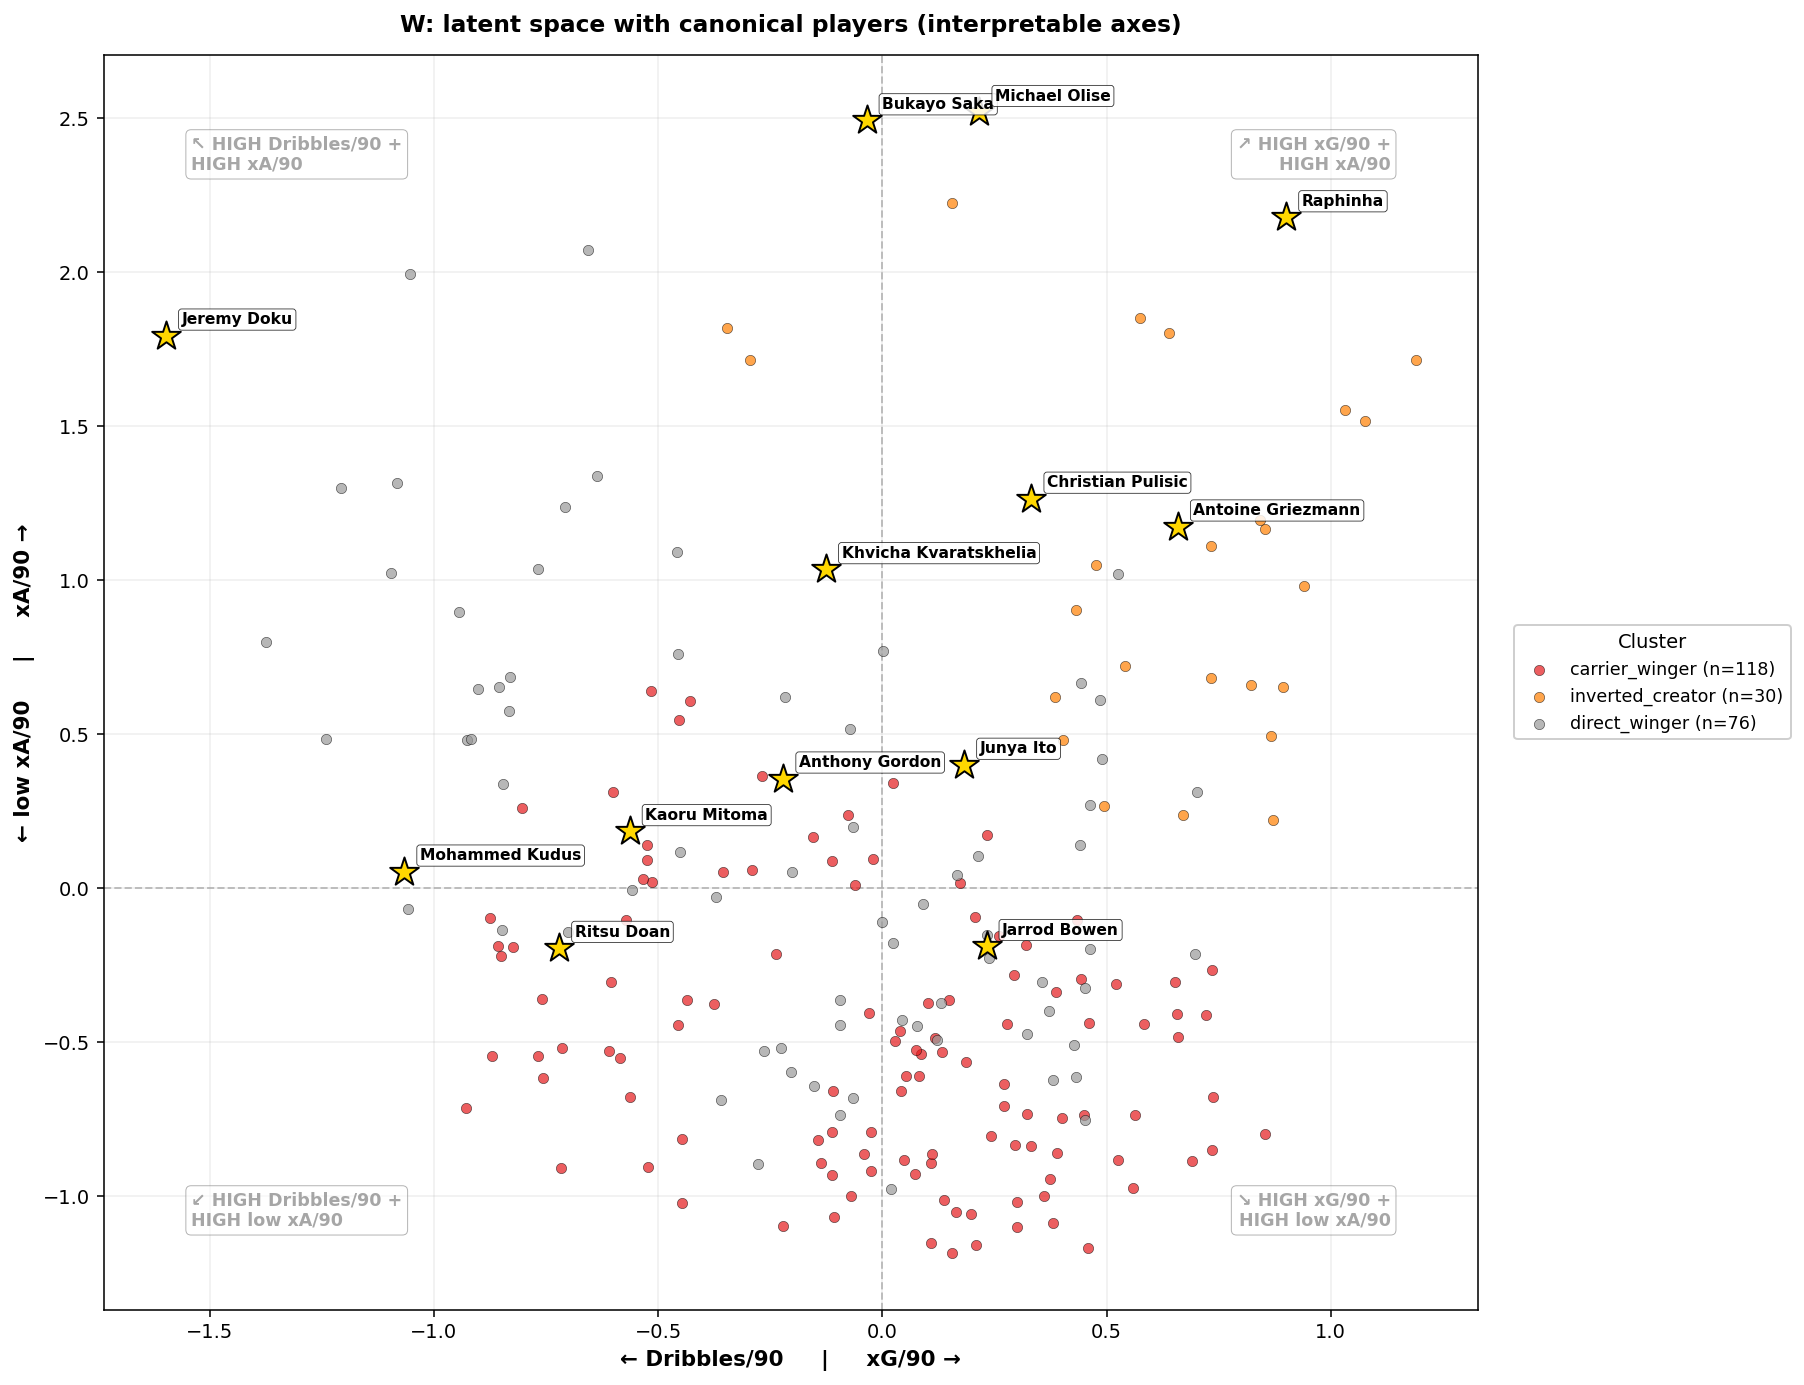

### ST — latent space with canonicals (interpretable axes)

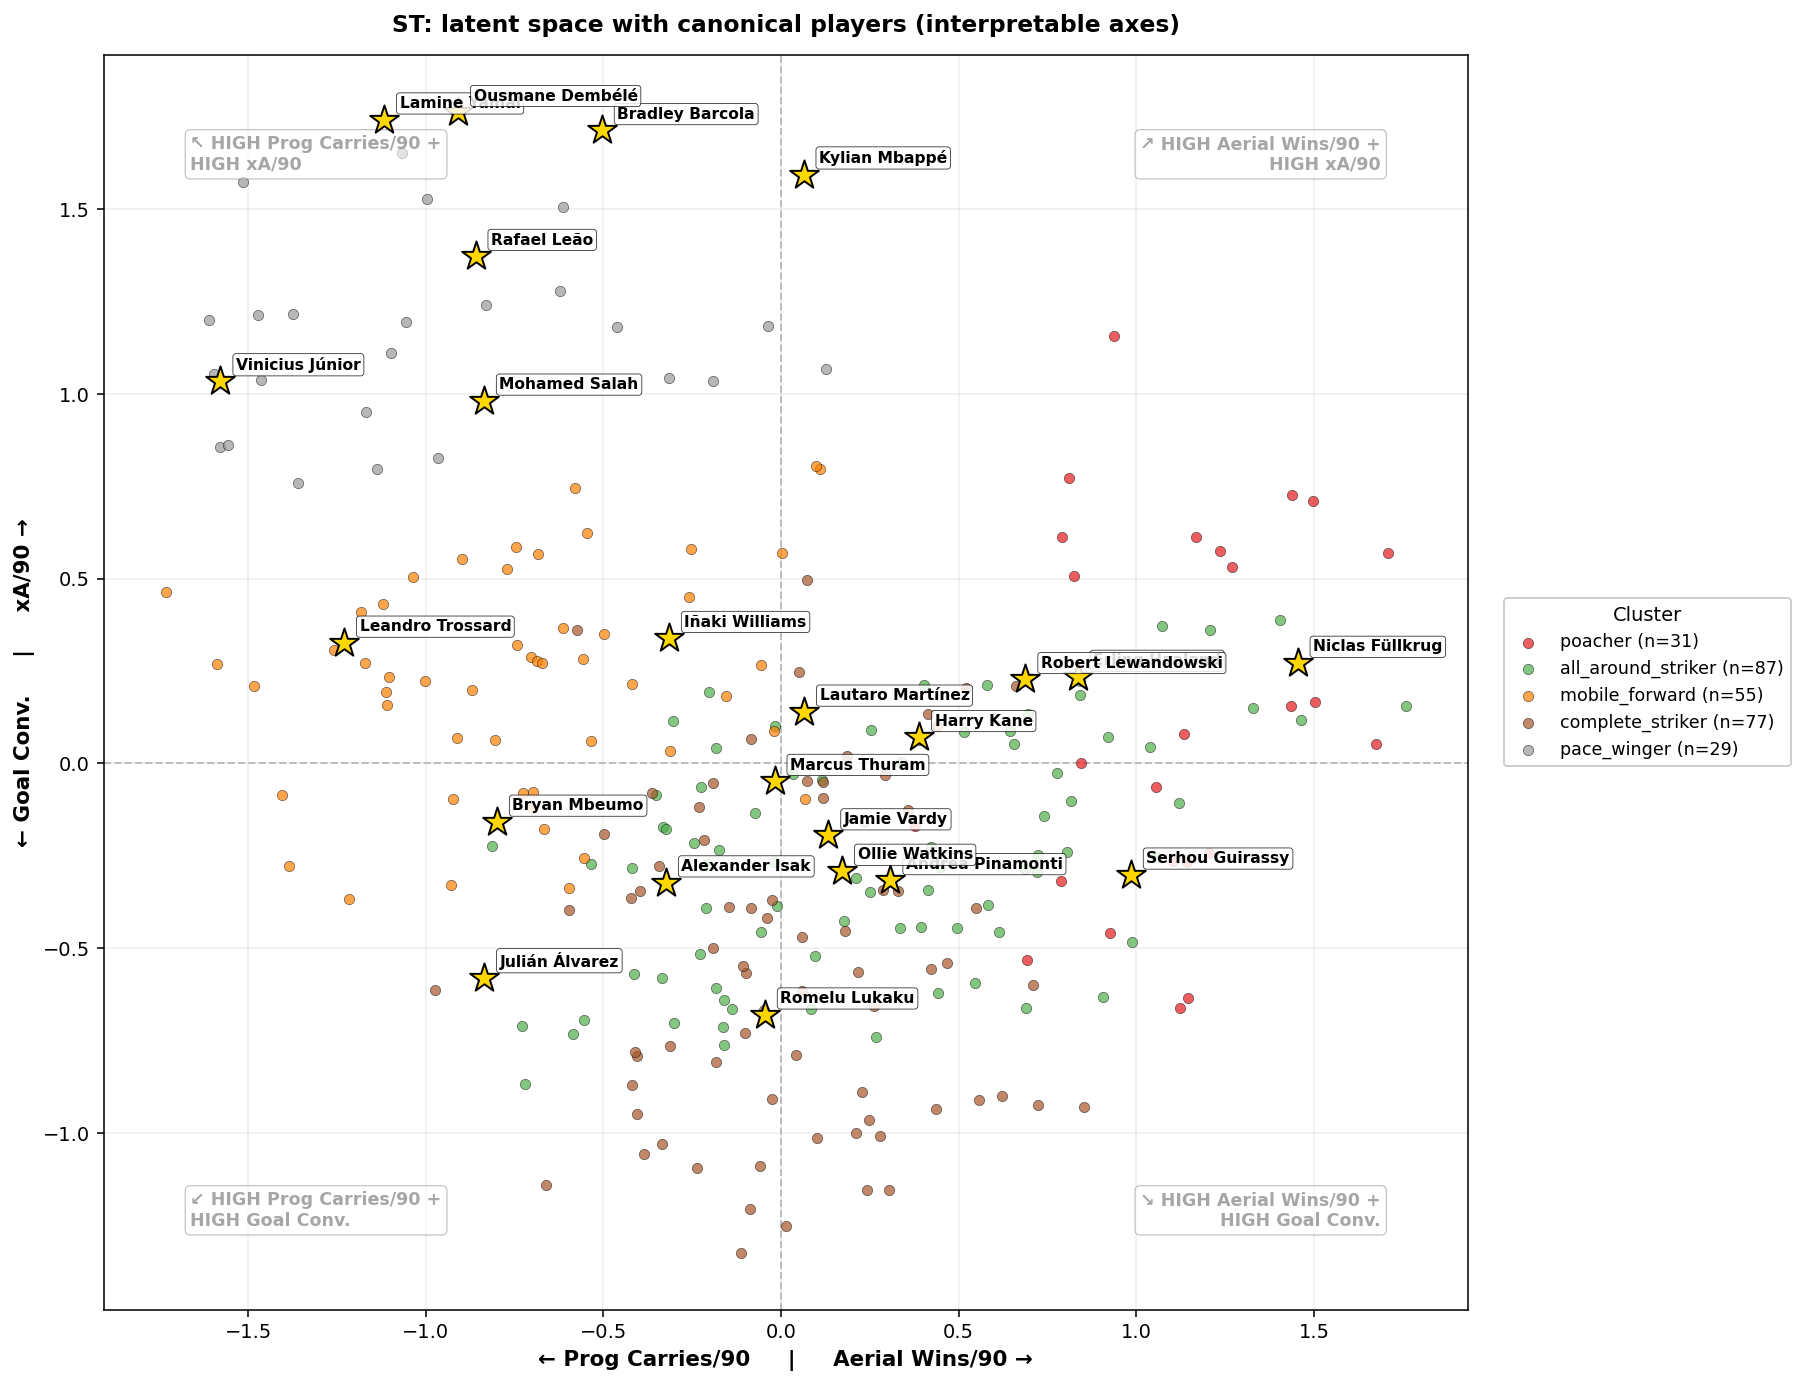

In [61]:
from IPython.display import Image, display, Markdown

for pos in ['GK', 'CB', 'FB', 'DM', 'CM', 'W', 'ST']:
    display(Markdown(f"### {pos} — latent space with canonicals (interpretable axes)"))
    display(Image(f'outputs/{pos}/04_latent_canonical_quadrants.png'))

## Anomaly Overlay on Latent Plots

### GK — anomaly score on latent axes

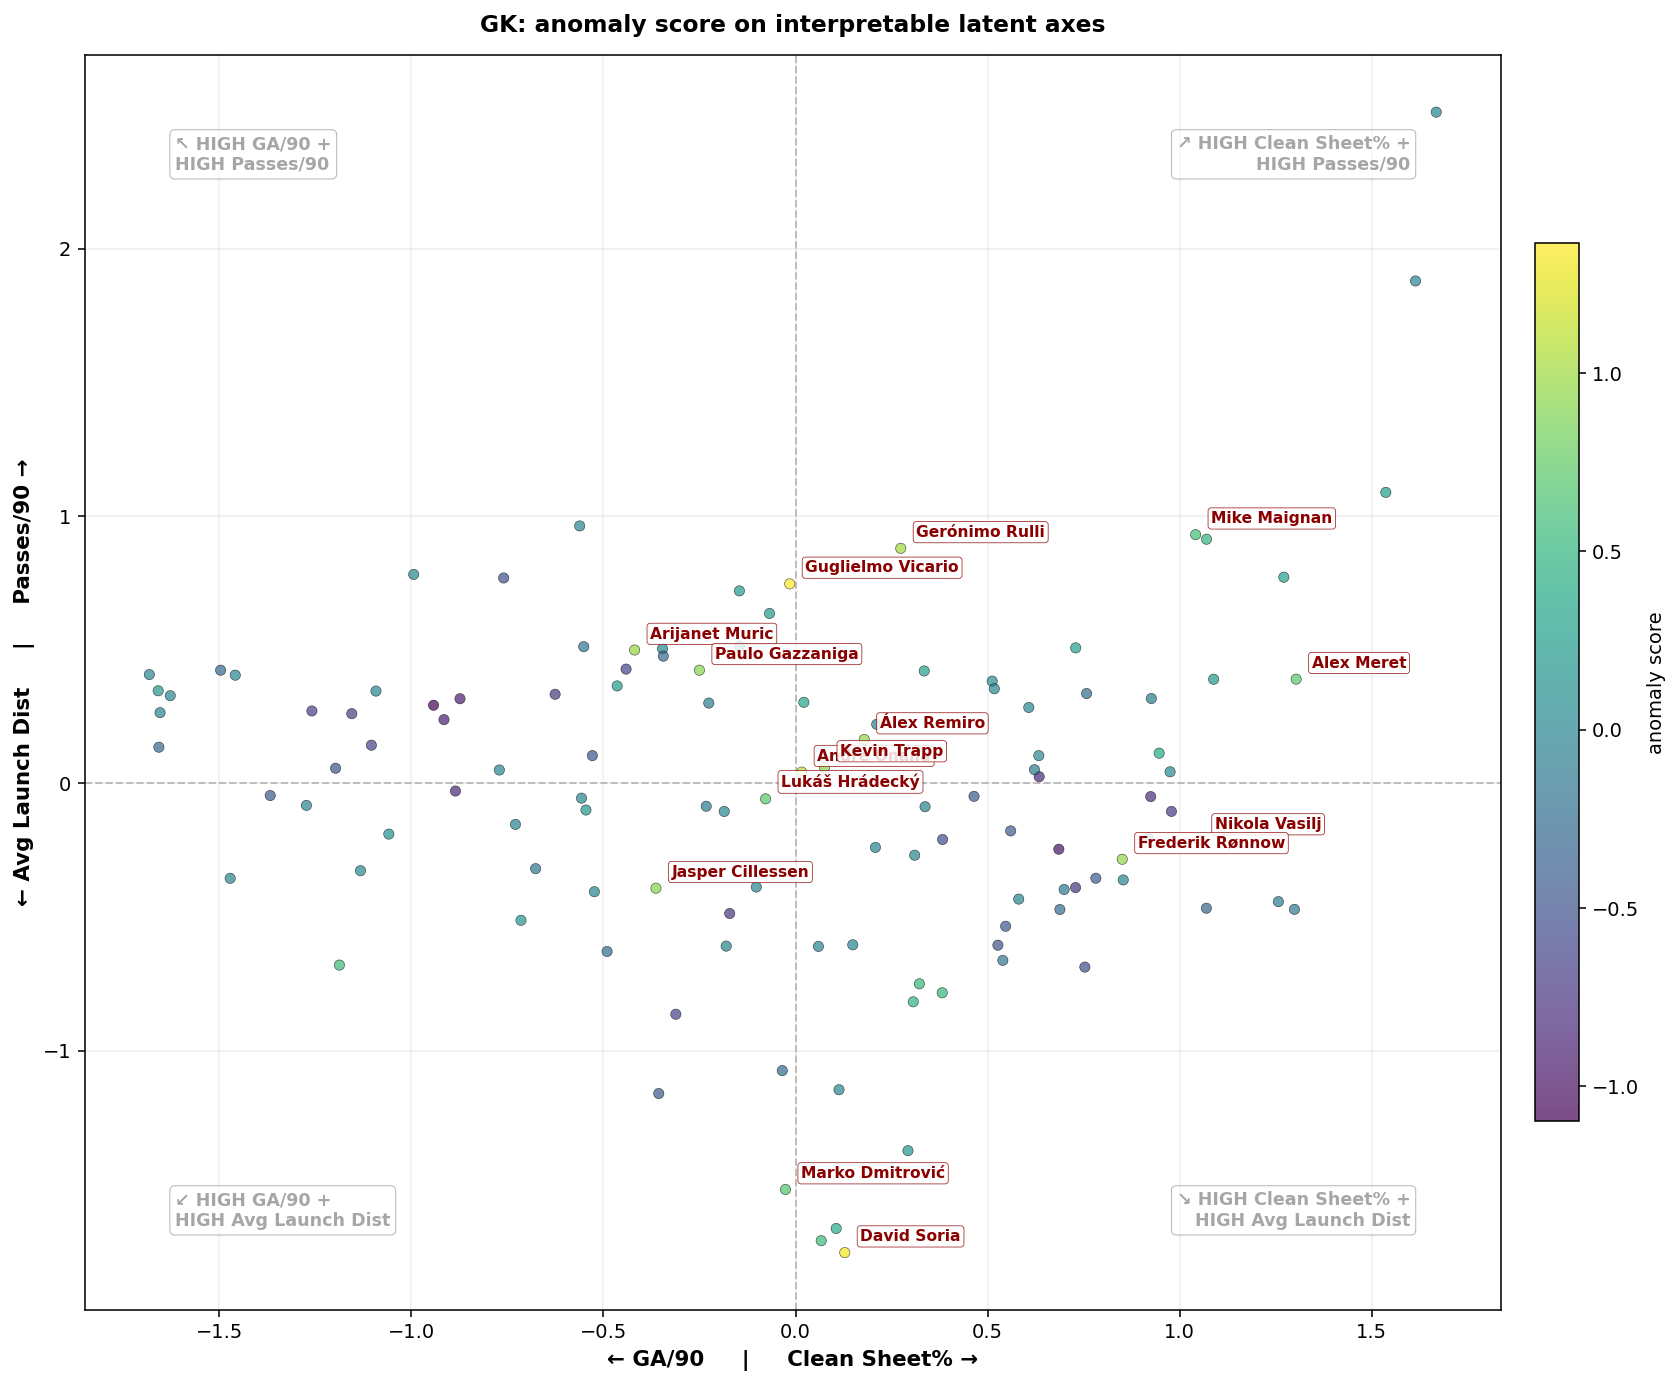

### CB — anomaly score on latent axes

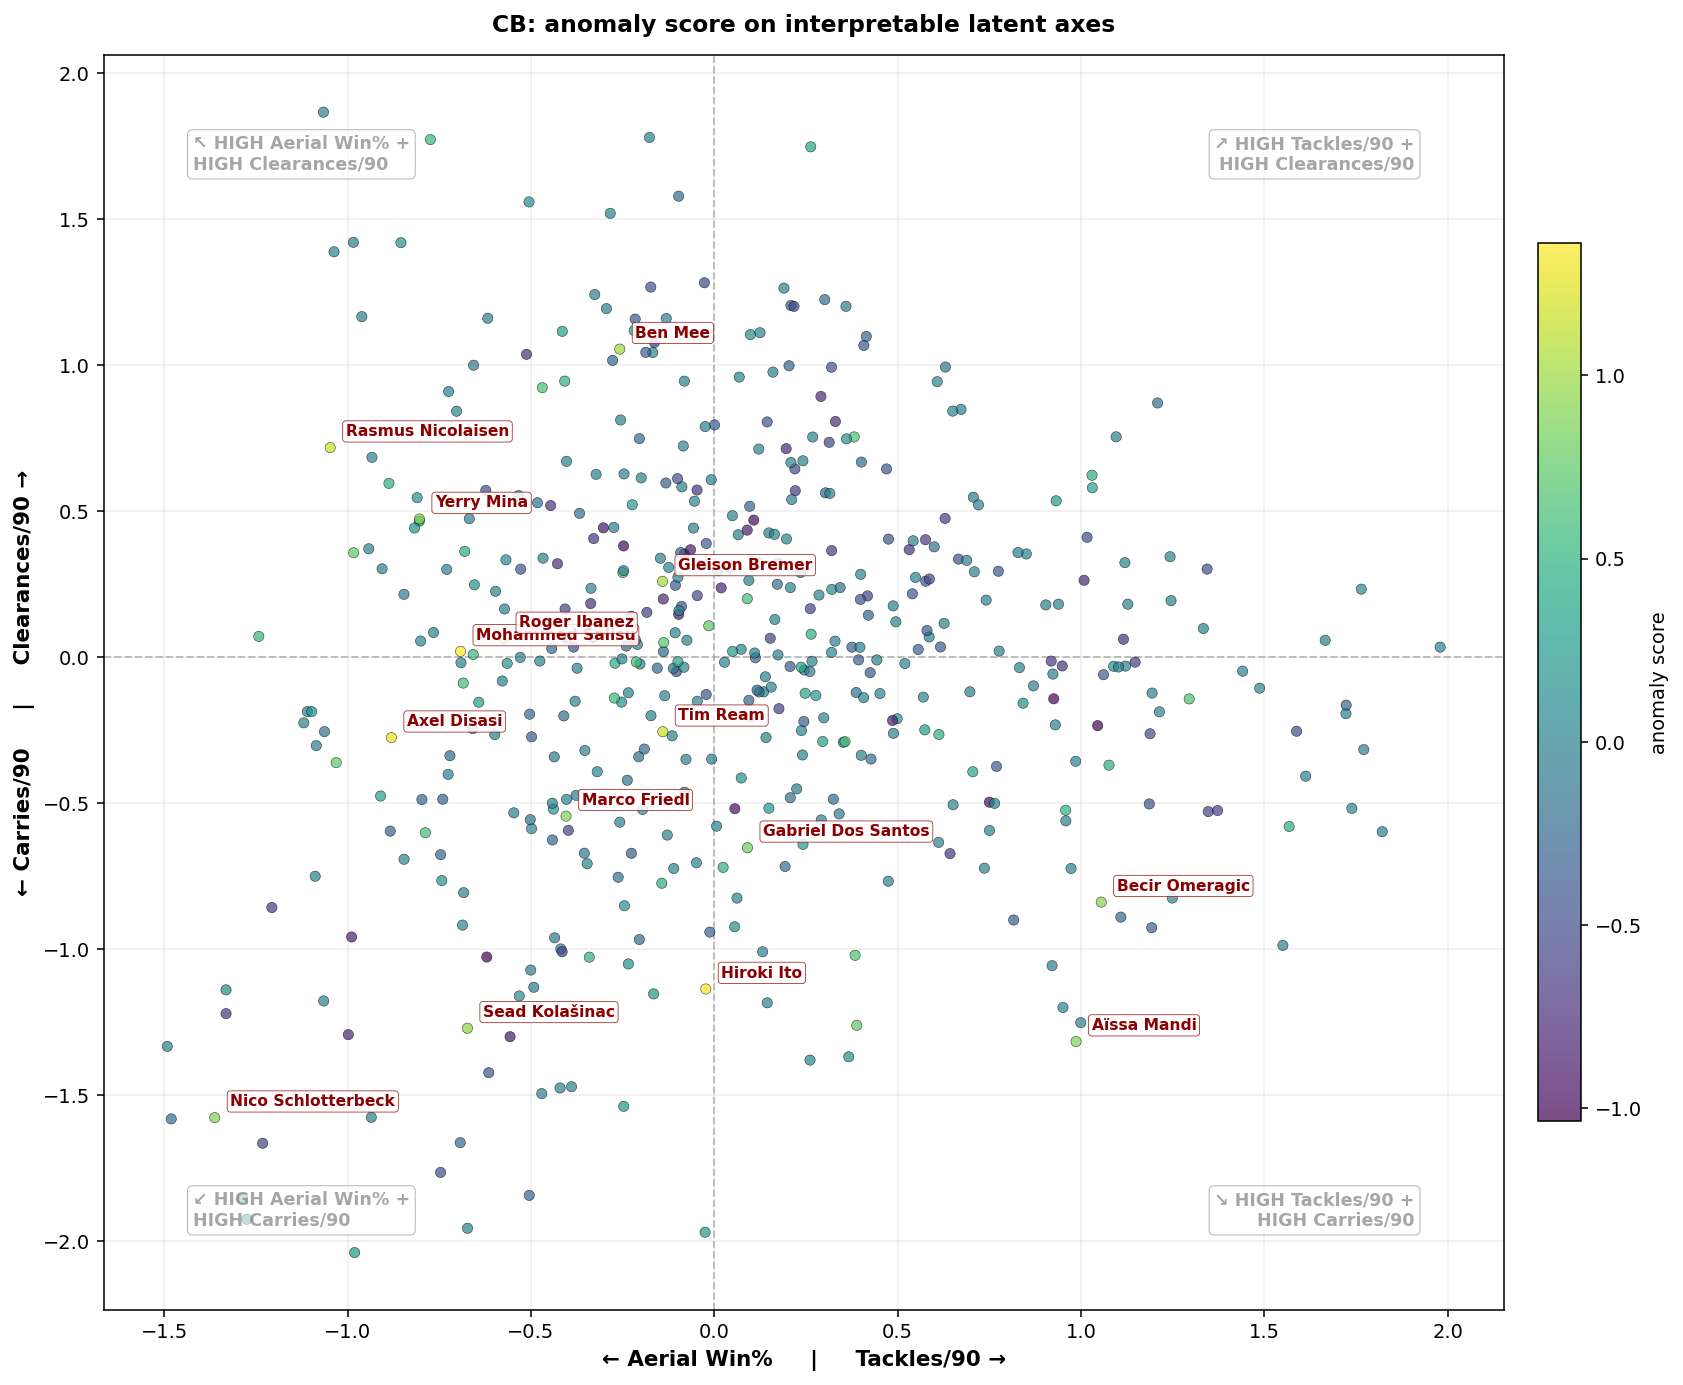

### FB — anomaly score on latent axes

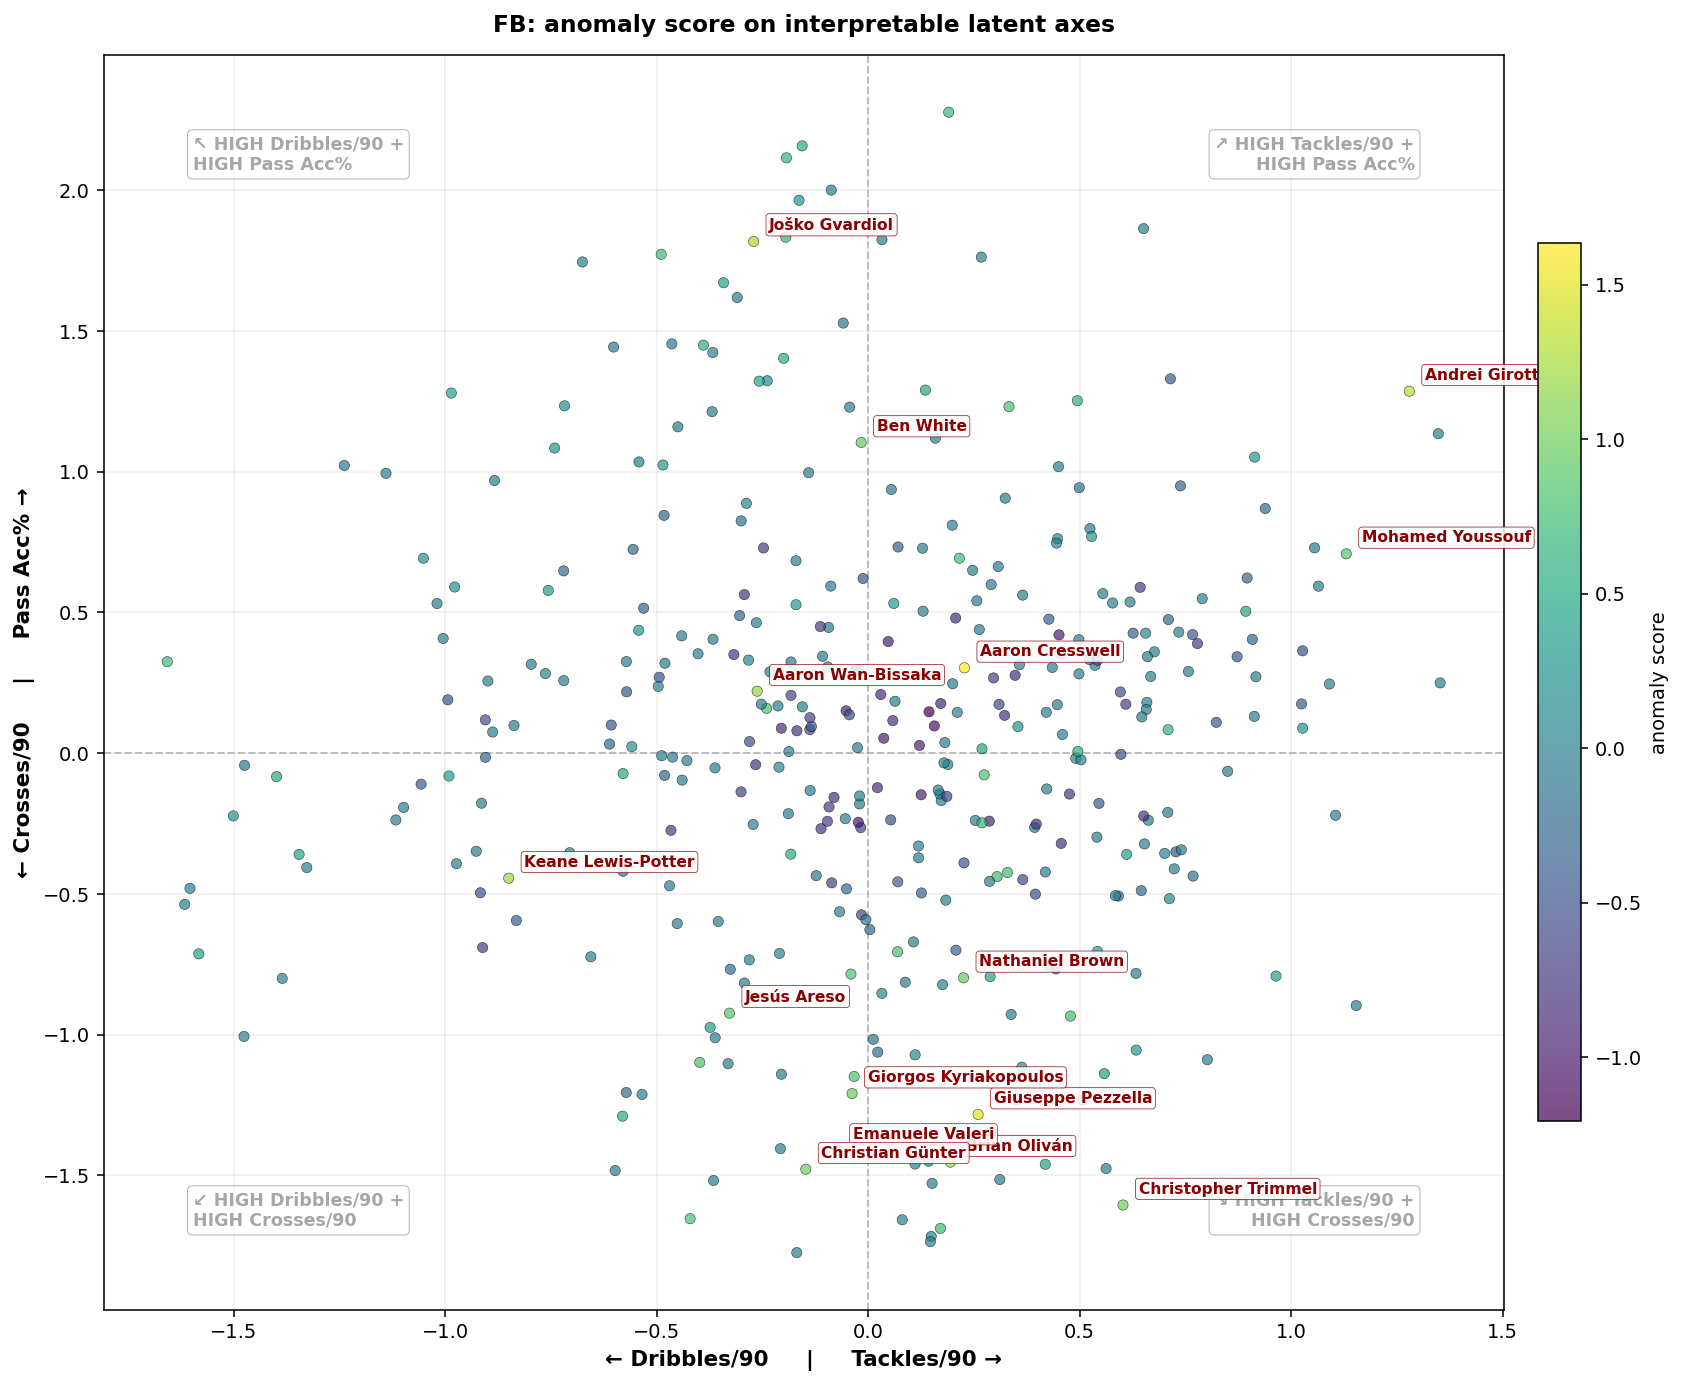

### DM — anomaly score on latent axes

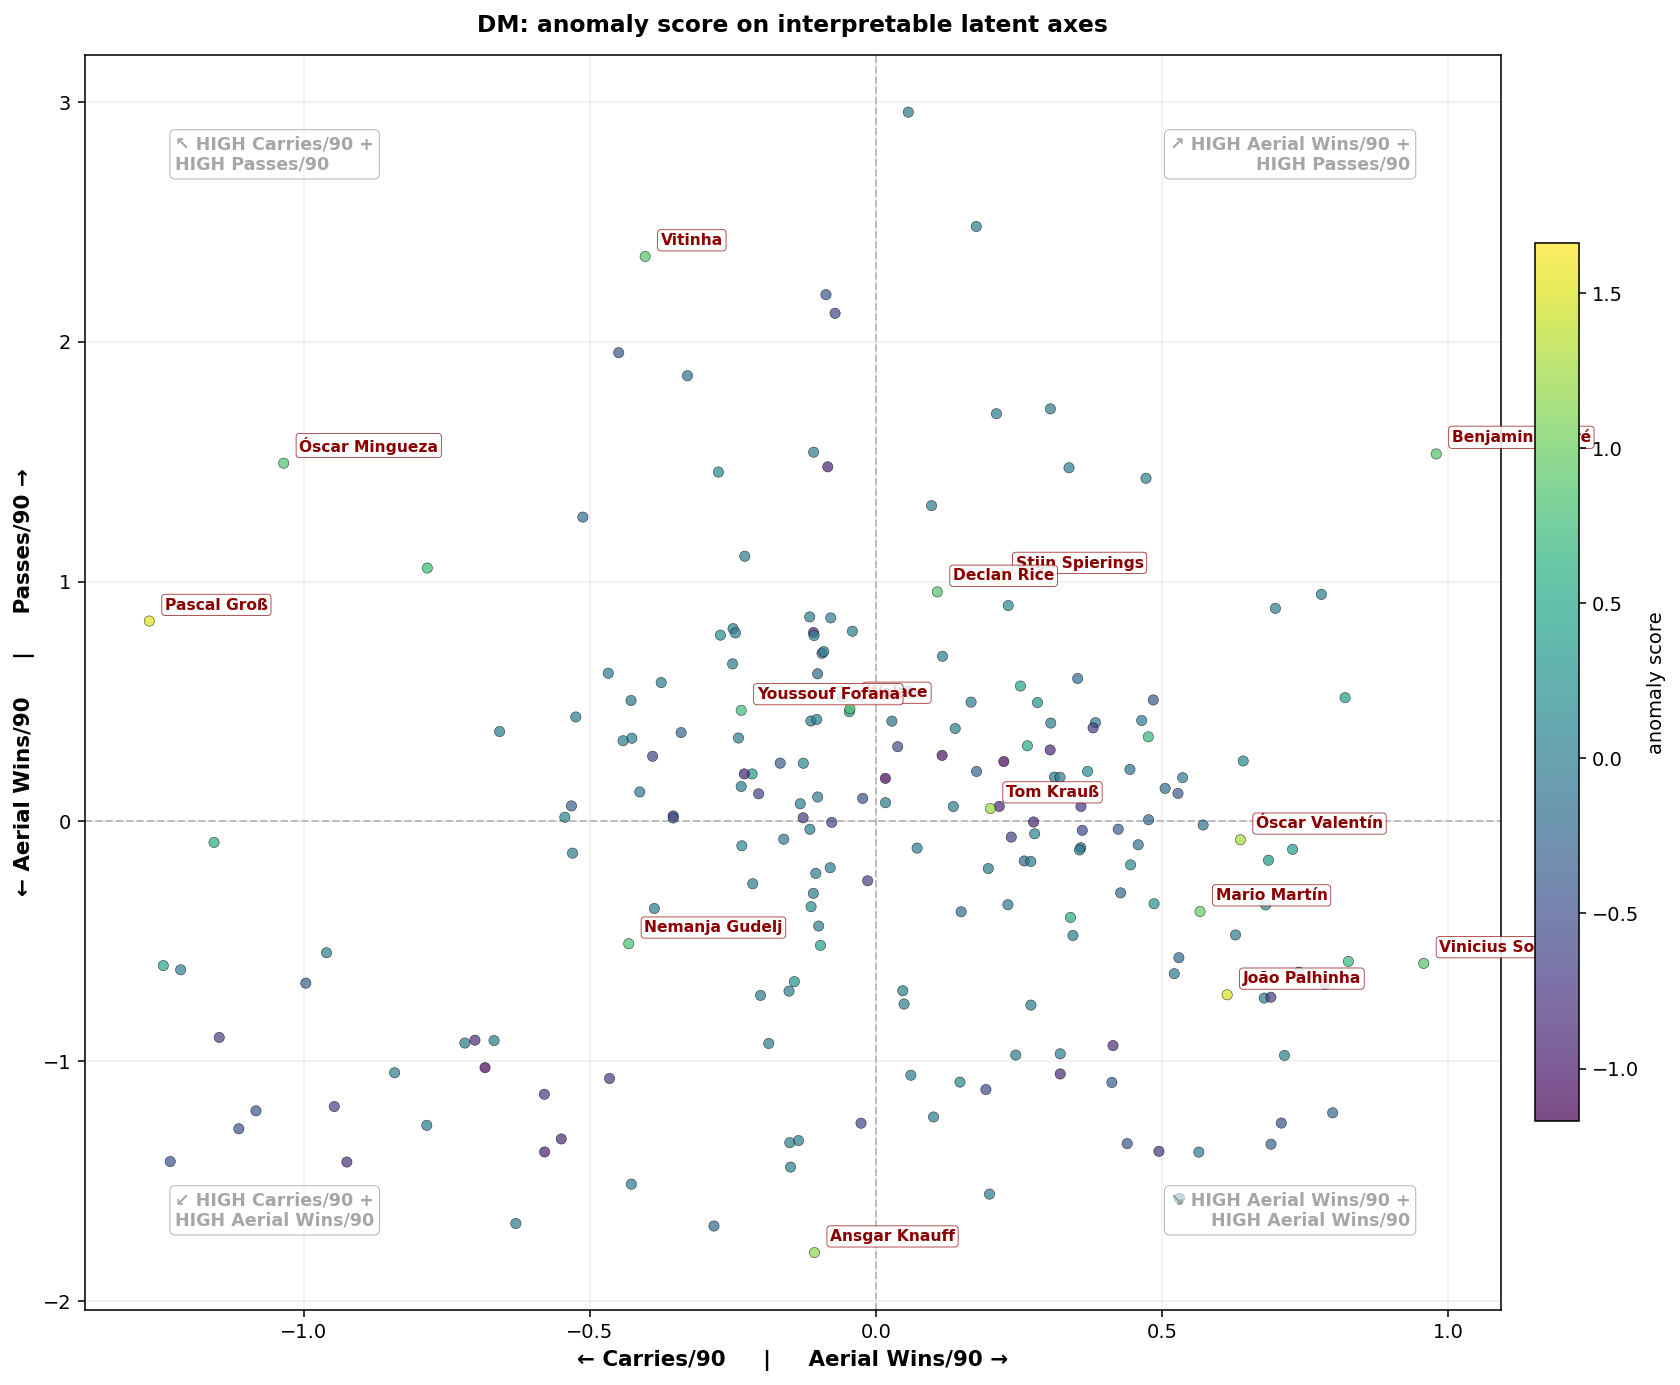

### CM — anomaly score on latent axes

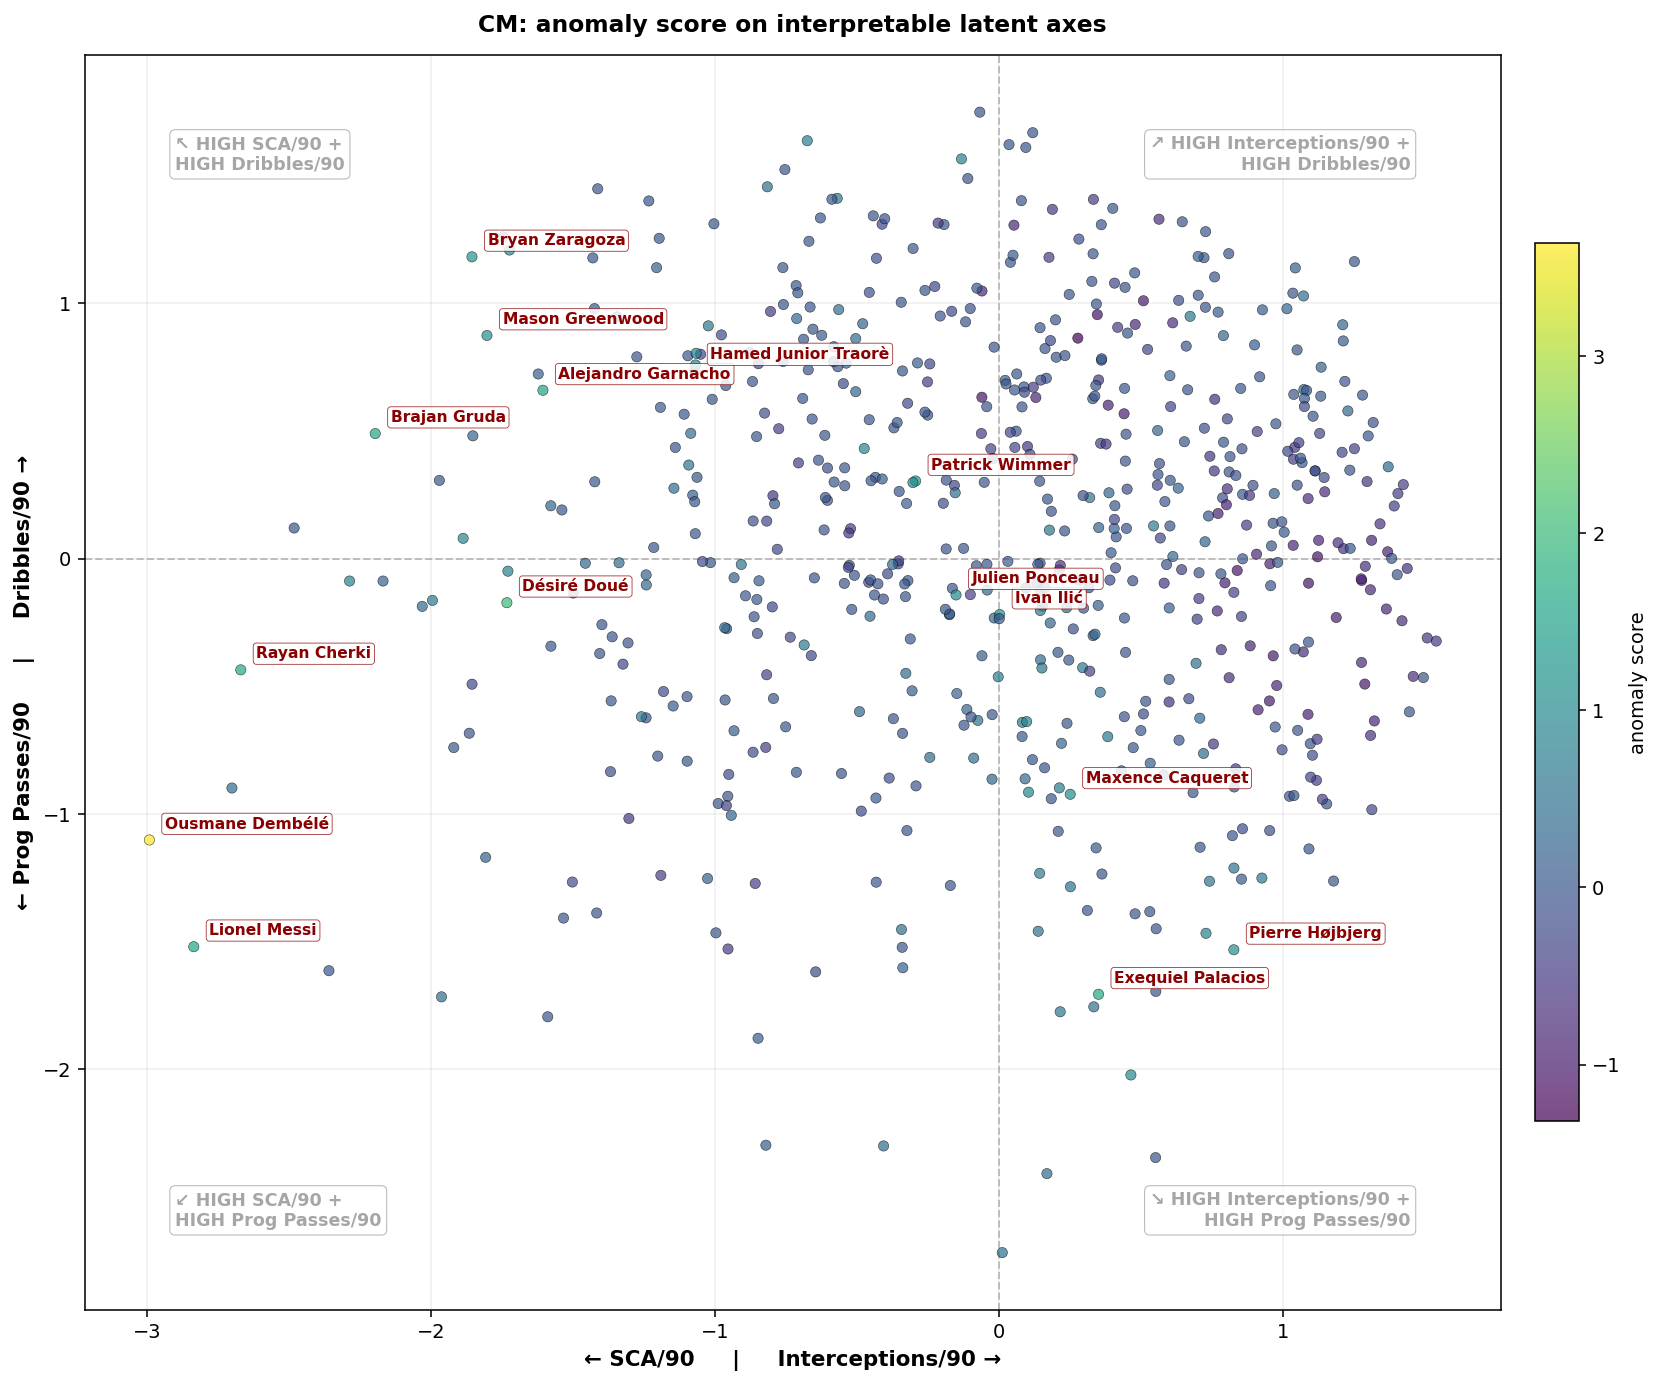

### W — anomaly score on latent axes

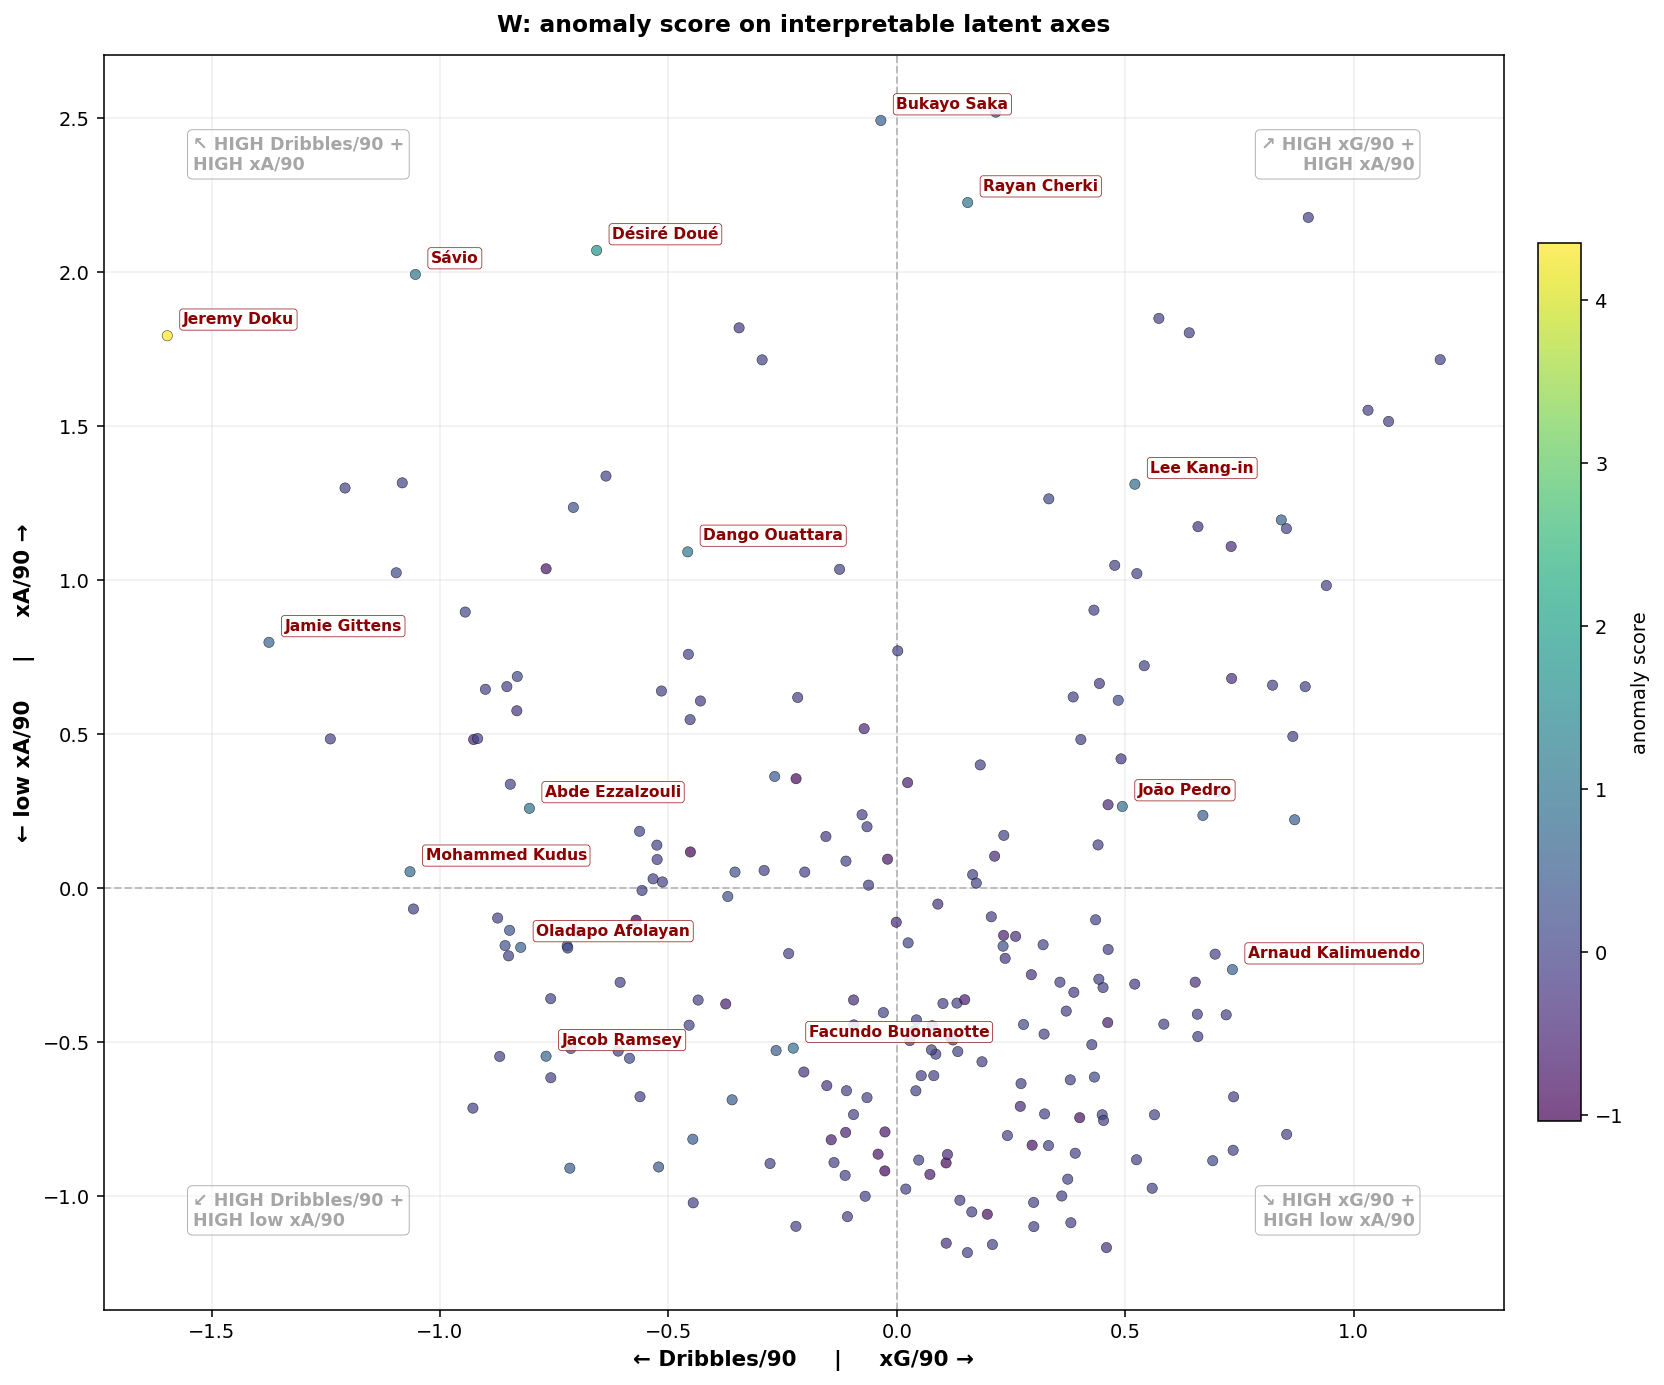

### ST — anomaly score on latent axes

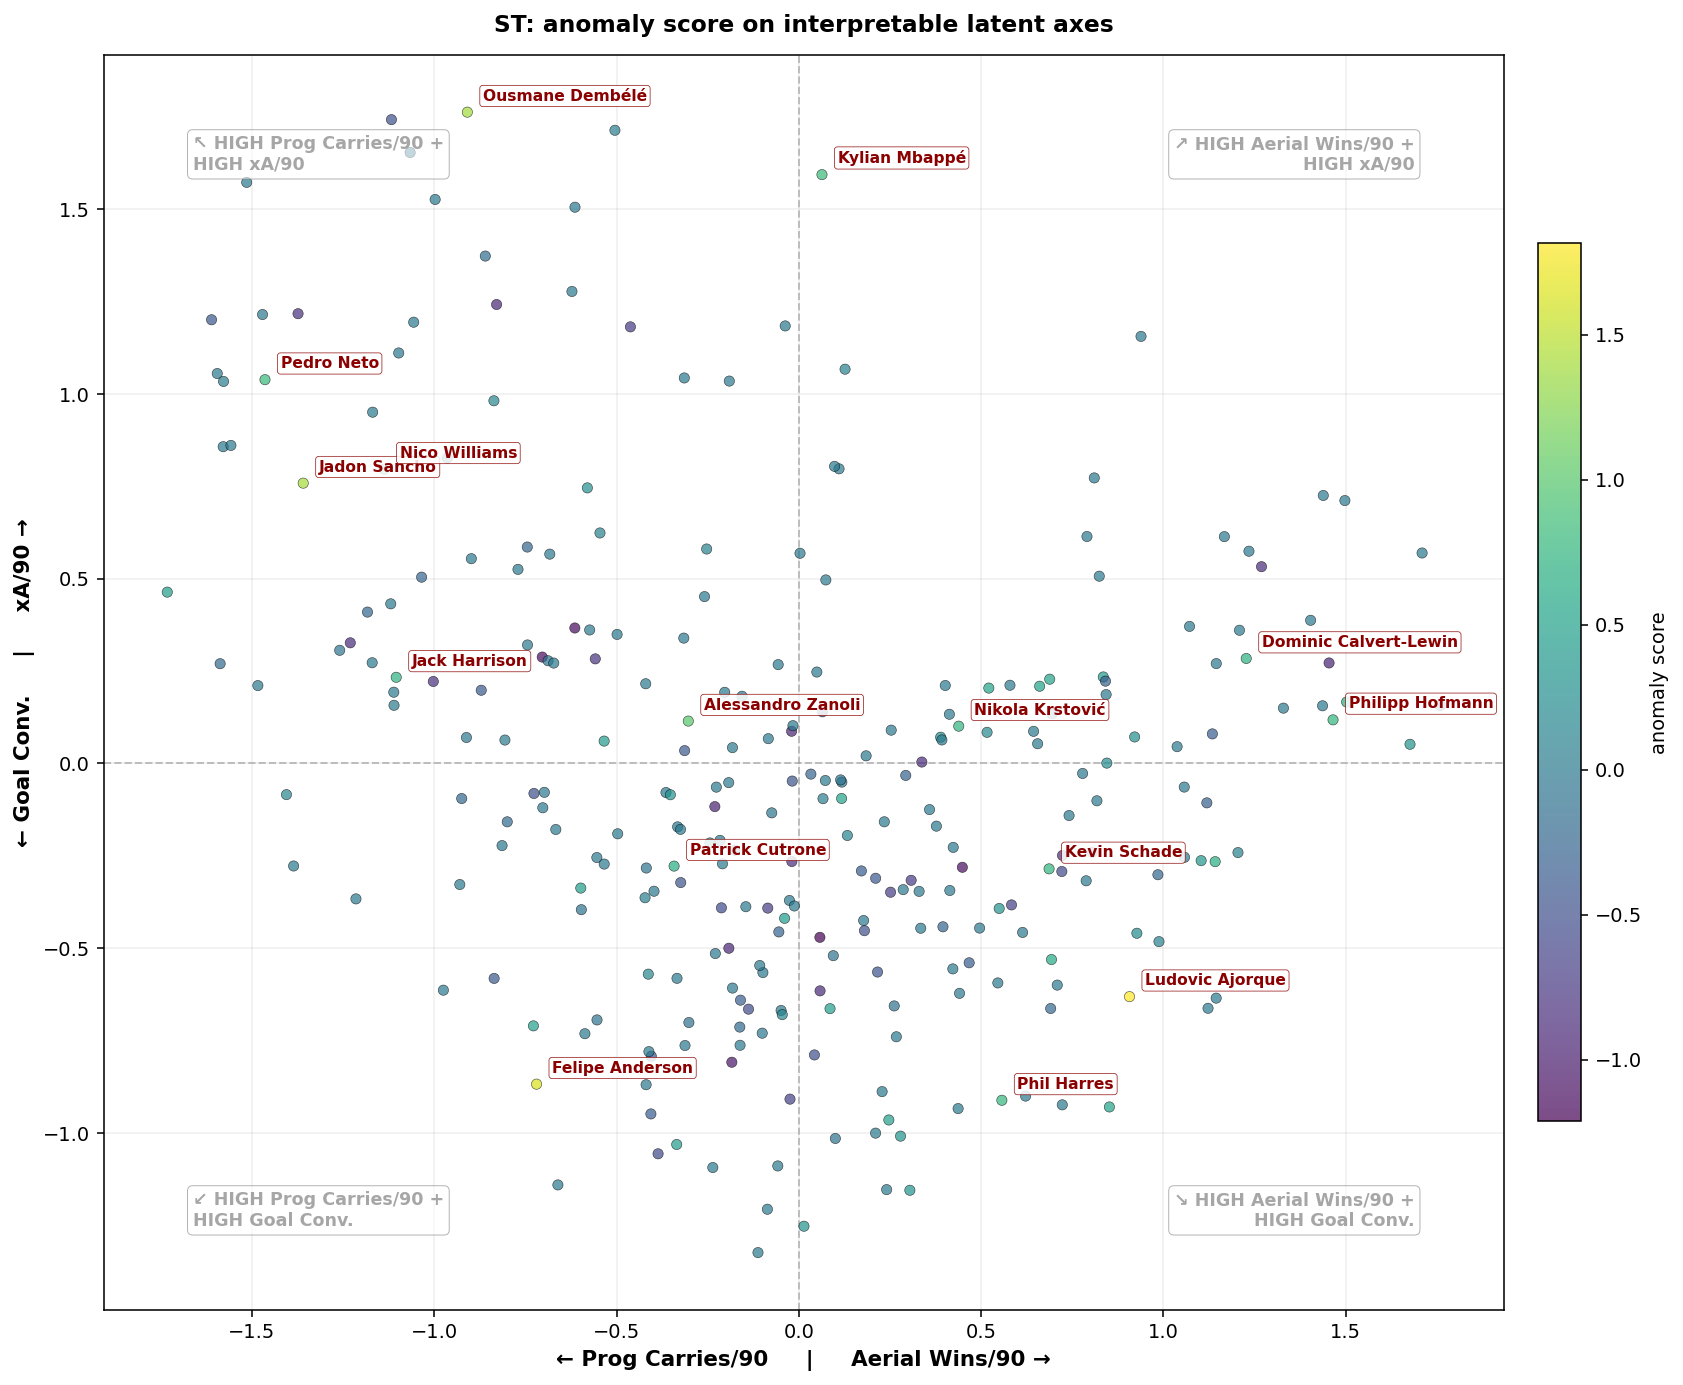

In [63]:
for pos in ['GK', 'CB', 'FB', 'DM', 'CM', 'W', 'ST']:
    display(Markdown(f"### {pos} — anomaly score on latent axes"))
    display(Image(f'outputs/anomalies/{pos}_anomaly_quadrants.png'))

## Done

See `FINAL_REPORT.pdf` for full methodology and findings.